# **Step 7 : Hyperparameter Tunning of the Models**

In [6]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K
from collections import Counter
import keras_tuner as kt
df = pd.read_csv('enhanced_dataset.csv')
df.tail()

,date,year,month,day,dayofweek,is_weekend,dayofyear,month_sin,month_cos,dayofyear_sin,...,relative_humidity_2m_max__lag_7,relative_humidity_2m_max__rolling_mean_7d,relative_humidity_2m_max__rolling_std_7d,relative_humidity_2m_max__7day_trend,cloud_rain_interaction,temp_humidity_interaction,precip_cloud_interaction,cloud_volatility_7d,rain_volatility_7d,temp_seasonal_anomaly
9247,2025-04-26,2025,4,26,5,True,116,0.866025,-0.5,0.911169,...,81.0,85.142857,5.843189,9.0,0.0,330.0,0.0,23.027933,15.102065,-2.538462
9248,2025-04-27,2025,4,27,6,True,117,0.866025,-0.5,0.903946,...,91.0,85.714286,6.651172,4.0,330.0,285.6,300.0,23.483530,15.023077,-3.503846
9249,2025-04-28,2025,4,28,0,False,118,0.866025,-0.5,0.896456,...,91.0,85.571429,6.528327,-1.0,288.0,270.6,480.0,23.107410,1.521747,-3.942308
9250,2025-04-29,2025,4,29,1,False,119,0.866025,-0.5,0.888701,...,80.0,87.571429,6.679749,14.0,460.0,329.0,1200.0,22.867111,1.978576,-4.903846
9251,2025-04-30,2025,4,30,2,False,120,0.866025,-0.5,0.880683,...,84.0,89.428571,7.299706,13.0,0.0,524.4,0.0,23.229702,2.003212,-1.792308


**1- Hyperparameter tunning of the temp_max LSTM Model (option 15)**

**a.Create the Model Class**

In [20]:
import optuna
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import matplotlib.pyplot as plt


class OptimizedTemperatureMaxLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        self.best_params = None
        self.study = None
        
        # Temperature target columns
        self.target_cols = [
            'temperature_2m_max (°C)'
        ]
        
    def preprocess_data(self):
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'temperature_2m_min (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model_with_params(self, trial, input_shape, output_shape):
        
        # Hyperparameters to optimize
        lstm1_units = trial.suggest_int('lstm1_units', 32, 256, step=32)
        lstm2_units = trial.suggest_int('lstm2_units', 16, 128, step=16)
        lstm3_units = trial.suggest_int('lstm3_units', 8, 64, step=8)
        
        dense1_units = trial.suggest_int('dense1_units', 32, 128, step=16)
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=8)
        
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
        recurrent_dropout = trial.suggest_float('recurrent_dropout', 0.1, 0.4, step=0.1)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_norm = trial.suggest_categorical('batch_norm', [True, False])
        
        model = Sequential()
        
        # First LSTM layer
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Second LSTM layer
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Third LSTM layer
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        # Dense layers
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        
        # Reshape to (forecast_horizon, num_target_variables)
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def objective(self, trial):
        
        try:
            # Create sequences
            X, y = self.create_sequences()
            
            if len(X) == 0:
                return float('inf')
            
            # Train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, shuffle=True
            )
            
            # Build model with trial parameters
            input_shape = (self.sequence_length, X.shape[2])
            output_shape = (self.forecast_horizon, len(self.available_targets))
            
            model = self.build_model_with_params(trial, input_shape, output_shape)
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            
            # Callbacks
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
            ]
            
            # Train model
            history = model.fit(
                X_train, y_train,
                epochs=50,  # Reduced for faster optimization
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=0
            )
            
            # Get best validation loss
            best_val_loss = min(history.history['val_loss'])
            
            # Clean up to free memory
            del model
            tf.keras.backend.clear_session()
            
            return best_val_loss
            
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    def optimize_hyperparameters(self, n_trials=20, timeout=None):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
        print("="*70)
        
        # Create study
        self.study = optuna.create_study(direction='minimize', 
                                        study_name='temperature_lstm_optimization')
        
        print(f"Starting optimization with {n_trials} trials...")
        if timeout:
            print(f"Timeout set to {timeout} seconds")
        
        # Optimize
        self.study.optimize(self.objective, n_trials=n_trials, timeout=timeout)
        
        # Get best parameters
        self.best_params = self.study.best_params
        
        print("\n🏆 OPTIMIZATION COMPLETED!")
        print("="*50)
        print(f"Best validation loss: {self.study.best_value:.6f}")
        print(f"Number of trials: {len(self.study.trials)}")
        
        print(f"\n🎯 BEST HYPERPARAMETERS:")
        print("-" * 40)
        for key, value in self.best_params.items():
            print(f"{key:20s}: {value}")
        
        return self.best_params
    
    def build_best_model(self, input_shape, output_shape):
        """Build model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        model = Sequential()
        
        # Use best parameters
        lstm1_units = self.best_params['lstm1_units']
        lstm2_units = self.best_params['lstm2_units']
        lstm3_units = self.best_params['lstm3_units']
        dense1_units = self.best_params['dense1_units']
        dense2_units = self.best_params['dense2_units']
        dropout_rate = self.best_params['dropout_rate']
        recurrent_dropout = self.best_params['recurrent_dropout']
        l2_reg = self.best_params['l2_reg']
        learning_rate = self.best_params['learning_rate']
        batch_norm = self.best_params['batch_norm']
        
        # Build architecture
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile with best parameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_optimized_model(self, validation_split=0.2, epochs=200):
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build optimized model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_best_model(input_shape, output_shape)
        
        print(f"\nOptimized model architecture:")
        self.model.summary()
        
        # Use best batch size
        batch_size = self.best_params.get('batch_size', 32)
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining optimized model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating optimized model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        print("\n" + "="*70)
        print("OPTIMIZED TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Optimization summary
        if self.best_params:
            print(f"\n🔧 OPTIMIZATION SUMMARY:")
            print("-" * 40)
            print(f"Best validation loss: {self.study.best_value:.6f}")
            print(f"Number of trials completed: {len(self.study.trials)}")
            print(f"Best LSTM architecture: {self.best_params['lstm1_units']}-{self.best_params['lstm2_units']}-{self.best_params['lstm3_units']}")
            print(f"Best Dense architecture: {self.best_params['dense1_units']}-{self.best_params['dense2_units']}")
            print(f"Best learning rate: {self.best_params['learning_rate']:.6f}")
            print(f"Best dropout rate: {self.best_params['dropout_rate']:.3f}")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data):
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_features.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be a DataFrame or NumPy array")

        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)

        # Inverse transform
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )

        predicted_values = prediction_original[0, :, 0]  # shape: (forecast_horizon,)

        return predicted_values

    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Optimized Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Optimized Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        
        if self.study is None:
            print("No optimization study available to plot.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Optimization history
        values = [trial.value for trial in self.study.trials if trial.value is not None]
        ax1.plot(values)
        ax1.set_title('Optimization History')
        ax1.set_xlabel('Trial')
        ax1.set_ylabel('Validation Loss')
        ax1.grid(True)
        
        # Parameter importance (if available)
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())
            importances = list(importance.values())
            
            ax2.barh(params, importances)
            ax2.set_title('Parameter Importance')
            ax2.set_xlabel('Importance')
        except:
            ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

**b. Train the model**

🌡️ OPTUNA-OPTIMIZED MAXIMUM TEMPERATURE LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['temperature_2m_max (°C)']


[I 2025-07-04 09:35:50,370] A new study created in memory with name: temperature_lstm_optimization


Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_max (°C)']
Data shape after preprocessing: (9252, 150)

🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA
Starting optimization with 15 trials...
Timeout set to 3600 seconds
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


[I 2025-07-04 09:38:55,235] Trial 0 finished with value: 0.13975733518600464 and parameters: {'lstm1_units': 32, 'lstm2_units': 96, 'lstm3_units': 64, 'dense1_units': 112, 'dense2_units': 40, 'dropout_rate': 0.2, 'recurrent_dropout': 0.30000000000000004, 'l2_reg': 5.7782352715040114e-05, 'learning_rate': 0.0028367654928090178, 'batch_norm': False, 'batch_size': 32}. Best is trial 0 with value: 0.13975733518600464.


🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 96)         │        92,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 112)        │        93,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 112)        │           448 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,803 (823.45 KB)

 Trainable params: 210,227 (821.20 KB)

 Non-trainable params: 576 (2.25 KB)


Training optimized model...
Epoch 1/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 0.7947 - mae: 0.6876 - val_loss: 0.2996 - val_mae: 0.4230 - learning_rate: 0.0011
Epoch 2/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.3514 - mae: 0.4596 - val_loss: 0.2287 - val_mae: 0.3655 - learning_rate: 0.0011
Epoch 3/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.2902 - mae: 0.4134 - val_loss: 0.1981 - val_mae: 0.3363 - learning_rate: 0.0011
Epoch 4/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2576 - mae: 0.3870 - val_loss: 0.1883 - val_mae: 0.3238 - learning_rate: 0.0011
Epoch 5/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2445 - mae: 0.3756 - val_loss: 0.1866 - val_mae: 0.3265 - learning_rate: 0.0011
Epoch 6/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2347 - mae: 0.3679 - val_loss: 0.1812 - val_mae: 0.3234 - learning_rate: 0.0011
Epoch 7/200
185/185 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2166 - mae: 0.3522 - val_loss: 0.1787 - va

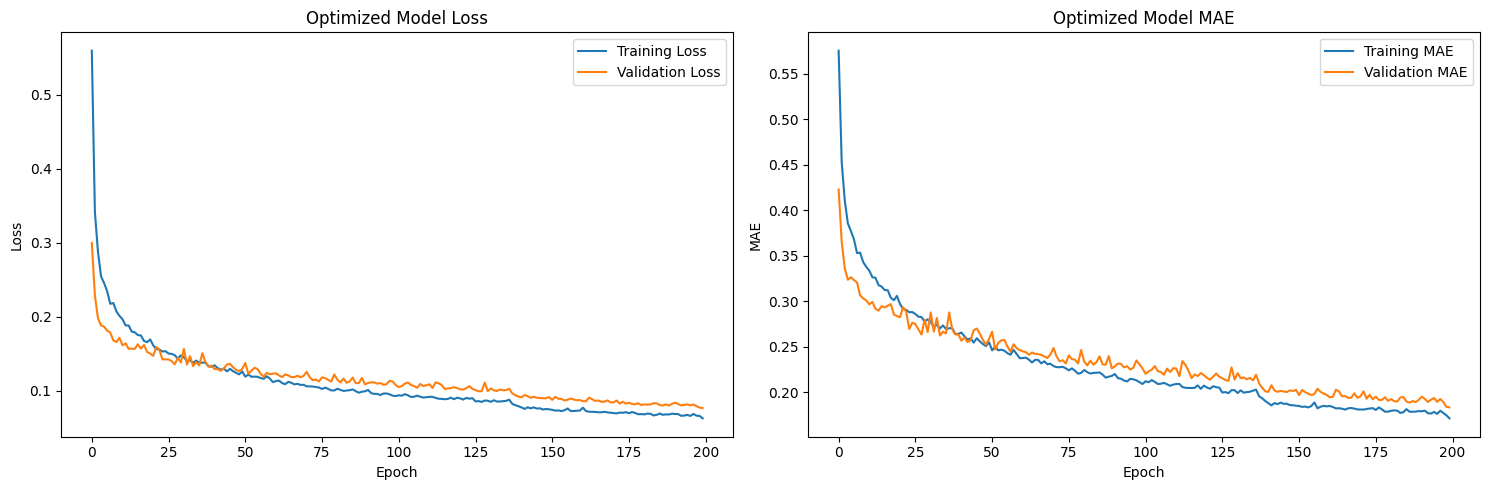

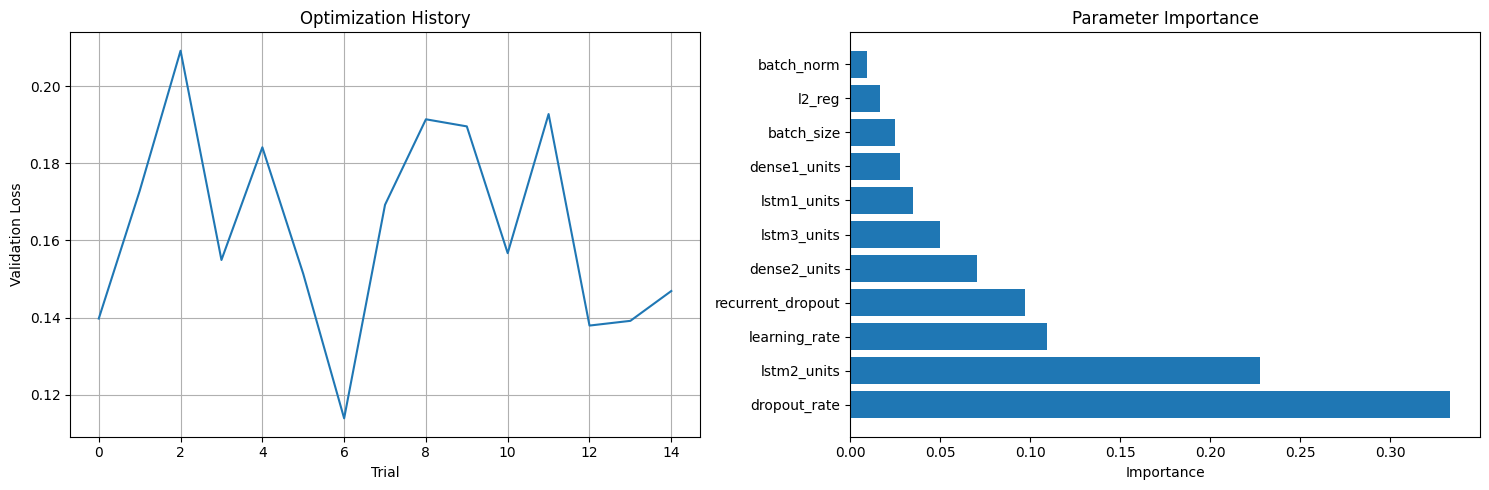

In [21]:
def run_optimized_temperature_forecasting(df, n_trials=20, timeout=None):
    
    print("🌡️ OPTUNA-OPTIMIZED MAXIMUM TEMPERATURE LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = OptimizedTemperatureMaxLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Optimize hyperparameters
    best_params = model.optimize_hyperparameters(n_trials=n_trials, timeout=timeout)
    
    # Train optimized model
    results, history, y_true, y_pred = model.train_optimized_model(
        validation_split=0.2, 
        epochs=200
    )
    
    # Plot results
    model.plot_training_history(history)
    model.plot_optimization_history()
    
    return model, results, history, y_true, y_pred, best_params

# Usage example:
model, results, history, y_true, y_pred, best_params = run_optimized_temperature_forecasting(
    df, n_trials=15, timeout=3600)

**c. Make predictions**


🔮 Making 3-day Maximum temperature forecast...
--------------------------------------------------
📅 3-Day Maximum Temperature Forecast:
  Thursday   (2025-05-01): 🌡️ 26.25 °C
  Friday     (2025-05-02): 🌡️ 26.95 °C
  Saturday   (2025-05-03): 🌡️ 27.17 °C


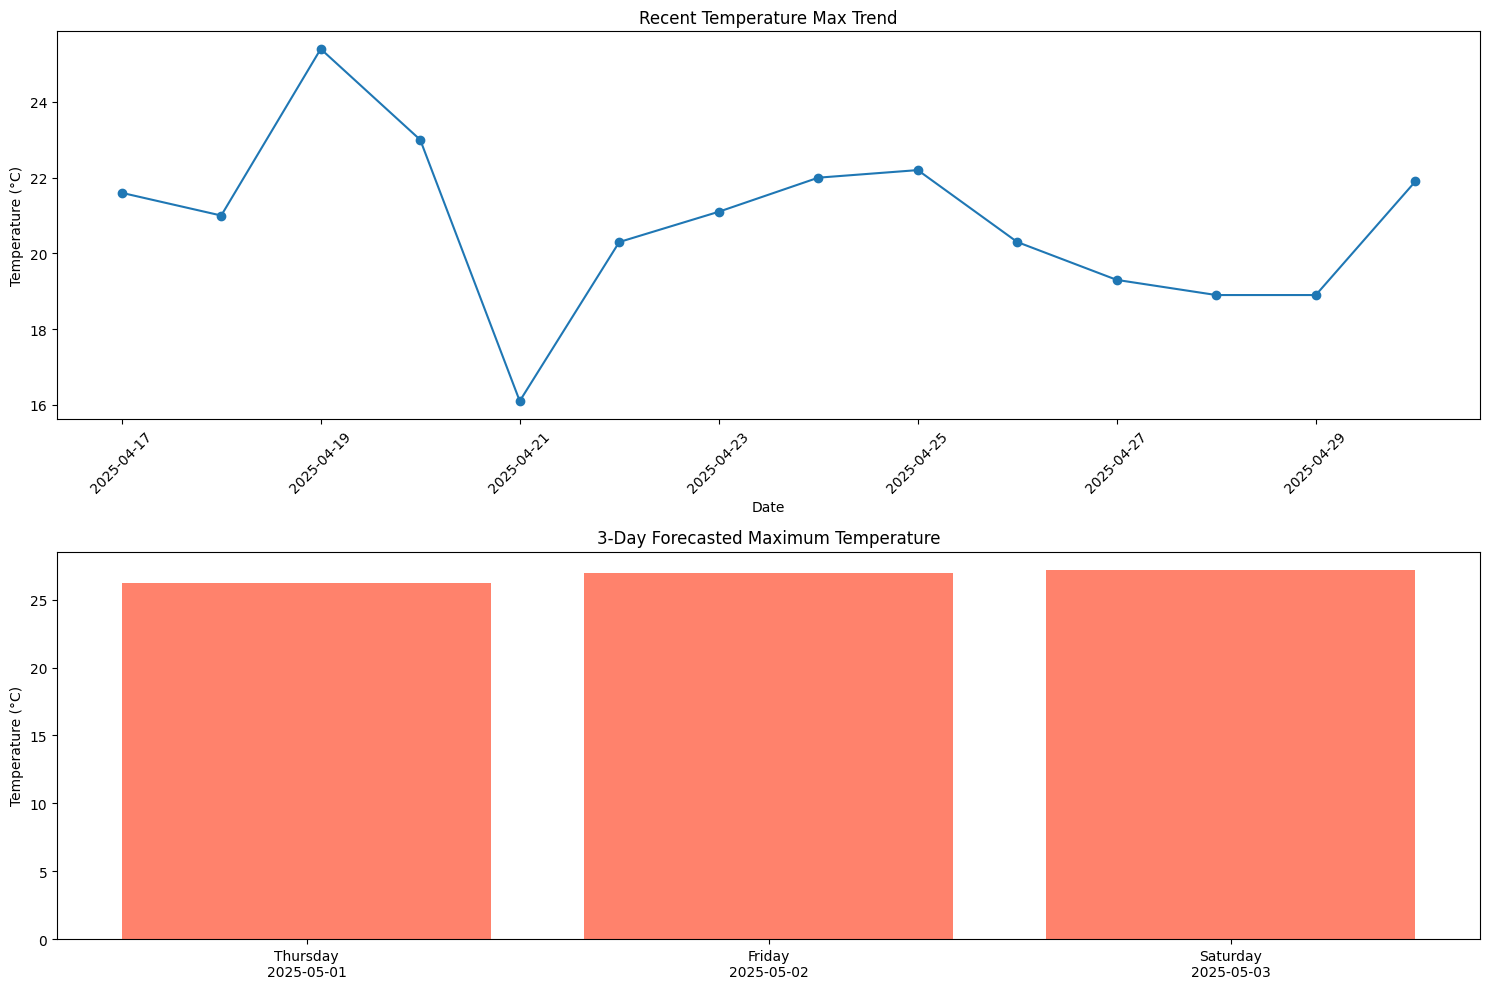

In [28]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Maximum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Maximum Temperature Forecast:")
        for (day, date), temp_result in zip(days_and_dates, temp_results):
            print(f"  {day:10} ({date}): 🌡️ {temp_result:.2f} °C")
        
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_max (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_max (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_max (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Max Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_labels = [f"{day}\n{date}" for day, date in days_and_dates]
        axes[1].bar(forecast_labels, temp_results, color='tomato', alpha=0.8)
        axes[1].set_title('3-Day Forecasted Maximum Temperature')
        axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

**d. Show predictions**

🌡️ MAXIMUM TEMPERATURE PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      35.00 |      34.70 |       0.30 |       0.8%
    2 |      35.50 |      36.27 |       0.77 |       2.2%
    3 |      37.80 |      37.61 |       0.19 |       0.5%
------------------------------------------------------------
Sequence MAE: 0.417

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  temperature_2m_max (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      27.00 |      27.44 |       0.44 |       1.6%
    2 |      29.90 |      29.31 |       0.59 |       2.0%
    3 |      33.70 |      31.61 |       2.09 |      

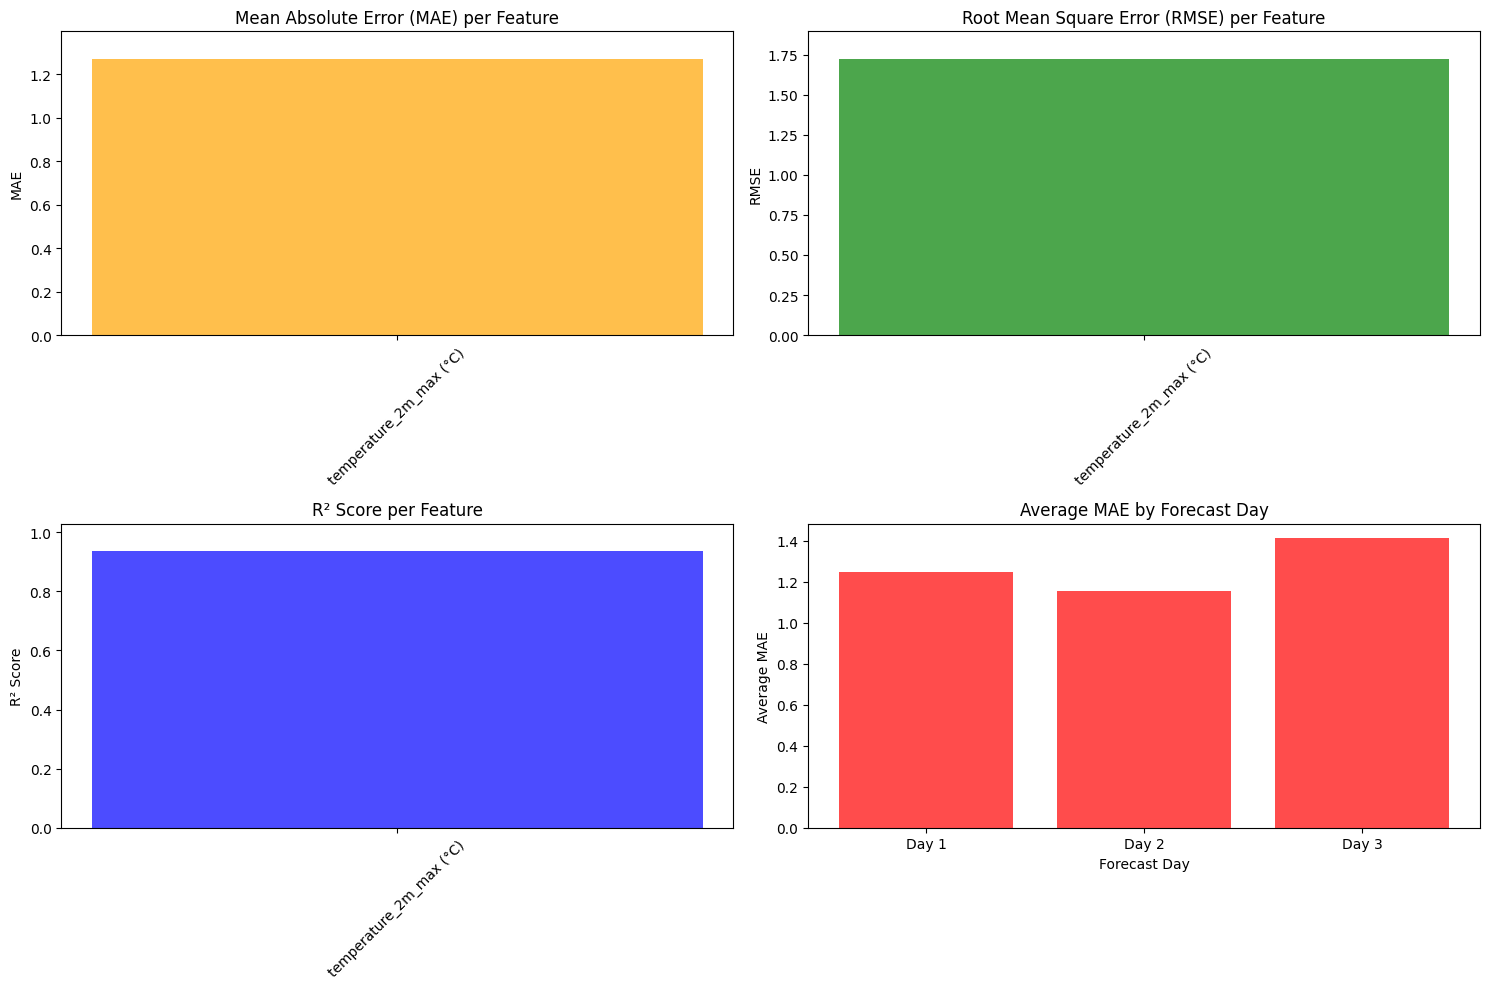


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_max (°C) (MAE: 1.271)
Worst performing feature: temperature_2m_max (°C) (MAE: 1.271)
Overall average MAE: 1.271
Overall average RMSE: 1.722
Overall average R²: 0.935


In [26]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MAXIMUM TEMPERATURE PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Daily performance comparison
    day_labels = [f"Day {i+1}" for i in range(model.forecast_horizon)]
    daily_maes = []
    
    for day in range(model.forecast_horizon):
        day_mae_all_features = []
        for f in range(num_features):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae_all_features.append(mean_absolute_error(day_true, day_pred))
        daily_maes.append(np.mean(day_mae_all_features))
    
    axes[1, 1].bar(day_labels, daily_maes, color='red', alpha=0.7)
    axes[1, 1].set_title("Average MAE by Forecast Day")
    axes[1, 1].set_ylabel("Average MAE")
    axes[1, 1].set_xlabel("Forecast Day")
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)

**e. Save the model**

In [27]:
def save_lstm_model(model, model_name="TemperatureMaxLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureMaxLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = OptimizedTemperatureMaxLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestMaximumTemperatureLSTM_Model1")

💾 Saving 'BestMaximumTemperatureLSTM_Model1' to: saved_models/BestMaximumTemperatureLSTM_Model1_20250704_110121
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**2- Hyperparameter tunning of the temp_min LSTM Model (option 15)**

**a. Create the model class**

In [29]:
class OptimizedTemperatureMinLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        self.best_params = None
        self.study = None
        
        # Temperature target columns
        self.target_cols = [
            'temperature_2m_min (°C)'
        ]
        
    def preprocess_data(self):
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition', 'relative_humidity_2m_max (%)', 'relative_humidity_2m_min (%)', 'temperature_2m_max (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model_with_params(self, trial, input_shape, output_shape):
        
        # Hyperparameters to optimize
        lstm1_units = trial.suggest_int('lstm1_units', 32, 256, step=32)
        lstm2_units = trial.suggest_int('lstm2_units', 16, 128, step=16)
        lstm3_units = trial.suggest_int('lstm3_units', 8, 64, step=8)
        
        dense1_units = trial.suggest_int('dense1_units', 32, 128, step=16)
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=8)
        
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
        recurrent_dropout = trial.suggest_float('recurrent_dropout', 0.1, 0.4, step=0.1)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_norm = trial.suggest_categorical('batch_norm', [True, False])
        
        model = Sequential()
        
        # First LSTM layer
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Second LSTM layer
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Third LSTM layer
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        # Dense layers
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        
        # Reshape to (forecast_horizon, num_target_variables)
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def objective(self, trial):
        
        try:
            # Create sequences
            X, y = self.create_sequences()
            
            if len(X) == 0:
                return float('inf')
            
            # Train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, shuffle=True
            )
            
            # Build model with trial parameters
            input_shape = (self.sequence_length, X.shape[2])
            output_shape = (self.forecast_horizon, len(self.available_targets))
            
            model = self.build_model_with_params(trial, input_shape, output_shape)
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            
            # Callbacks
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
            ]
            
            # Train model
            history = model.fit(
                X_train, y_train,
                epochs=50,  # Reduced for faster optimization
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=0
            )
            
            # Get best validation loss
            best_val_loss = min(history.history['val_loss'])
            
            # Clean up to free memory
            del model
            tf.keras.backend.clear_session()
            
            return best_val_loss
            
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    def optimize_hyperparameters(self, n_trials=20, timeout=None):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
        print("="*70)
        
        # Create study
        self.study = optuna.create_study(direction='minimize', 
                                        study_name='temperature_lstm_optimization')
        
        print(f"Starting optimization with {n_trials} trials...")
        if timeout:
            print(f"Timeout set to {timeout} seconds")
        
        # Optimize
        self.study.optimize(self.objective, n_trials=n_trials, timeout=timeout)
        
        # Get best parameters
        self.best_params = self.study.best_params
        
        print("\n🏆 OPTIMIZATION COMPLETED!")
        print("="*50)
        print(f"Best validation loss: {self.study.best_value:.6f}")
        print(f"Number of trials: {len(self.study.trials)}")
        
        print(f"\n🎯 BEST HYPERPARAMETERS:")
        print("-" * 40)
        for key, value in self.best_params.items():
            print(f"{key:20s}: {value}")
        
        return self.best_params
    
    def build_best_model(self, input_shape, output_shape):
        """Build model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        model = Sequential()
        
        # Use best parameters
        lstm1_units = self.best_params['lstm1_units']
        lstm2_units = self.best_params['lstm2_units']
        lstm3_units = self.best_params['lstm3_units']
        dense1_units = self.best_params['dense1_units']
        dense2_units = self.best_params['dense2_units']
        dropout_rate = self.best_params['dropout_rate']
        recurrent_dropout = self.best_params['recurrent_dropout']
        l2_reg = self.best_params['l2_reg']
        learning_rate = self.best_params['learning_rate']
        batch_norm = self.best_params['batch_norm']
        
        # Build architecture
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile with best parameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_optimized_model(self, validation_split=0.2, epochs=200):
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build optimized model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_best_model(input_shape, output_shape)
        
        print(f"\nOptimized model architecture:")
        self.model.summary()
        
        # Use best batch size
        batch_size = self.best_params.get('batch_size', 32)
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining optimized model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating optimized model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        print("\n" + "="*70)
        print("OPTIMIZED TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Optimization summary
        if self.best_params:
            print(f"\n🔧 OPTIMIZATION SUMMARY:")
            print("-" * 40)
            print(f"Best validation loss: {self.study.best_value:.6f}")
            print(f"Number of trials completed: {len(self.study.trials)}")
            print(f"Best LSTM architecture: {self.best_params['lstm1_units']}-{self.best_params['lstm2_units']}-{self.best_params['lstm3_units']}")
            print(f"Best Dense architecture: {self.best_params['dense1_units']}-{self.best_params['dense2_units']}")
            print(f"Best learning rate: {self.best_params['learning_rate']:.6f}")
            print(f"Best dropout rate: {self.best_params['dropout_rate']:.3f}")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data):
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_features.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be a DataFrame or NumPy array")

        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)

        # Inverse transform
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )

        predicted_values = prediction_original[0, :, 0] 

        return predicted_values
    
    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Optimized Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Optimized Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        
        if self.study is None:
            print("No optimization study available to plot.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Optimization history
        values = [trial.value for trial in self.study.trials if trial.value is not None]
        ax1.plot(values)
        ax1.set_title('Optimization History')
        ax1.set_xlabel('Trial')
        ax1.set_ylabel('Validation Loss')
        ax1.grid(True)
        
        # Parameter importance (if available)
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())
            importances = list(importance.values())
            
            ax2.barh(params, importances)
            ax2.set_title('Parameter Importance')
            ax2.set_xlabel('Importance')
        except:
            ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

**b. Train the model**

🌡️ OPTUNA-OPTIMIZED MINIMUM TEMPERATURE LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['temperature_2m_min (°C)']


[I 2025-07-04 11:06:17,119] A new study created in memory with name: temperature_lstm_optimization


Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['temperature_2m_min (°C)']
Data shape after preprocessing: (9252, 150)

🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA
Starting optimization with 15 trials...
Timeout set to 3600 seconds
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


[I 2025-07-04 11:12:07,687] Trial 0 finished with value: 0.08795993030071259 and parameters: {'lstm1_units': 256, 'lstm2_units': 96, 'lstm3_units': 56, 'dense1_units': 112, 'dense2_units': 16, 'dropout_rate': 0.1, 'recurrent_dropout': 0.1, 'l2_reg': 0.0003269790184405128, 'learning_rate': 0.006605691820098102, 'batch_norm': False, 'batch_size': 64}. Best is trial 0 with value: 0.08795993030071259.


🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        53,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 40)             │        16,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,131 (414.57 KB)

 Trainable params: 106,131 (414.57 KB)

 Non-trainable params: 0 (0.00 B)


Training optimized model...
Epoch 1/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - loss: 0.4804 - mae: 0.5111 - val_loss: 0.1695 - val_mae: 0.2760 - learning_rate: 9.8236e-04
Epoch 2/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.2169 - mae: 0.3296 - val_loss: 0.1437 - val_mae: 0.2526 - learning_rate: 9.8236e-04
Epoch 3/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1918 - mae: 0.3082 - val_loss: 0.1355 - val_mae: 0.2486 - learning_rate: 9.8236e-04
Epoch 4/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1788 - mae: 0.2995 - val_loss: 0.1481 - val_mae: 0.2708 - learning_rate: 9.8236e-04
Epoch 5/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1671 - mae: 0.2898 - val_loss: 0.1309 - val_mae: 0.2476 - learning_rate: 9.8236e-04
Epoch 6/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1575 - mae: 0.2821 - val_loss: 0.1210 - val_mae: 0.2380 - learning_rate: 9.8236e-04
Epoch 7/200
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1512 - mae: 0.2770

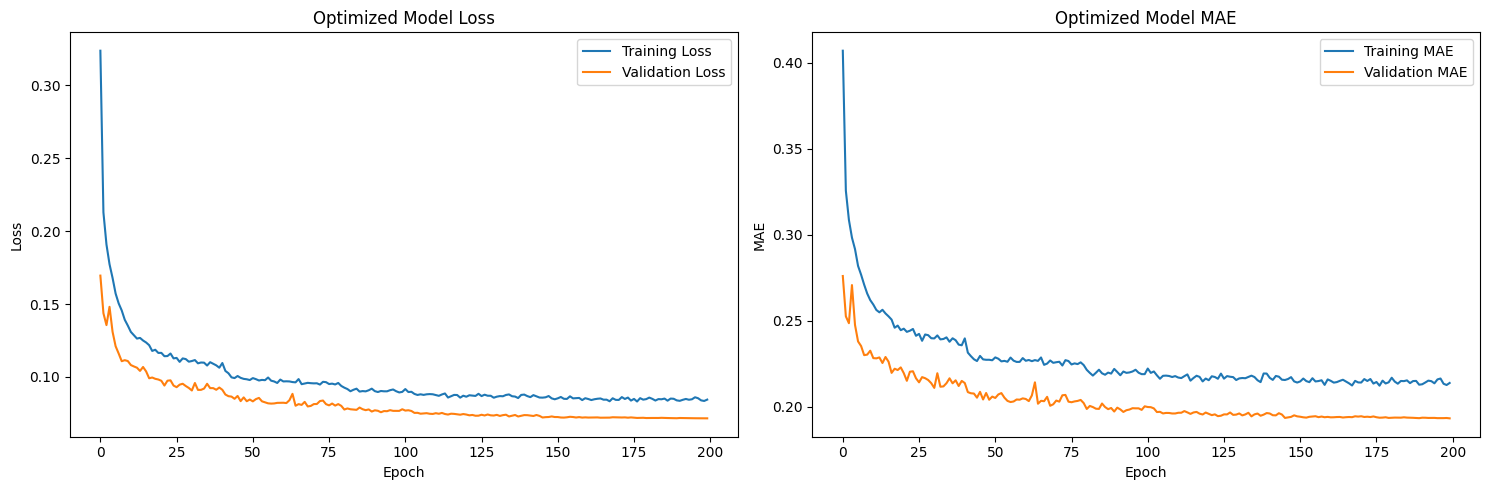

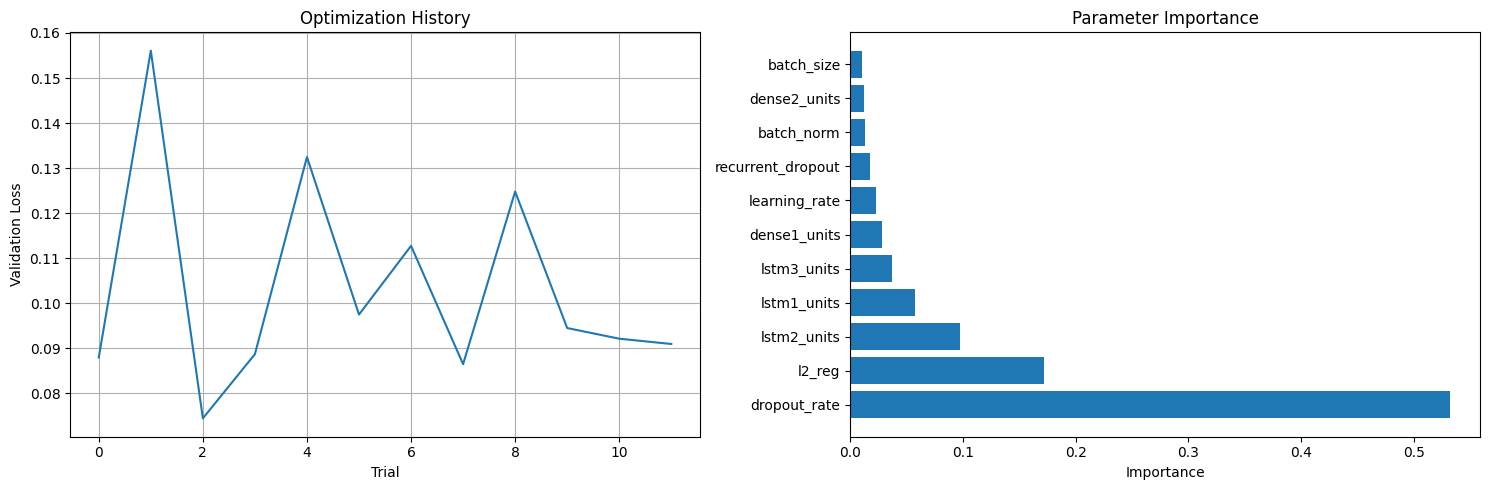

In [30]:
def run_optimized_temperature_forecasting(df, n_trials=20, timeout=None):
    
    print("🌡️ OPTUNA-OPTIMIZED MINIMUM TEMPERATURE LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = OptimizedTemperatureMinLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Optimize hyperparameters
    best_params = model.optimize_hyperparameters(n_trials=n_trials, timeout=timeout)
    
    # Train optimized model
    results, history, y_true, y_pred = model.train_optimized_model(
        validation_split=0.2, 
        epochs=200
    )
    
    # Plot results
    model.plot_training_history(history)
    model.plot_optimization_history()
    
    return model, results, history, y_true, y_pred, best_params

# Usage example:
model, results, history, y_true, y_pred, best_params = run_optimized_temperature_forecasting(
    df, n_trials=15, timeout=3600)

**c. Make predictions**


🔮 Making 3-day Minimum temperature forecast...
--------------------------------------------------
📅 3-Day Minimum Temperature Forecast:
  Thursday   (2025-05-01): 🌡️ 22.17 °C
  Friday     (2025-05-02): 🌡️ 22.17 °C
  Saturday   (2025-05-03): 🌡️ 22.16 °C


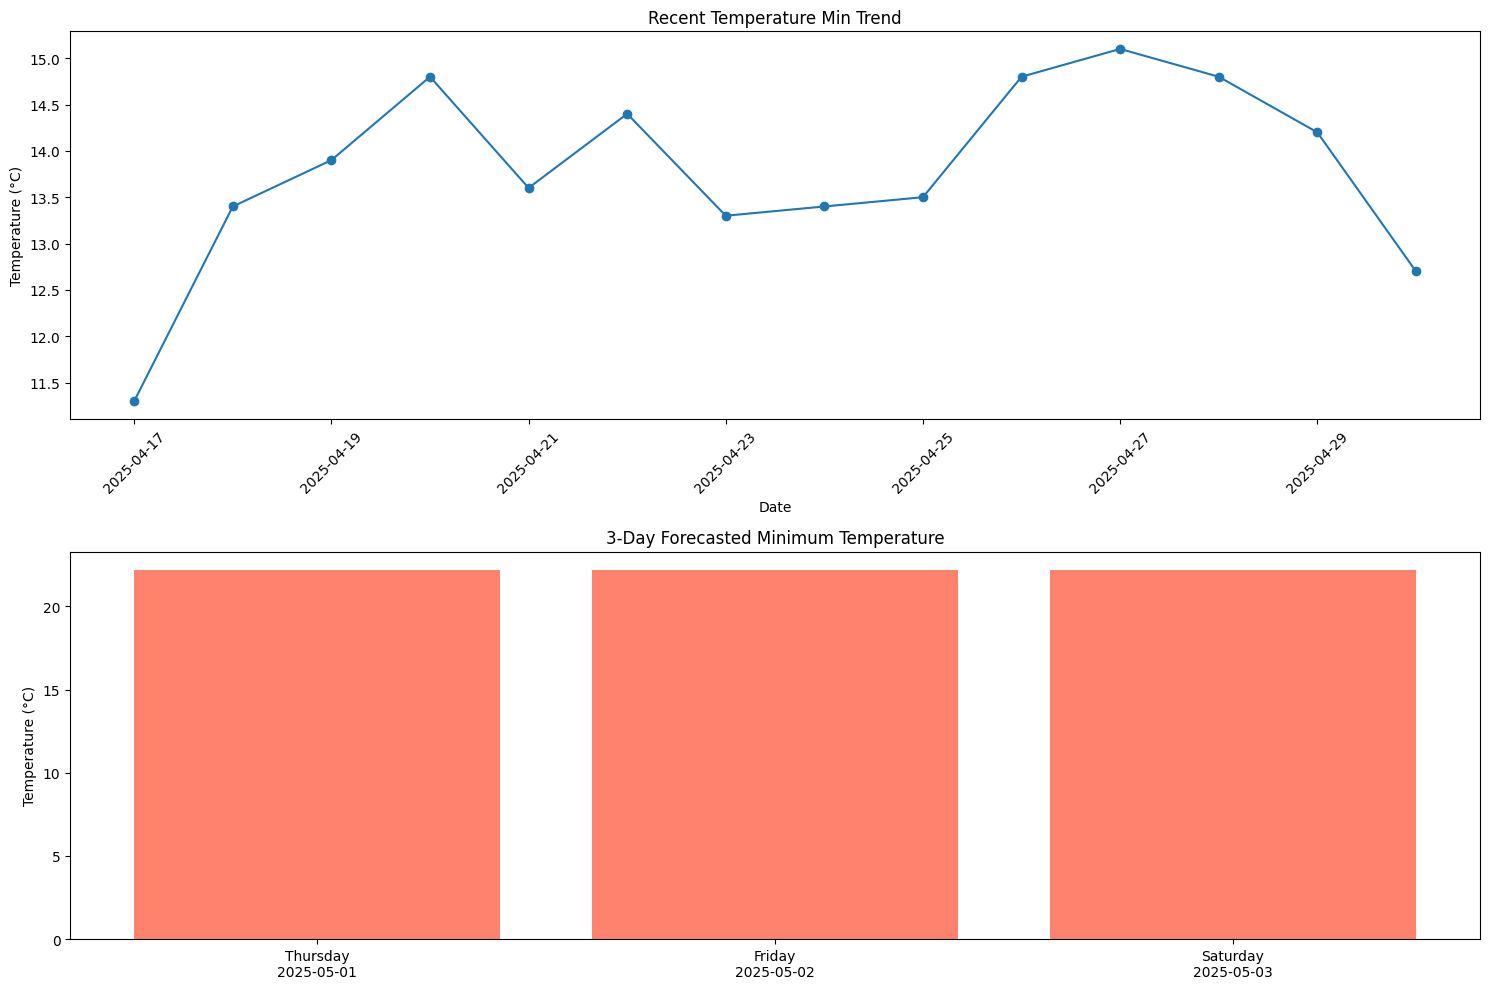

In [31]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for min temperature only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Minimum temperature forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        temp_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Minimum Temperature Forecast:")
        for (day, date), temp_result in zip(days_and_dates, temp_results):
            print(f"  {day:10} ({date}): 🌡️ {temp_result:.2f} °C")
        
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'temperature_2m_min (°C)' in df.columns:
            recent_temp = df[['date', 'temperature_2m_min (°C)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['temperature_2m_min (°C)'], 'o-')
            axes[0].set_title('Recent Temperature Min Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Temperature (°C)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_labels = [f"{day}\n{date}" for day, date in days_and_dates]
        axes[1].bar(forecast_labels, temp_results, color='tomato', alpha=0.8)
        axes[1].set_title('3-Day Forecasted Minimum Temperature')
        axes[1].set_ylabel('Temperature (°C)')
        
        plt.tight_layout()
        plt.show()
        
        return temp_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

**d. Show predictions**

🌡️ MINIMUM TEMPERATURE PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      21.90 |      23.46 |       1.56 |       7.1%
    2 |      23.90 |      23.44 |       0.46 |       1.9%
    3 |      24.90 |      23.43 |       1.47 |       5.9%
------------------------------------------------------------
Sequence MAE: 1.163

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  temperature_2m_min (°C):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      20.40 |      21.02 |       0.62 |       3.0%
    2 |      20.70 |      21.03 |       0.33 |       1.6%
    3 |      22.90 |      21.01 |       1.89 |      

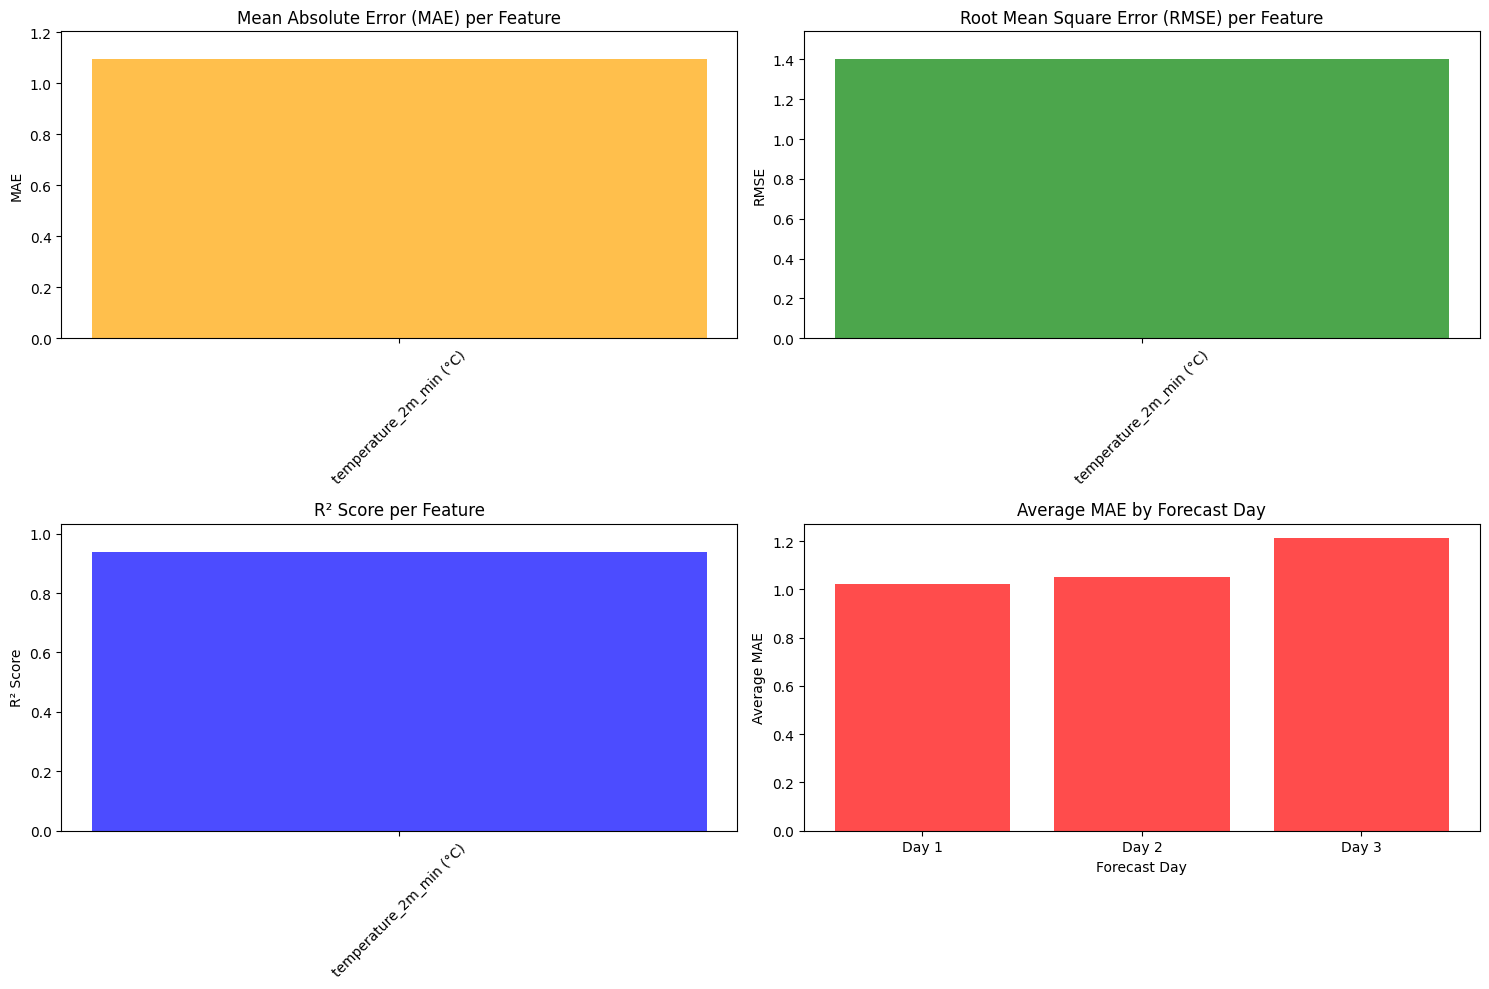


🏆 PERFORMANCE SUMMARY:
Best performing feature: temperature_2m_min (°C) (MAE: 1.094)
Worst performing feature: temperature_2m_min (°C) (MAE: 1.094)
Overall average MAE: 1.094
Overall average RMSE: 1.401
Overall average R²: 0.939


In [32]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MINIMUM TEMPERATURE PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Daily performance comparison
    day_labels = [f"Day {i+1}" for i in range(model.forecast_horizon)]
    daily_maes = []
    
    for day in range(model.forecast_horizon):
        day_mae_all_features = []
        for f in range(num_features):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae_all_features.append(mean_absolute_error(day_true, day_pred))
        daily_maes.append(np.mean(day_mae_all_features))
    
    axes[1, 1].bar(day_labels, daily_maes, color='red', alpha=0.7)
    axes[1, 1].set_title("Average MAE by Forecast Day")
    axes[1, 1].set_ylabel("Average MAE")
    axes[1, 1].set_xlabel("Forecast Day")
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)


**e. Save the model**

In [33]:

def save_lstm_model(model, model_name="TemperatureMinLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'TemperatureMinLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = OptimizedTemperatureMinLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestMinimumTemperatureLSTM_Model1")

💾 Saving 'BestMinimumTemperatureLSTM_Model1' to: saved_models/BestMinimumTemperatureLSTM_Model1_20250704_122946
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**3- Hyperparameter tunning of the humidity_max LSTM Model (option 15)**

**a. Create the model class**

In [36]:
class OptimizedHumidityMaxLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        self.best_params = None
        self.study = None
        
        # Temperature target columns
        self.target_cols = [
            'relative_humidity_2m_max (%)'
        ]
        
    def preprocess_data(self):
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition', 'temperature_2m_max (°C)', 'relative_humidity_2m_min (%)', 'temperature_2m_min (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model_with_params(self, trial, input_shape, output_shape):
        
        # Hyperparameters to optimize
        lstm1_units = trial.suggest_int('lstm1_units', 32, 256, step=32)
        lstm2_units = trial.suggest_int('lstm2_units', 16, 128, step=16)
        lstm3_units = trial.suggest_int('lstm3_units', 8, 64, step=8)
        
        dense1_units = trial.suggest_int('dense1_units', 32, 128, step=16)
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=8)
        
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
        recurrent_dropout = trial.suggest_float('recurrent_dropout', 0.1, 0.4, step=0.1)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_norm = trial.suggest_categorical('batch_norm', [True, False])
        
        model = Sequential()
        
        # First LSTM layer
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Second LSTM layer
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Third LSTM layer
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        # Dense layers
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        
        # Reshape to (forecast_horizon, num_target_variables)
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def objective(self, trial):
        
        try:
            # Create sequences
            X, y = self.create_sequences()
            
            if len(X) == 0:
                return float('inf')
            
            # Train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, shuffle=True
            )
            
            # Build model with trial parameters
            input_shape = (self.sequence_length, X.shape[2])
            output_shape = (self.forecast_horizon, len(self.available_targets))
            
            model = self.build_model_with_params(trial, input_shape, output_shape)
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            
            # Callbacks
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
            ]
            
            # Train model
            history = model.fit(
                X_train, y_train,
                epochs=50,  # Reduced for faster optimization
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=0
            )
            
            # Get best validation loss
            best_val_loss = min(history.history['val_loss'])
            
            # Clean up to free memory
            del model
            tf.keras.backend.clear_session()
            
            return best_val_loss
            
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    def optimize_hyperparameters(self, n_trials=20, timeout=None):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
        print("="*70)
        
        # Create study
        self.study = optuna.create_study(direction='minimize', 
                                        study_name='temperature_lstm_optimization')
        
        print(f"Starting optimization with {n_trials} trials...")
        if timeout:
            print(f"Timeout set to {timeout} seconds")
        
        # Optimize
        self.study.optimize(self.objective, n_trials=n_trials, timeout=timeout)
        
        # Get best parameters
        self.best_params = self.study.best_params
        
        print("\n🏆 OPTIMIZATION COMPLETED!")
        print("="*50)
        print(f"Best validation loss: {self.study.best_value:.6f}")
        print(f"Number of trials: {len(self.study.trials)}")
        
        print(f"\n🎯 BEST HYPERPARAMETERS:")
        print("-" * 40)
        for key, value in self.best_params.items():
            print(f"{key:20s}: {value}")
        
        return self.best_params
    
    def build_best_model(self, input_shape, output_shape):
        """Build model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        model = Sequential()
        
        # Use best parameters
        lstm1_units = self.best_params['lstm1_units']
        lstm2_units = self.best_params['lstm2_units']
        lstm3_units = self.best_params['lstm3_units']
        dense1_units = self.best_params['dense1_units']
        dense2_units = self.best_params['dense2_units']
        dropout_rate = self.best_params['dropout_rate']
        recurrent_dropout = self.best_params['recurrent_dropout']
        l2_reg = self.best_params['l2_reg']
        learning_rate = self.best_params['learning_rate']
        batch_norm = self.best_params['batch_norm']
        
        # Build architecture
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile with best parameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_optimized_model(self, validation_split=0.2, epochs=200):
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build optimized model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_best_model(input_shape, output_shape)
        
        print(f"\nOptimized model architecture:")
        self.model.summary()
        
        # Use best batch size
        batch_size = self.best_params.get('batch_size', 32)
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining optimized model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating optimized model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        print("\n" + "="*70)
        print("OPTIMIZED TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Optimization summary
        if self.best_params:
            print(f"\n🔧 OPTIMIZATION SUMMARY:")
            print("-" * 40)
            print(f"Best validation loss: {self.study.best_value:.6f}")
            print(f"Number of trials completed: {len(self.study.trials)}")
            print(f"Best LSTM architecture: {self.best_params['lstm1_units']}-{self.best_params['lstm2_units']}-{self.best_params['lstm3_units']}")
            print(f"Best Dense architecture: {self.best_params['dense1_units']}-{self.best_params['dense2_units']}")
            print(f"Best learning rate: {self.best_params['learning_rate']:.6f}")
            print(f"Best dropout rate: {self.best_params['dropout_rate']:.3f}")
        
        return results, history, y_true_original, y_pred_original
    
    
    def predict_future(self, recent_data):
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_features.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be a DataFrame or NumPy array")

        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)

        # Inverse transform
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )

        predicted_values = prediction_original[0, :, 0]  

        return predicted_values  
    
    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Optimized Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Optimized Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        
        if self.study is None:
            print("No optimization study available to plot.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Optimization history
        values = [trial.value for trial in self.study.trials if trial.value is not None]
        ax1.plot(values)
        ax1.set_title('Optimization History')
        ax1.set_xlabel('Trial')
        ax1.set_ylabel('Validation Loss')
        ax1.grid(True)
        
        # Parameter importance (if available)
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())
            importances = list(importance.values())
            
            ax2.barh(params, importances)
            ax2.set_title('Parameter Importance')
            ax2.set_xlabel('Importance')
        except:
            ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

**b. Train the model**

🌡️ OPTUNA-OPTIMIZED MAXIMUM HUMIDITY LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['relative_humidity_2m_max (%)']


[I 2025-07-04 12:30:21,052] A new study created in memory with name: temperature_lstm_optimization


Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['relative_humidity_2m_max (%)']
Data shape after preprocessing: (9252, 150)

🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA
Starting optimization with 15 trials...
Timeout set to 3600 seconds
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


[I 2025-07-04 12:39:11,631] Trial 0 finished with value: 0.8318796753883362 and parameters: {'lstm1_units': 192, 'lstm2_units': 112, 'lstm3_units': 40, 'dense1_units': 112, 'dense2_units': 64, 'dropout_rate': 0.4, 'recurrent_dropout': 0.4, 'l2_reg': 0.0022785707919299306, 'learning_rate': 0.0016172793523261321, 'batch_norm': True, 'batch_size': 16}. Best is trial 0 with value: 0.8318796753883362.


🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 224)        │       330,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 112)        │       150,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491,923 (1.88 MB)

 Trainable params: 491,923 (1.88 MB)

 Non-trainable params: 0 (0.00 B)


Training optimized model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 1.3671 - mae: 0.7757 - val_loss: 1.2413 - val_mae: 0.7837 - learning_rate: 8.2377e-04
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 1.1755 - mae: 0.7735 - val_loss: 1.1236 - val_mae: 0.7623 - learning_rate: 8.2377e-04
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 1.0916 - mae: 0.7601 - val_loss: 1.0740 - val_mae: 0.7623 - learning_rate: 8.2377e-04
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 1.0364 - mae: 0.7525 - val_loss: 1.0727 - val_mae: 0.7558 - learning_rate: 8.2377e-04
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 1.0075 - mae: 0.7415 - val_loss: 1.0187 - val_mae: 0.7382 - learning_rate: 8.2377e-04
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.9632 - mae: 0.7286 - val_loss: 0.9770 - val_mae: 0.7424 - learning_rate: 8.2377e-04
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.9761 - mae: 0.7342 - val_loss: 0

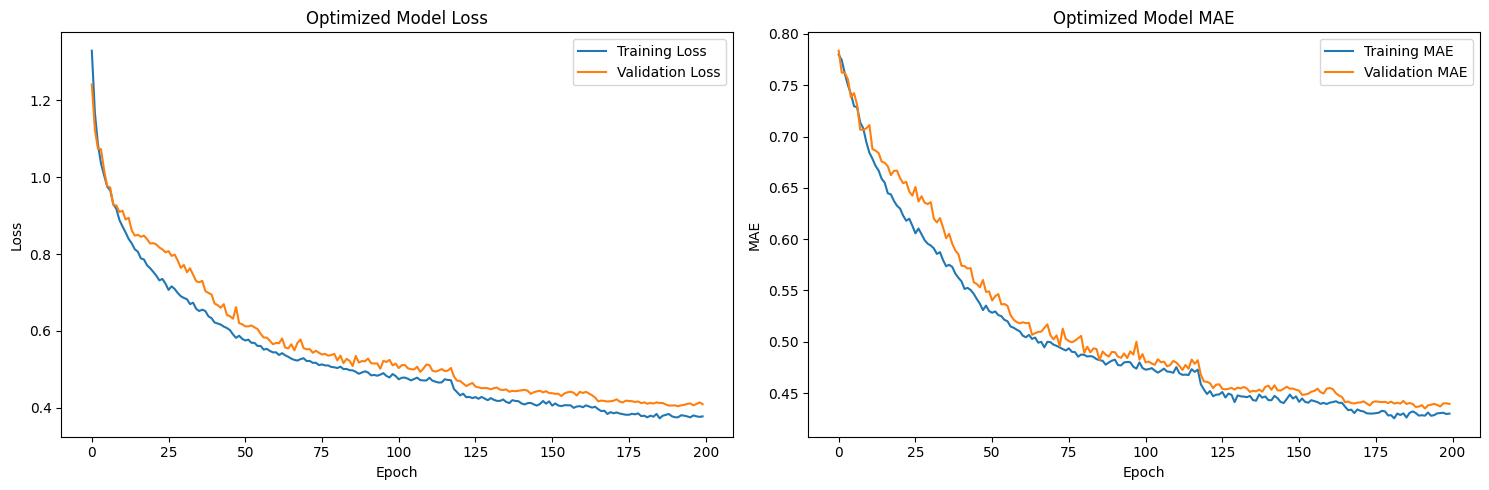

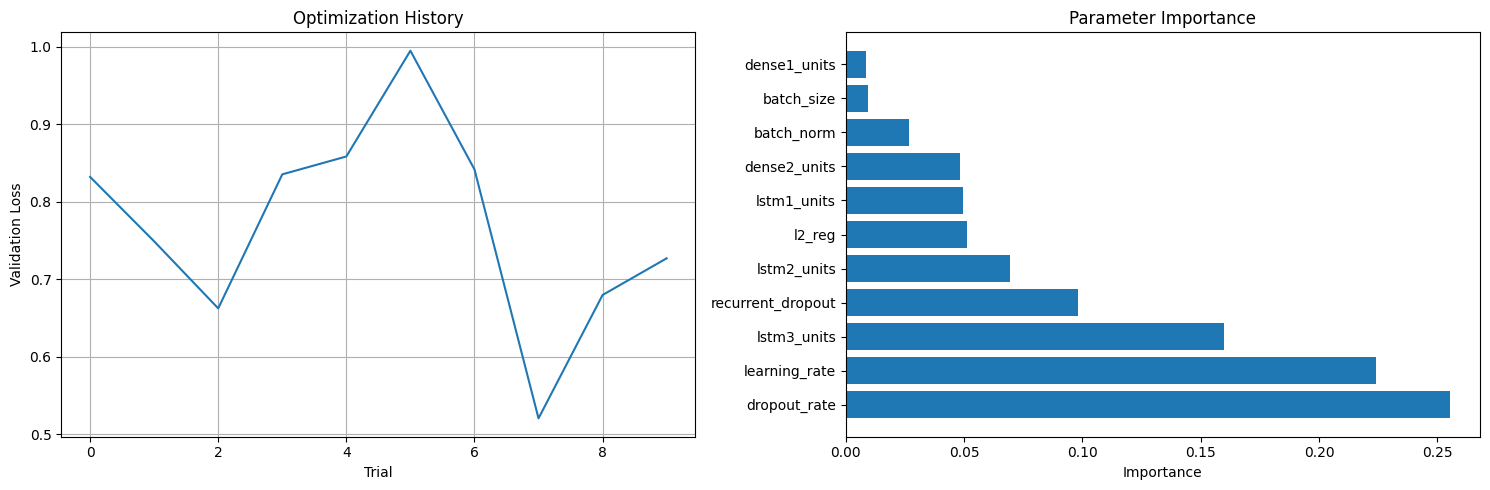

In [37]:
def run_optimized_humidity_forecasting(df, n_trials=20, timeout=None):
    
    print("🌡️ OPTUNA-OPTIMIZED MAXIMUM HUMIDITY LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = OptimizedHumidityMaxLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Optimize hyperparameters
    best_params = model.optimize_hyperparameters(n_trials=n_trials, timeout=timeout)
    
    # Train optimized model
    results, history, y_true, y_pred = model.train_optimized_model(
        validation_split=0.2, 
        epochs=200
    )
    
    # Plot results
    model.plot_training_history(history)
    model.plot_optimization_history()
    
    return model, results, history, y_true, y_pred, best_params

# Usage example:
model, results, history, y_true, y_pred, best_params = run_optimized_humidity_forecasting(
    df, n_trials=15, timeout=3600)

**c. Make predictions**


🔮 Making 3-day Maximum Humidity forecast...
--------------------------------------------------
📅 3-Day Maximum Temperature Forecast:
  Thursday   (2025-05-01): 🌡️ 89.36 %
  Friday     (2025-05-02): 🌡️ 86.45 %
  Saturday   (2025-05-03): 🌡️ 84.85 %


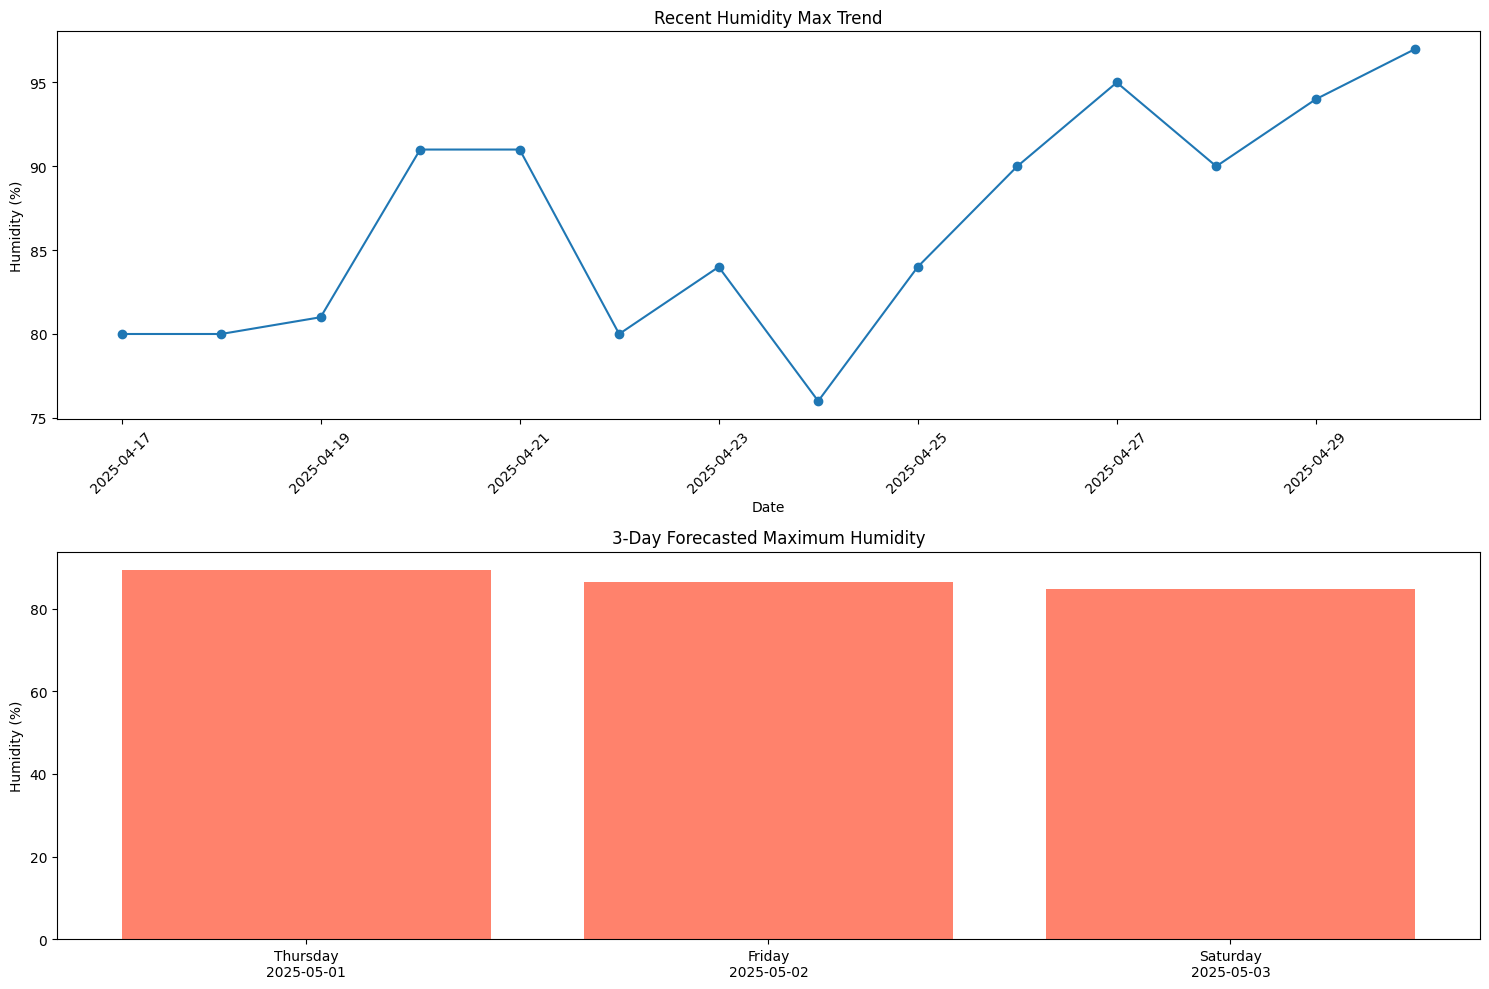

In [39]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for max humidity only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Maximum Humidity forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Maximum Temperature Forecast:")
        for (day, date), humidity_result in zip(days_and_dates, humidity_results):
            print(f"  {day:10} ({date}): 🌡️ {humidity_result:.2f} %")
        
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'relative_humidity_2m_max (%)' in df.columns:
            recent_temp = df[['date', 'relative_humidity_2m_max (%)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['relative_humidity_2m_max (%)'], 'o-')
            axes[0].set_title('Recent Humidity Max Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Humidity (%)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_labels = [f"{day}\n{date}" for day, date in days_and_dates]
        axes[1].bar(forecast_labels, humidity_results, color='tomato', alpha=0.8)
        axes[1].set_title('3-Day Forecasted Maximum Humidity')
        axes[1].set_ylabel('Humidity (%)')
        
        plt.tight_layout()
        plt.show()
        
        return humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

**d. Show predictions**

🌡️ MAXIMUM HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  relative_humidity_2m_max (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      98.00 |      91.91 |       6.09 |       6.2%
    2 |      90.00 |      91.80 |       1.80 |       2.0%
    3 |      87.00 |      90.78 |       3.78 |       4.3%
------------------------------------------------------------
Sequence MAE: 3.889

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  relative_humidity_2m_max (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      89.00 |      91.20 |       2.20 |       2.5%
    2 |      93.00 |      92.40 |       0.60 |       0.6%
    3 |      92.00 |      92.71 |       0.71 

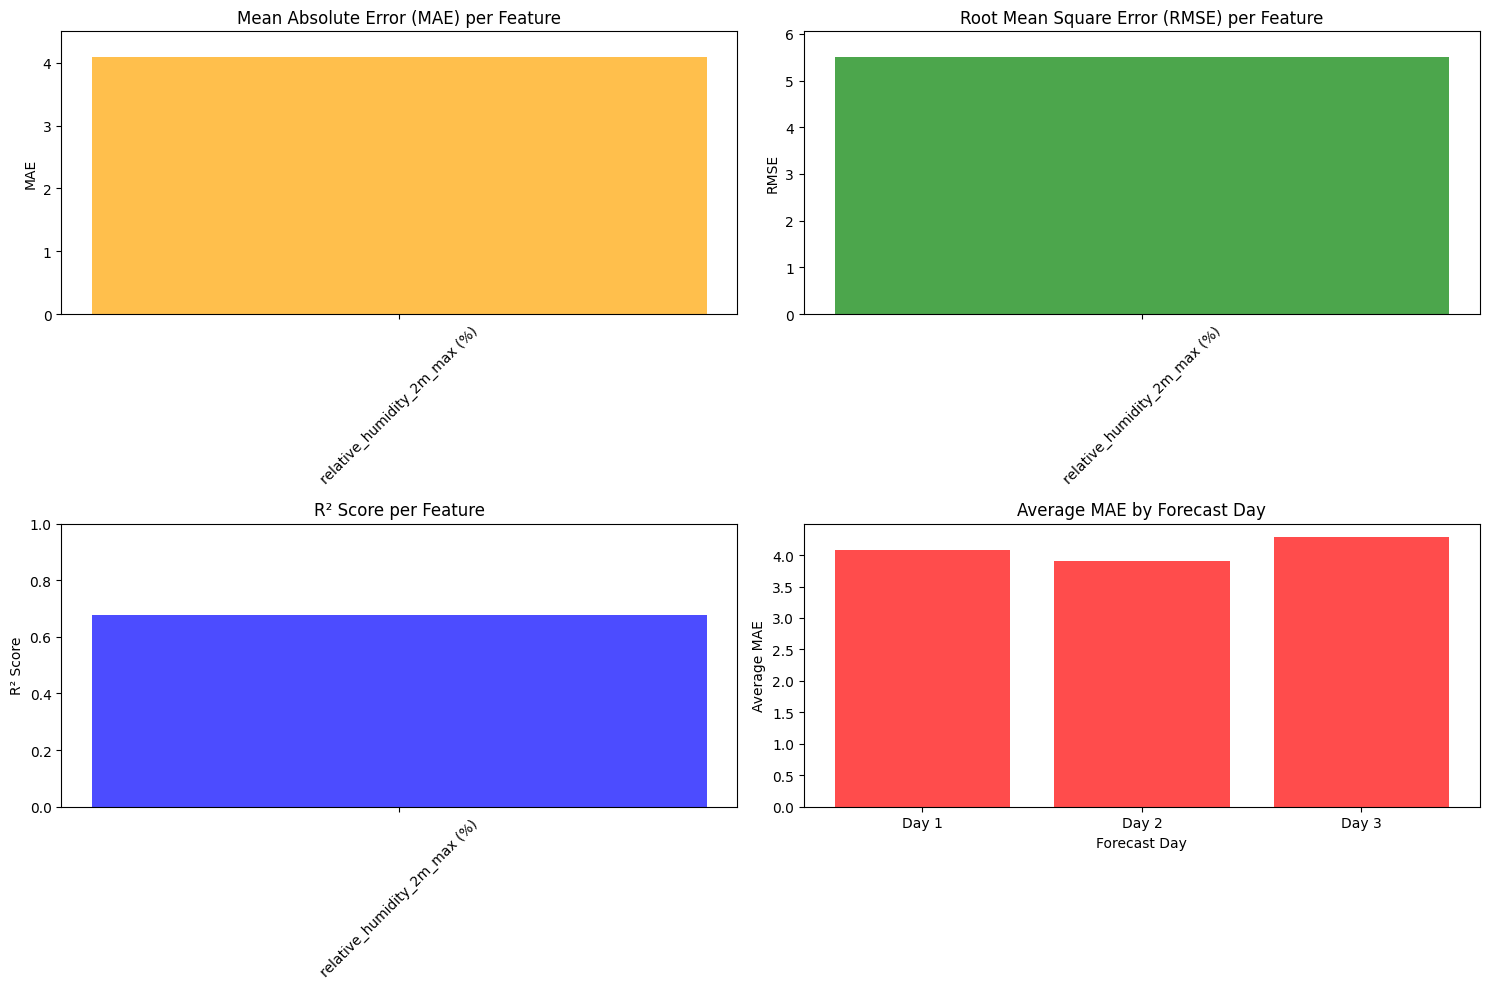


🏆 PERFORMANCE SUMMARY:
Best performing feature: relative_humidity_2m_max (%) (MAE: 4.092)
Worst performing feature: relative_humidity_2m_max (%) (MAE: 4.092)
Overall average MAE: 4.092
Overall average RMSE: 5.505
Overall average R²: 0.676


In [40]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MAXIMUM HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Daily performance comparison
    day_labels = [f"Day {i+1}" for i in range(model.forecast_horizon)]
    daily_maes = []
    
    for day in range(model.forecast_horizon):
        day_mae_all_features = []
        for f in range(num_features):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae_all_features.append(mean_absolute_error(day_true, day_pred))
        daily_maes.append(np.mean(day_mae_all_features))
    
    axes[1, 1].bar(day_labels, daily_maes, color='red', alpha=0.7)
    axes[1, 1].set_title("Average MAE by Forecast Day")
    axes[1, 1].set_ylabel("Average MAE")
    axes[1, 1].set_xlabel("Forecast Day")
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)






**e. Save the model**

In [41]:
def save_lstm_model(model, model_name="HumidityMaxLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'HumidityMaxLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = OptimizedHumidityMaxLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestMaximumHumidityLSTM_Model1")

💾 Saving 'BestMaximumHumidityLSTM_Model1' to: saved_models/BestMaximumHumidityLSTM_Model1_20250704_134945
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**4- Hyperparameter tunning of the humidity_min LSTM Model (option 15)**

**a. Create the model class**

In [42]:
class OptimizedHumidityMinLSTM:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        self.df = df.copy()
        self.sequence_length = sequence_length
        self.forecast_horizon = forecast_horizon
        self.scaler_features = None
        self.scaler_targets = None
        self.model = None
        self.best_params = None
        self.study = None
        
        # Temperature target columns
        self.target_cols = [
            'relative_humidity_2m_min (%)'
        ]
        
    def preprocess_data(self):
        print("🧹 Preprocessing data for max temperature prediction...")
        df = self.df.copy()
        
        # Check which target columns are available
        available_targets = [col for col in self.target_cols if col in df.columns]
        if not available_targets:
            raise ValueError(f"None of the target columns {self.target_cols} found in the dataframe")
        
        self.available_targets = available_targets
        print(f"Available target columns: {available_targets}")
        
        # Handle missing values for targets
        for col in available_targets:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with any missing target values
        df = df.dropna(subset=available_targets)
        
        # Define feature columns (exclude date, weather_condition, and target columns)
        exclude_cols = ['date', 'weather_condition', 'temperature_2m_max (°C)', 'relative_humidity_2m_max (%)', 'temperature_2m_min (°C)'] + available_targets
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        # Handle missing values for features
        numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
            df[col] = df[col].interpolate(method='linear')
            df[col].fillna(df[col].median(), inplace=True)
        
        # Scale features
        self.scaler_features = StandardScaler()
        df[feature_cols] = self.scaler_features.fit_transform(df[feature_cols])
        
        # Scale targets
        self.scaler_targets = StandardScaler()
        df[available_targets] = self.scaler_targets.fit_transform(df[available_targets])
        
        # Store processed data
        self.df_processed = df
        self.feature_cols = feature_cols
        
        print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}..." if len(feature_cols) > 5 else f"Feature columns: {feature_cols}")
        print(f"Target columns: {available_targets}")
        print(f"Data shape after preprocessing: {df.shape}")
        
        return df
    
    def create_sequences(self):
        print(f"🪟 Creating sequences for Maximum temperature prediction...")
        
        X, y = [], []
        data = self.df_processed
        features = data[self.feature_cols].values
        targets = data[self.available_targets].values
        
        # Create sequences with sliding window
        for i in range(len(data) - self.sequence_length - self.forecast_horizon + 1):
            # Input sequence
            X_seq = features[i:i + self.sequence_length]
            
            # Target sequence (next forecast_horizon days)
            y_seq = targets[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            X.append(X_seq)
            y.append(y_seq)
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"Created sequences: X={X.shape}, y={y.shape}")
        print(f"Input sequence length: {self.sequence_length}")
        print(f"Forecast horizon: {self.forecast_horizon}")
        print(f"Number of features: {X.shape[2]}")
        print(f"Number of target variables: {y.shape[2]}")
        
        return X, y
    
    def build_model_with_params(self, trial, input_shape, output_shape):
        
        # Hyperparameters to optimize
        lstm1_units = trial.suggest_int('lstm1_units', 32, 256, step=32)
        lstm2_units = trial.suggest_int('lstm2_units', 16, 128, step=16)
        lstm3_units = trial.suggest_int('lstm3_units', 8, 64, step=8)
        
        dense1_units = trial.suggest_int('dense1_units', 32, 128, step=16)
        dense2_units = trial.suggest_int('dense2_units', 16, 64, step=8)
        
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
        recurrent_dropout = trial.suggest_float('recurrent_dropout', 0.1, 0.4, step=0.1)
        l2_reg = trial.suggest_float('l2_reg', 1e-5, 1e-2, log=True)
        
        learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        batch_norm = trial.suggest_categorical('batch_norm', [True, False])
        
        model = Sequential()
        
        # First LSTM layer
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Second LSTM layer
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        # Third LSTM layer
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        # Dense layers
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        # Output layer
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        
        # Reshape to (forecast_horizon, num_target_variables)
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def objective(self, trial):
        
        try:
            # Create sequences
            X, y = self.create_sequences()
            
            if len(X) == 0:
                return float('inf')
            
            # Train-validation split
            X_train, X_val, y_train, y_val = train_test_split(
                X, y, test_size=0.2, random_state=42, shuffle=True
            )
            
            # Build model with trial parameters
            input_shape = (self.sequence_length, X.shape[2])
            output_shape = (self.forecast_horizon, len(self.available_targets))
            
            model = self.build_model_with_params(trial, input_shape, output_shape)
            
            # Training parameters
            batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
            
            # Callbacks
            callbacks = [
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
            ]
            
            # Train model
            history = model.fit(
                X_train, y_train,
                epochs=50,  # Reduced for faster optimization
                batch_size=batch_size,
                validation_data=(X_val, y_val),
                callbacks=callbacks,
                verbose=0
            )
            
            # Get best validation loss
            best_val_loss = min(history.history['val_loss'])
            
            # Clean up to free memory
            del model
            tf.keras.backend.clear_session()
            
            return best_val_loss
            
        except Exception as e:
            print(f"Trial failed with error: {e}")
            return float('inf')
    
    def optimize_hyperparameters(self, n_trials=20, timeout=None):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA")
        print("="*70)
        
        # Create study
        self.study = optuna.create_study(direction='minimize', 
                                        study_name='temperature_lstm_optimization')
        
        print(f"Starting optimization with {n_trials} trials...")
        if timeout:
            print(f"Timeout set to {timeout} seconds")
        
        # Optimize
        self.study.optimize(self.objective, n_trials=n_trials, timeout=timeout)
        
        # Get best parameters
        self.best_params = self.study.best_params
        
        print("\n🏆 OPTIMIZATION COMPLETED!")
        print("="*50)
        print(f"Best validation loss: {self.study.best_value:.6f}")
        print(f"Number of trials: {len(self.study.trials)}")
        
        print(f"\n🎯 BEST HYPERPARAMETERS:")
        print("-" * 40)
        for key, value in self.best_params.items():
            print(f"{key:20s}: {value}")
        
        return self.best_params
    
    def build_best_model(self, input_shape, output_shape):
        """Build model with best parameters found by Optuna"""
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        model = Sequential()
        
        # Use best parameters
        lstm1_units = self.best_params['lstm1_units']
        lstm2_units = self.best_params['lstm2_units']
        lstm3_units = self.best_params['lstm3_units']
        dense1_units = self.best_params['dense1_units']
        dense2_units = self.best_params['dense2_units']
        dropout_rate = self.best_params['dropout_rate']
        recurrent_dropout = self.best_params['recurrent_dropout']
        l2_reg = self.best_params['l2_reg']
        learning_rate = self.best_params['learning_rate']
        batch_norm = self.best_params['batch_norm']
        
        # Build architecture
        model.add(LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                      kernel_regularizer=l2(l2_reg), 
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm2_units, return_sequences=True,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(LSTM(lstm3_units, return_sequences=False,
                      kernel_regularizer=l2(l2_reg),
                      dropout=dropout_rate, recurrent_dropout=recurrent_dropout))
        if batch_norm:
            model.add(BatchNormalization())
        
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        if batch_norm:
            model.add(BatchNormalization())
        model.add(Dropout(dropout_rate + 0.1))
        
        model.add(Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout_rate))
        
        model.add(Dense(output_shape[0] * output_shape[1], activation='linear'))
        model.add(tf.keras.layers.Reshape(output_shape))
        
        # Compile with best parameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='mse',
            metrics=['mae']
        )
        
        return model
    
    def train_optimized_model(self, validation_split=0.2, epochs=200):
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED TEMPERATURE MAX LSTM MODEL")
        print("="*70)
        
        if self.best_params is None:
            raise ValueError("No optimization performed yet. Run optimize_hyperparameters() first.")
        
        # Create sequences
        X, y = self.create_sequences()
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, shuffle=True
        )
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Build optimized model
        input_shape = (self.sequence_length, X.shape[2])
        output_shape = (self.forecast_horizon, len(self.available_targets))
        
        self.model = self.build_best_model(input_shape, output_shape)
        
        print(f"\nOptimized model architecture:")
        self.model.summary()
        
        # Use best batch size
        batch_size = self.best_params.get('batch_size', 32)
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model
        print(f"\nTraining optimized model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating optimized model...")
        y_pred = self.model.predict(X_test, verbose=0)
        
        return self.evaluate_model(y_test, y_pred, history)
    
    def evaluate_model(self, y_true, y_pred, history):
        print("\n" + "="*70)
        print("OPTIMIZED TEMPERATURE MAX LSTM RESULTS")
        print("="*70)
        
        # Inverse transform predictions and true values to original scale
        y_true_original = np.zeros_like(y_true)
        y_pred_original = np.zeros_like(y_pred)
        
        for day in range(self.forecast_horizon):
            y_true_original[:, day, :] = self.scaler_targets.inverse_transform(y_true[:, day, :])
            y_pred_original[:, day, :] = self.scaler_targets.inverse_transform(y_pred[:, day, :])
        
        # Calculate metrics for each target variable and forecast day
        results = {}
        
        for i, target_name in enumerate(self.available_targets):
            print(f"\n🌡️ {target_name}:")
            print("-" * 50)
            
            target_results = {
                'mae': [],
                'rmse': [],
                'r2': [],
                'mape': []
            }
            
            for day in range(self.forecast_horizon):
                y_true_day = y_true_original[:, day, i]
                y_pred_day = y_pred_original[:, day, i]
                
                mae = mean_absolute_error(y_true_day, y_pred_day)
                rmse = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
                r2 = r2_score(y_true_day, y_pred_day)
                
                # Calculate MAPE (Mean Absolute Percentage Error)
                mape = np.mean(np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))) * 100
                
                target_results['mae'].append(mae)
                target_results['rmse'].append(rmse)
                target_results['r2'].append(r2)
                target_results['mape'].append(mape)
                
                print(f"  Day {day+1}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, MAPE={mape:.2f}%")
            
            # Calculate averages
            avg_mae = np.mean(target_results['mae'])
            avg_rmse = np.mean(target_results['rmse'])
            avg_r2 = np.mean(target_results['r2'])
            avg_mape = np.mean(target_results['mape'])
            
            target_results['avg_mae'] = avg_mae
            target_results['avg_rmse'] = avg_rmse
            target_results['avg_r2'] = avg_r2
            target_results['avg_mape'] = avg_mape
            
            print(f"  Average: MAE={avg_mae:.3f}, RMSE={avg_rmse:.3f}, R²={avg_r2:.3f}, MAPE={avg_mape:.2f}%")
            
            results[target_name] = target_results
        
        # Overall performance summary
        print(f"\n📊 OVERALL PERFORMANCE SUMMARY:")
        print("="*50)
        
        all_maes = [results[target]['avg_mae'] for target in self.available_targets]
        all_rmses = [results[target]['avg_rmse'] for target in self.available_targets]
        all_r2s = [results[target]['avg_r2'] for target in self.available_targets]
        all_mapes = [results[target]['avg_mape'] for target in self.available_targets]
        
        print(f"Overall Average MAE: {np.mean(all_maes):.3f}")
        print(f"Overall Average RMSE: {np.mean(all_rmses):.3f}")
        print(f"Overall Average R²: {np.mean(all_r2s):.3f}")
        print(f"Overall Average MAPE: {np.mean(all_mapes):.2f}%")
        
        # Optimization summary
        if self.best_params:
            print(f"\n🔧 OPTIMIZATION SUMMARY:")
            print("-" * 40)
            print(f"Best validation loss: {self.study.best_value:.6f}")
            print(f"Number of trials completed: {len(self.study.trials)}")
            print(f"Best LSTM architecture: {self.best_params['lstm1_units']}-{self.best_params['lstm2_units']}-{self.best_params['lstm3_units']}")
            print(f"Best Dense architecture: {self.best_params['dense1_units']}-{self.best_params['dense2_units']}")
            print(f"Best learning rate: {self.best_params['learning_rate']:.6f}")
            print(f"Best dropout rate: {self.best_params['dropout_rate']:.3f}")
        
        return results, history, y_true_original, y_pred_original
    
    def predict_future(self, recent_data):
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_features.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_features.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be a DataFrame or NumPy array")

        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        prediction_scaled = self.model.predict(input_seq, verbose=0)

        # Inverse transform
        prediction_original = np.zeros_like(prediction_scaled)
        for day in range(self.forecast_horizon):
            prediction_original[0, day, :] = self.scaler_targets.inverse_transform(
                prediction_scaled[0, day, :].reshape(1, -1)
            )

        predicted_values = prediction_original[0, :, 0]  

        return predicted_values
    
    def plot_training_history(self, history):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Loss
        ax1.plot(history.history['loss'], label='Training Loss')
        ax1.plot(history.history['val_loss'], label='Validation Loss')
        ax1.set_title('Optimized Model Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # MAE
        ax2.plot(history.history['mae'], label='Training MAE')
        ax2.plot(history.history['val_mae'], label='Validation MAE')
        ax2.set_title('Optimized Model MAE')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MAE')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_optimization_history(self):
        
        if self.study is None:
            print("No optimization study available to plot.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        # Optimization history
        values = [trial.value for trial in self.study.trials if trial.value is not None]
        ax1.plot(values)
        ax1.set_title('Optimization History')
        ax1.set_xlabel('Trial')
        ax1.set_ylabel('Validation Loss')
        ax1.grid(True)
        
        # Parameter importance (if available)
        try:
            importance = optuna.importance.get_param_importances(self.study)
            params = list(importance.keys())
            importances = list(importance.values())
            
            ax2.barh(params, importances)
            ax2.set_title('Parameter Importance')
            ax2.set_xlabel('Importance')
        except:
            ax2.text(0.5, 0.5, 'Parameter importance\nnot available', 
                    ha='center', va='center', transform=ax2.transAxes)
        
        plt.tight_layout()
        plt.show()

**b. Train the model**

🌡️ OPTUNA-OPTIMIZED MINIMUM HUMIDITY LSTM FORECASTING
🧹 Preprocessing data for max temperature prediction...
Available target columns: ['relative_humidity_2m_min (%)']


[I 2025-07-04 13:50:00,294] A new study created in memory with name: temperature_lstm_optimization


Feature columns (144): ['year', 'month', 'day', 'dayofweek', 'is_weekend']...
Target columns: ['relative_humidity_2m_min (%)']
Data shape after preprocessing: (9252, 150)

🔧 HYPERPARAMETER OPTIMIZATION WITH OPTUNA
Starting optimization with 15 trials...
Timeout set to 3600 seconds
🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


[I 2025-07-04 13:53:05,257] Trial 0 finished with value: 0.31710729002952576 and parameters: {'lstm1_units': 128, 'lstm2_units': 64, 'lstm3_units': 64, 'dense1_units': 96, 'dense2_units': 16, 'dropout_rate': 0.1, 'recurrent_dropout': 0.30000000000000004, 'l2_reg': 0.00016337456284219645, 'learning_rate': 0.0020197280979197454, 'batch_norm': False, 'batch_size': 64}. Best is trial 0 with value: 0.31710729002952576.


🪟 Creating sequences for Maximum temperature prediction...
Created sequences: X=(9240, 10, 144), y=(9240, 3, 1)
Input sequence length: 10
Forecast horizon: 3
Number of features: 144
Number of target variables: 1


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │       139,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,051 (898.64 KB)

 Trainable params: 230,051 (898.64 KB)

 Non-trainable params: 0 (0.00 B)


Training optimized model...
Epoch 1/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.9940 - mae: 0.7539 - val_loss: 0.7884 - val_mae: 0.6649 - learning_rate: 0.0020
Epoch 2/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.8292 - mae: 0.6839 - val_loss: 0.7352 - val_mae: 0.6387 - learning_rate: 0.0020
Epoch 3/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.7300 - mae: 0.6440 - val_loss: 0.7014 - val_mae: 0.6229 - learning_rate: 0.0020
Epoch 4/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.7180 - mae: 0.6333 - val_loss: 0.6758 - val_mae: 0.6108 - learning_rate: 0.0020
Epoch 5/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.6725 - mae: 0.6145 - val_loss: 0.6935 - val_mae: 0.6246 - learning_rate: 0.0020
Epoch 6/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.6584 - mae: 0.6034 - val_loss: 0.6478 - val_mae: 0.5949 - learning_rate: 0.0020
Epoch 7/200
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.6149 - mae: 0.5802 - val_loss: 0.6457 - val_mae: 0.5933 

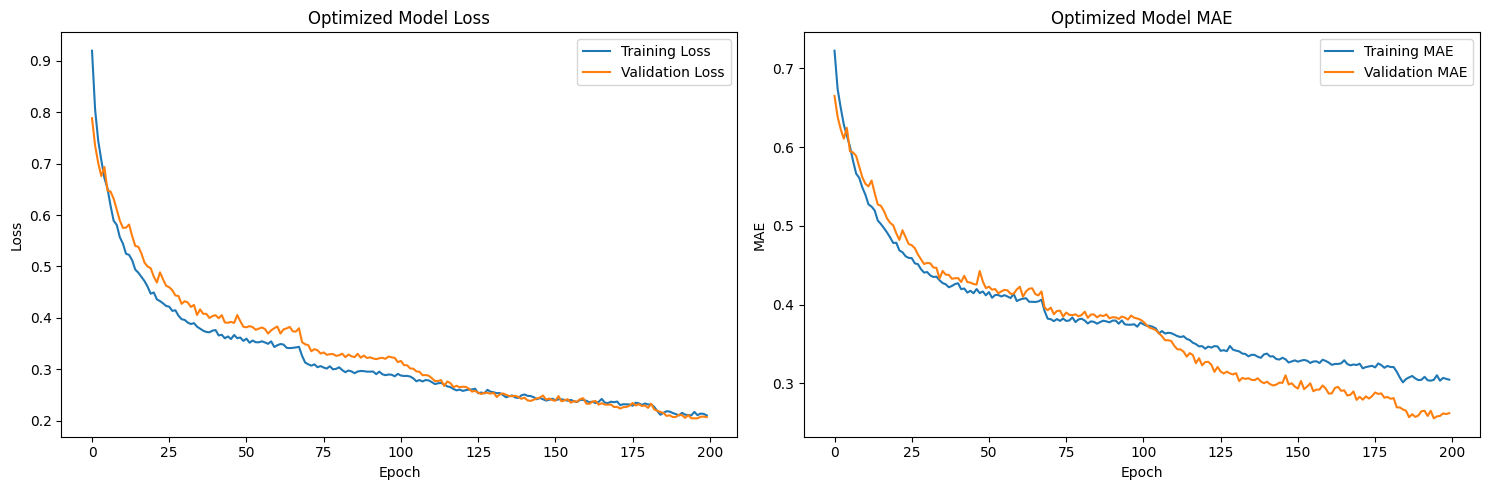

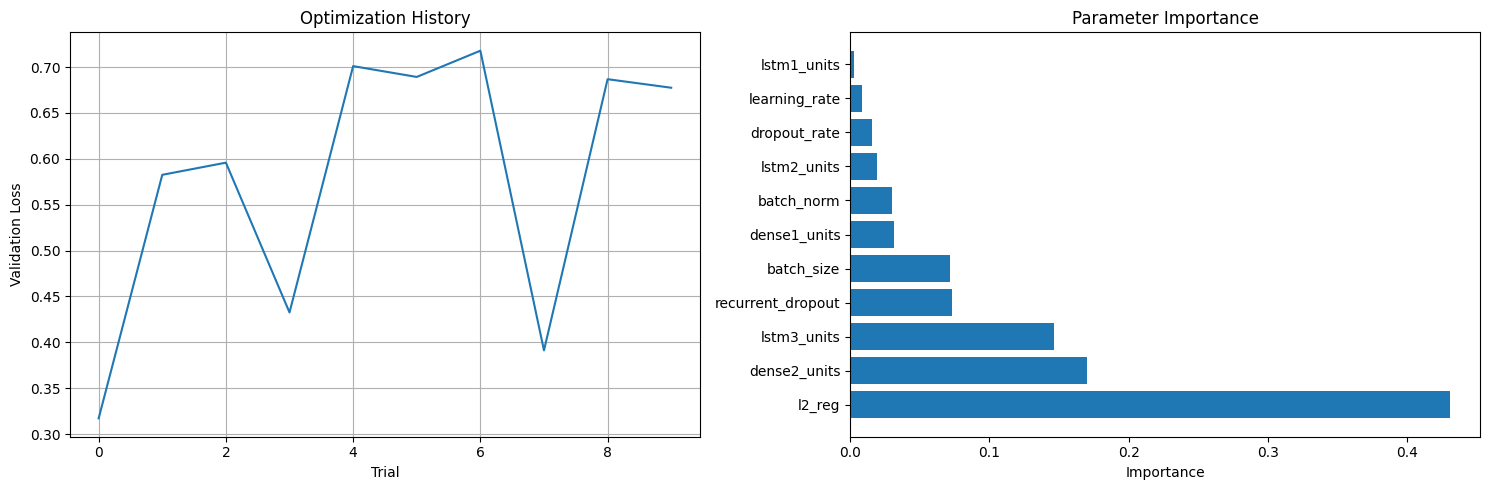

In [43]:
def run_optimized_humidity_forecasting(df, n_trials=20, timeout=None):
    
    print("🌡️ OPTUNA-OPTIMIZED MINIMUM HUMIDITY LSTM FORECASTING")
    print("=" * 70)
    
    # Initialize model
    model = OptimizedHumidityMinLSTM(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data()
    
    # Optimize hyperparameters
    best_params = model.optimize_hyperparameters(n_trials=n_trials, timeout=timeout)
    
    # Train optimized model
    results, history, y_true, y_pred = model.train_optimized_model(
        validation_split=0.2, 
        epochs=200
    )
    
    # Plot results
    model.plot_training_history(history)
    model.plot_optimization_history()
    
    return model, results, history, y_true, y_pred, best_params

# Usage example:
model, results, history, y_true, y_pred, best_params = run_optimized_humidity_forecasting(
    df, n_trials=15, timeout=3600)

**c. Make predictions**


🔮 Making 3-day Minimum Humidity forecast...
--------------------------------------------------
📅 3-Day Minimum Temperature Forecast:
  Thursday   (2025-05-01): 🌡️ 32.54 %
  Friday     (2025-05-02): 🌡️ 32.47 %
  Saturday   (2025-05-03): 🌡️ 32.58 %


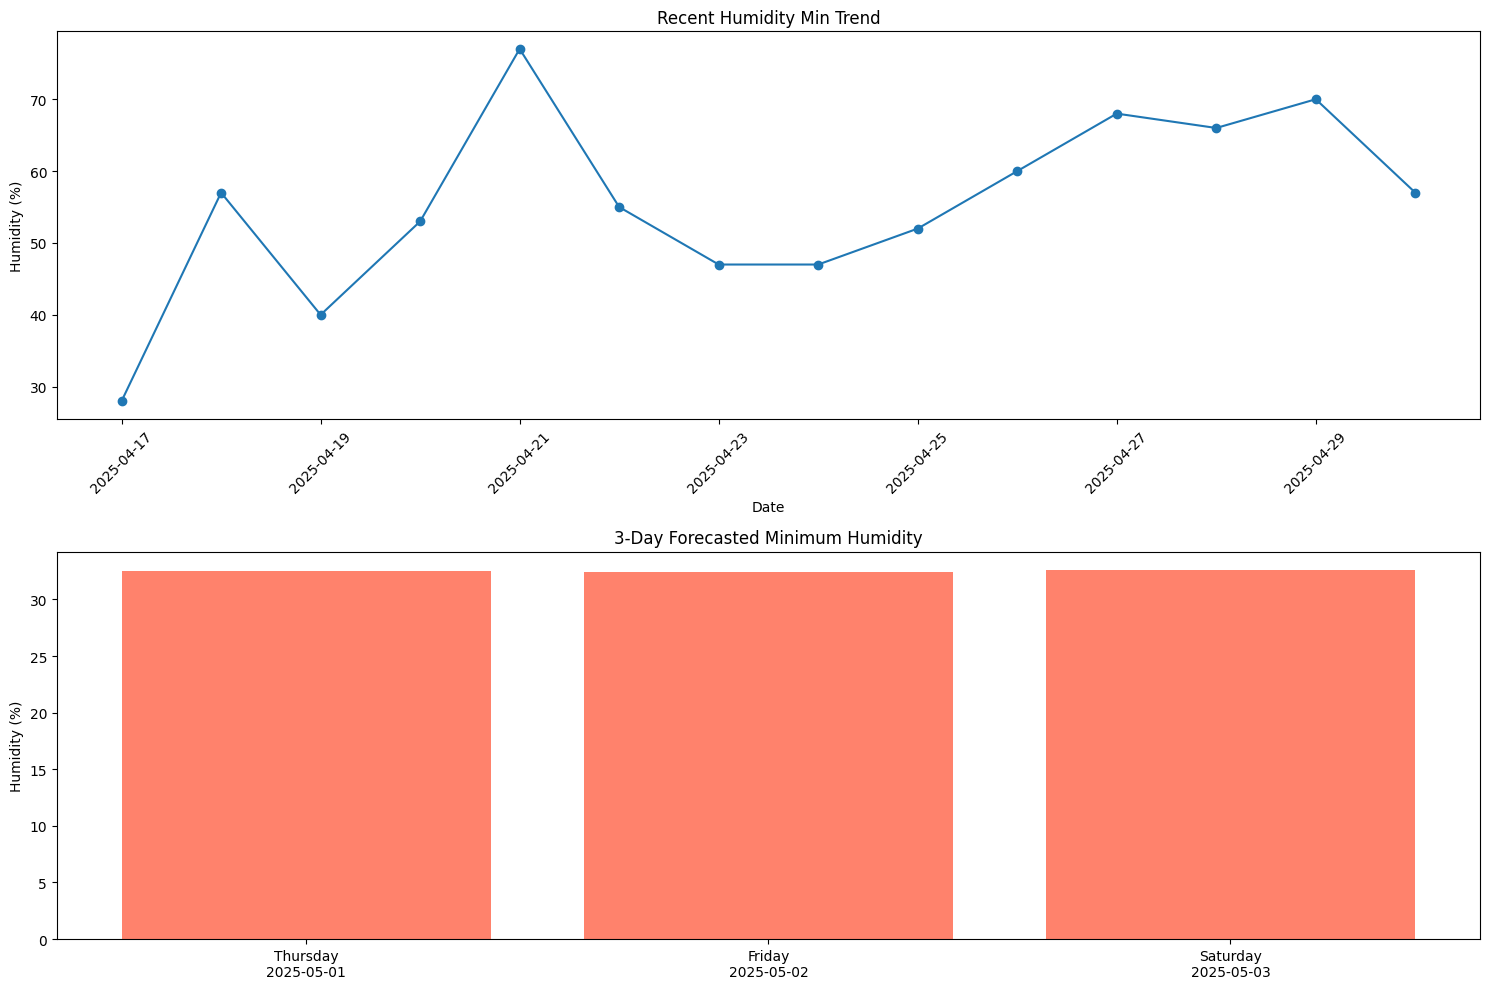

In [44]:
def make_predictions_and_visualize(model, df):
    """Make predictions and create visualizations for max humidity only"""
    import matplotlib.pyplot as plt
    from datetime import timedelta
    import pandas as pd
    import numpy as np
    
    print("\n🔮 Making 3-day Minimum Humidity forecast...")
    print("-" * 50)
    
    # Get only the features used during training
    feature_cols = model.feature_cols

    # Pull only the last `sequence_length` rows
    recent_data = df[feature_cols].tail(model.sequence_length).copy()

    # Ensure numeric and same dtype
    recent_data = recent_data.apply(pd.to_numeric, errors='coerce').dropna()

    # If any rows dropped, re-pad from the top
    if len(recent_data) < model.sequence_length:
        padding_needed = model.sequence_length - len(recent_data)
        padding = np.zeros((padding_needed, len(feature_cols)))
        recent_data = np.vstack([padding, recent_data.values])
    else:
        recent_data = recent_data.values

    # Final shape must be (1, sequence_length, num_features)
    recent_data = recent_data.reshape(1, model.sequence_length, len(feature_cols)).astype(np.float32)

    try:
        # Get temperature/humidity predictions
        humidity_results = model.predict_future(recent_data)
        
        # Get next 3 days
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]
        
        print("📅 3-Day Minimum Temperature Forecast:")
        for (day, date), humidity_result in zip(days_and_dates, humidity_results):
            print(f"  {day:10} ({date}): 🌡️ {humidity_result:.2f} %")
        
        
        # Visualization
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot recent temperature trends
        if 'relative_humidity_2m_min (%)' in df.columns:
            recent_temp = df[['date', 'relative_humidity_2m_min (%)']].tail(14)
            recent_temp['date'] = pd.to_datetime(recent_temp['date'])
            axes[0].plot(recent_temp['date'], recent_temp['relative_humidity_2m_min (%)'], 'o-')
            axes[0].set_title('Recent Humidity Min Trend')
            axes[0].set_xlabel('Date')
            axes[0].set_ylabel('Humidity (%)')
            axes[0].tick_params(axis='x', rotation=45)
        
        # Plot forecast temperature
        forecast_labels = [f"{day}\n{date}" for day, date in days_and_dates]
        axes[1].bar(forecast_labels, humidity_results, color='tomato', alpha=0.8)
        axes[1].set_title('3-Day Forecasted Minimum Humidity')
        axes[1].set_ylabel('Humidity (%)')
        
        plt.tight_layout()
        plt.show()
        
        return humidity_results
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None


# Usage example:

predictions = make_predictions_and_visualize(model, df)

**d. Show predictions**

🌡️ MINIMUM HUMIDITY PREDICTIONS

📅 Test Sequence 1:
------------------------------------------------------------

🌡️  relative_humidity_2m_min (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      31.00 |      29.98 |       1.02 |       3.3%
    2 |      31.00 |      30.80 |       0.20 |       0.6%
    3 |      30.00 |      31.13 |       1.13 |       3.8%
------------------------------------------------------------
Sequence MAE: 0.785

📅 Test Sequence 2:
------------------------------------------------------------

🌡️  relative_humidity_2m_min (%):
----------------------------------------
  Day |     Actual |  Predicted |      Error |    % Error
------------------------------------------------------------
    1 |      54.00 |      48.30 |       5.70 |      10.6%
    2 |      42.00 |      39.67 |       2.33 |       5.5%
    3 |      32.00 |      33.61 |       1.61 

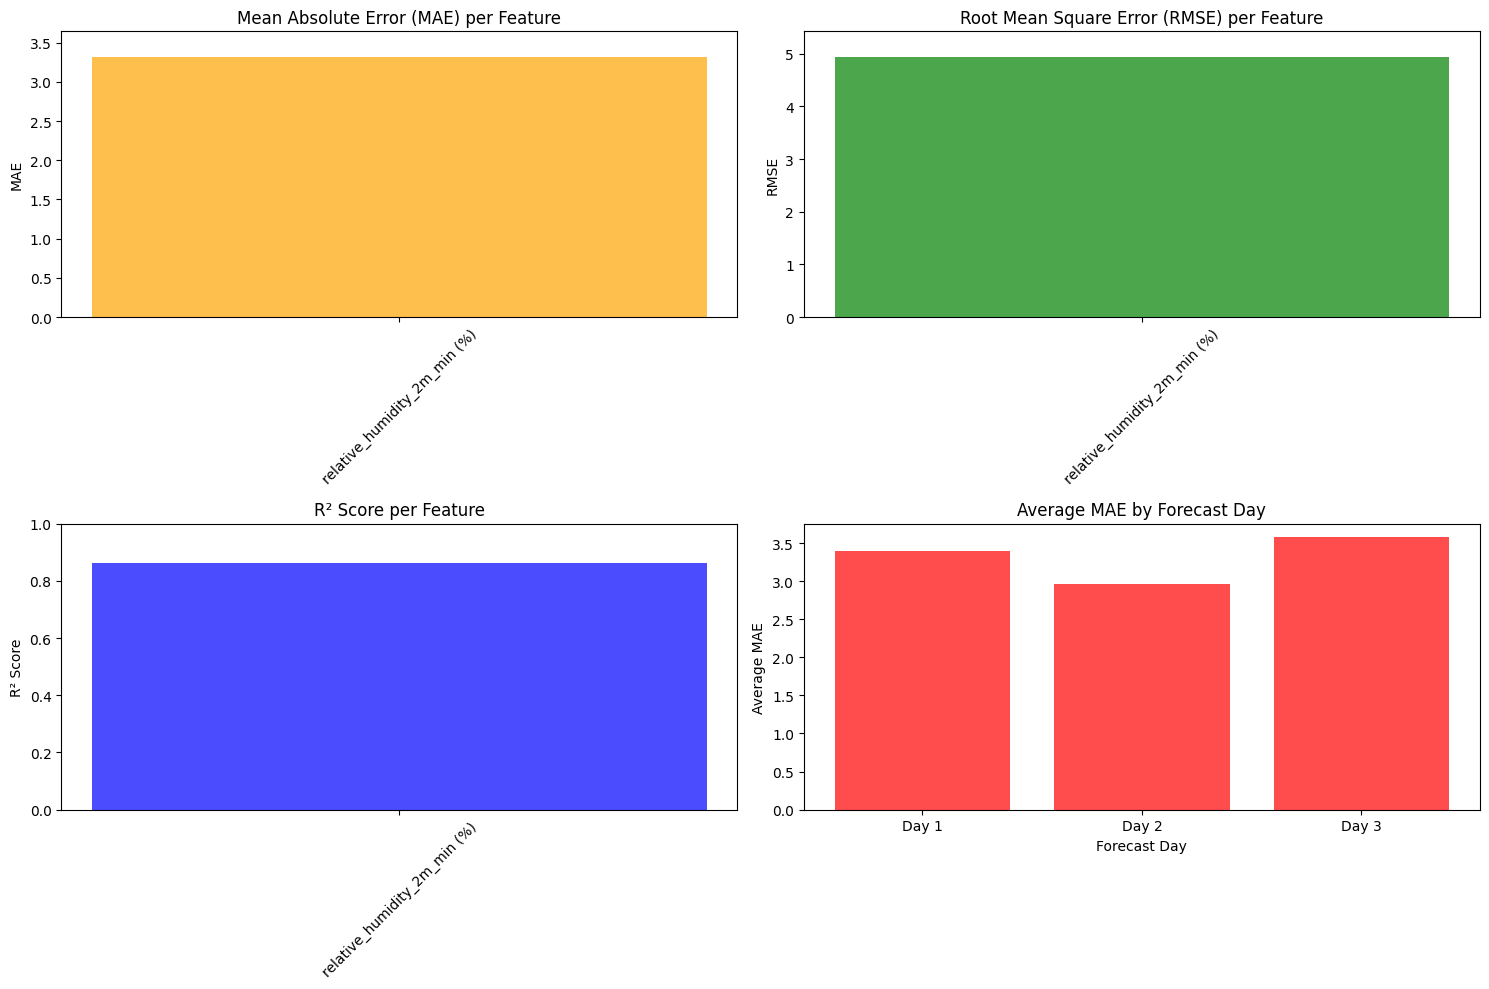


🏆 PERFORMANCE SUMMARY:
Best performing feature: relative_humidity_2m_min (%) (MAE: 3.314)
Worst performing feature: relative_humidity_2m_min (%) (MAE: 3.314)
Overall average MAE: 3.314
Overall average RMSE: 4.933
Overall average R²: 0.862


In [45]:
def show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=5
):
    """Display temperature min regression predictions only."""
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    print("🌡️ MINIMUM HUMIDITY PREDICTIONS")
    print("=" * 60)

    sample_size = min(num_samples, len(y_true))

    # Get feature names from the model
    feature_names = model.available_targets if hasattr(model, 'available_targets') else [f"Feature {i}" for i in range(y_true.shape[2])]

    # Display sample predictions
    for i in range(sample_size):
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 60)

        # Create a nice table format for each feature
        for f, feature_name in enumerate(feature_names):
            print(f"\n🌡️  {feature_name}:")
            print("-" * 40)
            print(f"{'Day':>5} | {'Actual':>10} | {'Predicted':>10} | {'Error':>10} | {'% Error':>10}")
            print("-" * 60)

            mae_sequence = 0
            for day in range(model.forecast_horizon):
                actual = y_true[i, day, f]
                predicted = y_pred[i, day, f]
                error = abs(actual - predicted)
                percent_error = (error / (abs(actual) + 1e-8)) * 100
                mae_sequence += error

                print(f"{day+1:>5} | {actual:>10.2f} | {predicted:>10.2f} | {error:>10.2f} | {percent_error:>9.1f}%")

            mae_sequence /= model.forecast_horizon
            print("-" * 60)
            print(f"Sequence MAE: {mae_sequence:.3f}")

    # Overall statistics for temperature and humidity
    print(f"\n📊 OVERALL REGRESSION STATISTICS:")
    print("=" * 50)

    num_features = y_true.shape[2]

    for f, feature_name in enumerate(feature_names):
        print(f"\n🌡️  {feature_name}:")
        print("-" * 30)
        
        # Calculate metrics for this feature
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        mae = mean_absolute_error(y_true_flat, y_pred_flat)
        rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
        r2 = r2_score(y_true_flat, y_pred_flat)
        mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100
        
        print(f"  MAE:  {mae:.3f}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  R²:   {r2:.3f}")
        print(f"  MAPE: {mape:.2f}%")
        
        # Per-day accuracy for this feature
        print(f"\n  📈 Daily Performance:")
        for day in range(model.forecast_horizon):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae = mean_absolute_error(day_true, day_pred)
            day_rmse = np.sqrt(mean_squared_error(day_true, day_pred))
            day_r2 = r2_score(day_true, day_pred)
            print(f"    Day {day+1}: MAE={day_mae:.3f}, RMSE={day_rmse:.3f}, R²={day_r2:.3f}")

    # Create visualization
    print(f"\n📈 CREATING PERFORMANCE VISUALIZATION...")
    
    # Calculate metrics for plotting
    maes = []
    rmses = []
    r2s = []
    
    for f in range(num_features):
        y_true_flat = y_true[:, :, f].flatten()
        y_pred_flat = y_pred[:, :, f].flatten()
        
        maes.append(mean_absolute_error(y_true_flat, y_pred_flat))
        rmses.append(np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)))
        r2s.append(r2_score(y_true_flat, y_pred_flat))

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # MAE plot
    axes[0, 0].bar(feature_names, maes, color='orange', alpha=0.7)
    axes[0, 0].set_title("Mean Absolute Error (MAE) per Feature")
    axes[0, 0].set_ylabel("MAE")
    axes[0, 0].set_ylim(0, max(maes) * 1.1)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # RMSE plot
    axes[0, 1].bar(feature_names, rmses, color='green', alpha=0.7)
    axes[0, 1].set_title("Root Mean Square Error (RMSE) per Feature")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].set_ylim(0, max(rmses) * 1.1)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # R² plot
    axes[1, 0].bar(feature_names, r2s, color='blue', alpha=0.7)
    axes[1, 0].set_title("R² Score per Feature")
    axes[1, 0].set_ylabel("R² Score")
    axes[1, 0].set_ylim(0, max(1.0, max(r2s) * 1.1))
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Daily performance comparison
    day_labels = [f"Day {i+1}" for i in range(model.forecast_horizon)]
    daily_maes = []
    
    for day in range(model.forecast_horizon):
        day_mae_all_features = []
        for f in range(num_features):
            day_true = y_true[:, day, f]
            day_pred = y_pred[:, day, f]
            day_mae_all_features.append(mean_absolute_error(day_true, day_pred))
        daily_maes.append(np.mean(day_mae_all_features))
    
    axes[1, 1].bar(day_labels, daily_maes, color='red', alpha=0.7)
    axes[1, 1].set_title("Average MAE by Forecast Day")
    axes[1, 1].set_ylabel("Average MAE")
    axes[1, 1].set_xlabel("Forecast Day")
    
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f"\n🏆 PERFORMANCE SUMMARY:")
    print("=" * 30)
    print(f"Best performing feature: {feature_names[np.argmin(maes)]} (MAE: {min(maes):.3f})")
    print(f"Worst performing feature: {feature_names[np.argmax(maes)]} (MAE: {max(maes):.3f})")
    print(f"Overall average MAE: {np.mean(maes):.3f}")
    print(f"Overall average RMSE: {np.mean(rmses):.3f}")
    print(f"Overall average R²: {np.mean(r2s):.3f}")


# Usage example - replace your original function call with this:
show_regression_predictions(
    model, 
    y_true, 
    y_pred, 
    num_samples=3
)






**e. Save the model**

In [46]:
def save_lstm_model(model, model_name="HumidityMinLSTM", save_dir="saved_models"):
    import os
    import json
    import pickle
    from datetime import datetime
    import joblib

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)

    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)

    try:
        # 1. Save the Keras model
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print("✅ Keras model saved.")

        # 2. Save scalers
        joblib.dump(model.scaler_features, f"{model_folder}/scaler_features.pkl")
        joblib.dump(model.scaler_targets, f"{model_folder}/scaler_targets.pkl")
        print("✅ Scalers saved.")

        # 3. Save config
        config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'available_targets': model.available_targets,
            'feature_columns': model.feature_cols,
            'timestamp': timestamp,
            'model_type': 'HumidityMinLSTM',
            'framework': 'TensorFlow/Keras'
        }
        with open(f"{model_folder}/model_config.json", 'w') as f:
            json.dump(config, f, indent=4)
        print("✅ Model configuration saved.")

        # 4. Save model object (without keras model to avoid issues)
        model_copy = model.__dict__.copy()
        model_copy.pop('model', None)
        with open(f"{model_folder}/full_model.pkl", 'wb') as f:
            pickle.dump(model_copy, f)
        print("✅ Full model object saved.")

        return model_folder

    except Exception as e:
        print(f"❌ Error saving model: {e}")
        return None



def load_lstm_model(model_folder):
    import os
    import json
    import pickle
    import joblib
    from tensorflow.keras.models import load_model

    try:
        print(f"📂 Loading model from: {model_folder}")

        # Load keras model
        keras_model = load_model(f"{model_folder}/keras_model.keras")

        # Load scalers
        scaler_features = joblib.load(f"{model_folder}/scaler_features.pkl")
        scaler_targets = joblib.load(f"{model_folder}/scaler_targets.pkl")

        # Load config
        with open(f"{model_folder}/model_config.json", 'r') as f:
            config = json.load(f)

        # Load full model dict
        with open(f"{model_folder}/full_model.pkl", 'rb') as f:
            model_dict = pickle.load(f)

        # Create empty model object
        model = OptimizedHumidityMinLSTM(pd.DataFrame(), config['sequence_length'], config['forecast_horizon'])
        model.model = keras_model
        model.scaler_features = scaler_features
        model.scaler_targets = scaler_targets

        # Restore other attributes
        for key, value in model_dict.items():
            setattr(model, key, value)

        print(f"✅ Model '{config['model_name']}' successfully loaded!")
        return model

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return None


model_folder = save_lstm_model(model, model_name="BestMinimumHumidityLSTM_Model1")

💾 Saving 'BestMinimumHumidityLSTM_Model1' to: saved_models/BestMinimumHumidityLSTM_Model1_20250704_150613
✅ Keras model saved.
✅ Scalers saved.
✅ Model configuration saved.
✅ Full model object saved.


**5- Hyperparameter tunning of the Weather condition LSTM Model (Model 3)**

**a. Create the model class**

In [7]:
class ImprovedSlidingWindowModel:
    def __init__(self, df, sequence_length=10, forecast_horizon=3):
        
        self.df = df.copy()
        self.forecast_horizon = forecast_horizon
        self.sequence_length = sequence_length
        self.scaler_X = None
        self.label_encoder = None
        self.model = None
        self.class_weights = None
        self.tuner = None
        self.best_hps = None
        
        # Improved thresholds for better balance
        self.minority_threshold = 0.08   # Very rare classes
        self.balanced_threshold = 0.20   # Medium frequency classes
        # Above 20% = majority classes
        
    def preprocess_data(self, target_col='weather_condition'):
        
        print("🧹 Enhanced preprocessing...")
        df = self.df.copy()
        
        # Handle missing values
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col != target_col:
                df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
                df[col] = df[col].interpolate(method='linear')
                df[col].fillna(df[col].median(), inplace=True)
        
        # Remove rows with missing target
        df = df.dropna(subset=[target_col])
        # 🔄 Merge specific weather classes
        df[target_col] = df[target_col].replace({
            'Mainly Clear 🌤': 'Partly Clear 🌤/⛅',
            'Partly Cloudy ⛅': 'Partly Clear 🌤/⛅'
        })
        
        # Three-tier class analysis
        class_counts = df[target_col].value_counts()
        total_samples = len(df)
        print(f"Original class distribution:\n{class_counts}")
        print(f"Class percentages:\n{(class_counts/total_samples*100).round(2)}")
        
        # Categorize classes into three tiers
        self.minority_classes = []    # < 8%
        self.balanced_classes = []    # 8% - 20%  
        self.majority_classes = []    # > 20%
        
        for class_name, count in class_counts.items():
            percentage = count / total_samples
            if percentage < self.minority_threshold:
                self.minority_classes.append(class_name)
            elif percentage < self.balanced_threshold:
                self.balanced_classes.append(class_name)
            else:
                self.majority_classes.append(class_name)
        
        print(f"\nMinority classes (<{self.minority_threshold*100}%): {self.minority_classes}")
        print(f"Balanced classes ({self.minority_threshold*100}%-{self.balanced_threshold*100}%): {self.balanced_classes}")
        print(f"Majority classes (>{self.balanced_threshold*100}%): {self.majority_classes}")
        
        # Encode target
        self.label_encoder = LabelEncoder()
        df[target_col + '_encoded'] = self.label_encoder.fit_transform(df[target_col])
        
        # Feature engineering
        feature_cols = [col for col in df.columns if col not in ['date', target_col, target_col + '_encoded']]
        
        # Scale features
        self.scaler_X = StandardScaler()
        df[feature_cols] = self.scaler_X.fit_transform(df[feature_cols])
        
        # Calculate class weights
        unique_classes = np.unique(df[target_col + '_encoded'])
        self.class_weights = compute_class_weight('balanced', classes=unique_classes, y=df[target_col + '_encoded'])
        self.class_weight_dict = dict(zip(unique_classes, self.class_weights))
        
        # Store processed data
        self.df = df
        self.feature_cols = feature_cols
        self.target_col = target_col + '_encoded'
        self.original_target_col = target_col
        
        return df

    def create_improved_sliding_windows(self):
        
        print(f"\n🪟 Creating improved sliding windows with controlled rebalancing...")
        
        X, y = [], []
        data = self.df
        features = data[self.feature_cols].values
        target = data[self.target_col].values
        
        # Get class IDs for each tier
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        balanced_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.balanced_classes 
                             if cls in self.label_encoder.classes_]
        majority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.majority_classes 
                             if cls in self.label_encoder.classes_]
        
        print(f"Minority class IDs: {minority_class_ids}")
        print(f"Balanced class IDs: {balanced_class_ids}")
        print(f"Majority class IDs: {majority_class_ids}")
        
        # Strategy 1: Intensive sampling for minority classes
        minority_windows = 0
        print("Creating intensive windows for minority classes...")
        
        for i in range(len(target)):
            if target[i] in minority_class_ids:
                # Create 7 overlapping windows around each minority event
                for offset in range(-3, 4):
                    start_idx = max(0, i - self.sequence_length + offset)
                    end_idx = start_idx + self.sequence_length + self.forecast_horizon
                    
                    if end_idx <= len(data):
                        X_seq = features[start_idx:start_idx + self.sequence_length]
                        y_seq = target[start_idx + self.sequence_length:end_idx]
                        
                        if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                            X.append(X_seq)
                            y.append(y_seq)
                            minority_windows += 1
        
        # Strategy 2: Moderate sampling for balanced classes
        balanced_windows = 0
        print("Creating moderate windows for balanced classes...")
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, 2):
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Check if sequence contains balanced classes
            if any(cls_id in balanced_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                balanced_windows += 1
        
        # Strategy 3: Controlled sampling for majority classes
        majority_windows = 0
        print("Creating controlled windows for majority classes...")
        
        # Calculate target number of majority windows (don't let them dominate)
        target_majority_windows = max(minority_windows * 1.5, balanced_windows * 0.8)
        
        majority_stride = max(3, int((len(data) - self.sequence_length - self.forecast_horizon) / target_majority_windows))
        
        for i in range(0, len(data) - self.sequence_length - self.forecast_horizon + 1, majority_stride):
            if majority_windows >= target_majority_windows:
                break
                
            y_seq = target[i + self.sequence_length:i + self.sequence_length + self.forecast_horizon]
            
            # Only add if it's primarily majority class and we haven't hit our limit
            if all(cls_id in majority_class_ids for cls_id in y_seq):
                X_seq = features[i:i + self.sequence_length]
                X.append(X_seq)
                y.append(y_seq)
                majority_windows += 1
        
        # Strategy 4: Add transitional windows (sequences that show class changes)
        transition_windows = 0
        print("Adding transitional windows...")
        
        for i in range(len(target) - self.forecast_horizon):
            current_class = target[i]
            future_classes = target[i+1:i+self.forecast_horizon+1]
            
            # Look for transitions from/to minority classes
            if (current_class in minority_class_ids or any(cls in minority_class_ids for cls in future_classes)):
                start_idx = max(0, i - self.sequence_length + 1)
                if start_idx + self.sequence_length + self.forecast_horizon <= len(data):
                    X_seq = features[start_idx:start_idx + self.sequence_length]
                    y_seq = target[start_idx + self.sequence_length:start_idx + self.sequence_length + self.forecast_horizon]
                    
                    if len(X_seq) == self.sequence_length and len(y_seq) == self.forecast_horizon:
                        X.append(X_seq)
                        y.append(y_seq)
                        transition_windows += 1
        
        X = np.array(X)
        y = np.array(y)
        
        print(f"\nWindow creation results:")
        print(f"Minority class windows: {minority_windows}")
        print(f"Balanced class windows: {balanced_windows}")
        print(f"Majority class windows: {majority_windows}")
        print(f"Transition windows: {transition_windows}")
        print(f"Total windows: {len(X)}")
        
        # Analyze final distribution
        final_dist = Counter(y.flatten())
        total_predictions = len(y.flatten())
        print(f"\nFinal class distribution:")
        for class_id, count in sorted(final_dist.items()):
            class_name = self.label_encoder.inverse_transform([class_id])[0]
            percentage = (count / total_predictions) * 100
            print(f"  {class_name}: {count} ({percentage:.1f}%)")
        
        return X, y
    
    def add_targeted_augmentation(self, X, y, augment_factor=1):
        
        print(f"\n🔄 Adding targeted augmentation for minority classes...")
        
        minority_class_ids = [self.label_encoder.transform([cls])[0] 
                             for cls in self.minority_classes 
                             if cls in self.label_encoder.classes_]
        
        X_aug = list(X)
        y_aug = list(y)
        augmented_count = 0
        
        for i in range(len(X)):
            # Check if sequence contains minority classes
            if any(cls_id in minority_class_ids for cls_id in y[i]):
                for _ in range(augment_factor):
                    # Add controlled noise to features
                    noise_scale = 0.01  # Very small noise
                    noise = np.random.normal(0, noise_scale, X[i].shape)
                    X_noisy = X[i] + noise
                    
                    # Add small temporal shifts occasionally
                    if np.random.random() < 0.3:
                        shift = np.random.randint(-1, 2)
                        if shift != 0:
                            X_shifted = np.roll(X[i], shift, axis=0)
                            X_aug.append(X_shifted)
                        else:
                            X_aug.append(X_noisy)
                    else:
                        X_aug.append(X_noisy)
                    
                    y_aug.append(y[i])
                    augmented_count += 1
        
        print(f"Added {augmented_count} augmented sequences for minority classes")
        return np.array(X_aug), np.array(y_aug)
    
    def focal_loss(self, alpha=0.25, gamma=2.0):
        
        def focal_loss_fn(y_true, y_pred):
            epsilon = K.epsilon()
            y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
            
            # Cross entropy
            ce = -y_true * K.log(y_pred)
            
            # Focal weight: (1-p)^gamma
            p_t = K.sum(y_true * y_pred, axis=-1, keepdims=True)
            focal_weight = K.pow((1 - p_t), gamma)
            
            # Alpha weighting
            alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
            
            # Final focal loss
            focal_loss = alpha_t * focal_weight * ce
            
            return K.mean(K.sum(focal_loss, axis=-1))
        
        return focal_loss_fn
    
    def build_enhanced_model(self, input_shape, num_classes):
        
        model = Sequential([
            # First LSTM layer - larger for pattern recognition
            LSTM(256, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(0.001), 
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Second LSTM layer - medium size
            LSTM(128, return_sequences=True,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            
            # Third LSTM layer - smaller for final processing
            LSTM(64, return_sequences=False,
                 kernel_regularizer=l2(0.001),
                 dropout=0.2, recurrent_dropout=0.2),
            BatchNormalization(),
            Dropout(0.3),
            
            # Dense layers with progressive size reduction
            Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
            BatchNormalization(),
            Dropout(0.4),
            
            Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            Dropout(0.2),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        return model
    
    def build_hypermodel(self, hp):
        
        # Tunable hyperparameters
        lstm1_units = hp.Int('lstm1_units', min_value=64, max_value=512, step=64)
        lstm2_units = hp.Int('lstm2_units', min_value=32, max_value=256, step=32)
        lstm3_units = hp.Int('lstm3_units', min_value=16, max_value=128, step=16)
        
        dense1_units = hp.Int('dense1_units', min_value=64, max_value=512, step=64)
        dense2_units = hp.Int('dense2_units', min_value=32, max_value=256, step=32)
        dense3_units = hp.Int('dense3_units', min_value=16, max_value=128, step=16)
        
        dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
        recurrent_dropout = hp.Float('recurrent_dropout', min_value=0.1, max_value=0.4, step=0.1)
        l2_reg = hp.Float('l2_reg', min_value=1e-4, max_value=1e-2, sampling='LOG')
        
        learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
        focal_alpha = hp.Float('focal_alpha', min_value=0.1, max_value=0.5, step=0.1)
        focal_gamma = hp.Float('focal_gamma', min_value=1.0, max_value=3.0, step=0.5)
        
        num_classes = len(self.label_encoder.classes_)
        input_shape = (self.sequence_length, len(self.feature_cols))
        
        model = Sequential([
            # First LSTM layer
            LSTM(lstm1_units, return_sequences=True, input_shape=input_shape,
                 kernel_regularizer=l2(l2_reg), 
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            
            # Second LSTM layer
            LSTM(lstm2_units, return_sequences=True,
                 kernel_regularizer=l2(l2_reg),
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            
            # Third LSTM layer
            LSTM(lstm3_units, return_sequences=False,
                 kernel_regularizer=l2(l2_reg),
                 dropout=dropout_rate, recurrent_dropout=recurrent_dropout),
            BatchNormalization(),
            Dropout(dropout_rate),
            
            # Dense layers
            Dense(dense1_units, activation='relu', kernel_regularizer=l2(l2_reg)),
            BatchNormalization(),
            Dropout(dropout_rate + 0.1),
            
            Dense(dense2_units, activation='relu', kernel_regularizer=l2(l2_reg)),
            Dropout(dropout_rate),
            
            Dense(dense3_units, activation='relu'),
            Dropout(dropout_rate - 0.1),
            
            # Output layer
            Dense(self.forecast_horizon * num_classes, activation='softmax'),
        ])
        
        # Reshape to (batch_size, forecast_horizon, num_classes)
        model.add(tf.keras.layers.Reshape((self.forecast_horizon, num_classes)))
        
        # Compile with tuned hyperparameters
        model.compile(
            optimizer=Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss=self.focal_loss(alpha=focal_alpha, gamma=focal_gamma),
            metrics=['accuracy']
        )
        
        return model
    
    def hyperparameter_tuning(self, X_train, y_train, max_trials=20):
        
        print("\n" + "="*70)
        print("🔧 HYPERPARAMETER TUNING")
        print("="*70)
        
        # Initialize tuner
        self.tuner = kt.RandomSearch(
            self.build_hypermodel,
            objective='val_accuracy',
            max_trials=max_trials,
            directory='weather_tuning',
            project_name='lstm_weather_forecast'
        )
        
        # Search callbacks
        stop_early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        
        print(f"Starting hyperparameter search with {max_trials} trials...")
        print("This may take a while depending on your hardware...")
        
        # Perform search
        self.tuner.search(
            X_train, y_train,
            epochs=15,
            batch_size=32,
            validation_split=0.2,
            callbacks=[stop_early],
            verbose=1
        )
        
        # Get best hyperparameters
        self.best_hps = self.tuner.get_best_hyperparameters(num_trials=1)[0]
        
        print("\n🏆 BEST HYPERPARAMETERS FOUND:")
        print("="*50)
        print(f"LSTM Layer 1 Units: {self.best_hps.get('lstm1_units')}")
        print(f"LSTM Layer 2 Units: {self.best_hps.get('lstm2_units')}")
        print(f"LSTM Layer 3 Units: {self.best_hps.get('lstm3_units')}")
        print(f"Dense Layer 1 Units: {self.best_hps.get('dense1_units')}")
        print(f"Dense Layer 2 Units: {self.best_hps.get('dense2_units')}")
        print(f"Dense Layer 3 Units: {self.best_hps.get('dense3_units')}")
        print(f"Dropout Rate: {self.best_hps.get('dropout_rate'):.3f}")
        print(f"Recurrent Dropout: {self.best_hps.get('recurrent_dropout'):.3f}")
        print(f"L2 Regularization: {self.best_hps.get('l2_reg'):.6f}")
        print(f"Learning Rate: {self.best_hps.get('learning_rate'):.6f}")
        print(f"Focal Loss Alpha: {self.best_hps.get('focal_alpha'):.3f}")
        print(f"Focal Loss Gamma: {self.best_hps.get('focal_gamma'):.1f}")
        
        # Build best model
        self.model = self.tuner.hypermodel.build(self.best_hps)
        
        return self.best_hps
    
    def train_improved_model(self, use_augmentation=True, use_hypertuning=True, max_trials=20):
        
        print("\n" + "="*70)
        print("TRAINING IMPROVED SLIDING WINDOW + REBALANCING MODEL")
        if use_hypertuning:
            print("WITH HYPERPARAMETER TUNING")
        print("="*70)
        
        # Create improved sliding windows
        X, y = self.create_improved_sliding_windows()
        
        # Add targeted augmentation if requested
        if use_augmentation:
            X, y = self.add_targeted_augmentation(X, y, augment_factor=1)
        
        num_classes = len(self.label_encoder.classes_)
        
        if len(X) == 0:
            raise ValueError("No sequences created!")
        
        print(f"\nFinal training data: X={X.shape}, y={y.shape}")
        print(f"Number of classes: {num_classes}")
        
        # Convert to categorical
        y_onehot = to_categorical(y, num_classes=num_classes)
        
        # Stratified train-test split
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(sss.split(X, y[:, 0]))
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y_onehot[train_idx], y_onehot[test_idx]
        
        print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
        
        # Hyperparameter tuning
        if use_hypertuning:
            self.hyperparameter_tuning(X_train, y_train, max_trials=max_trials)
        else:
            # Build default model
            self.model = self.build_enhanced_model((self.sequence_length, X.shape[2]), num_classes)
            
            # Use default focal loss
            self.model.compile(
                optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
                loss=self.focal_loss(alpha=0.25, gamma=2.0),
                metrics=['accuracy']
            )
        
        # Enhanced callbacks
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-7, verbose=1)
        ]
        
        # Train model with best hyperparameters
        print(f"\nTraining {'hypertuned' if use_hypertuning else 'default'} model...")
        history = self.model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        print(f"\nEvaluating {'hypertuned' if use_hypertuning else 'default'} model...")
        y_pred_prob = self.model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_prob, axis=-1)
        y_true = np.argmax(y_test, axis=-1)
        
        return self.evaluate_improved_results(y_true, y_pred, history, use_hypertuning)
    
    def evaluate_improved_results(self, y_true, y_pred, history, hypertuned=False):
        """
        Comprehensive evaluation with class-tier analysis
        """
        model_type = "HYPERTUNED" if hypertuned else "DEFAULT"
        print("\n" + "="*70)
        print(f"IMPROVED SLIDING WINDOW + REBALANCING RESULTS ({model_type})")
        print("="*70)
        
        # Overall accuracy
        overall_acc = accuracy_score(y_true.flatten(), y_pred.flatten())
        print(f"Overall Test Accuracy: {overall_acc:.4f}")
        
        # Daily accuracies
        daily_accuracies = []
        for day in range(self.forecast_horizon):
            day_acc = accuracy_score(y_true[:, day], y_pred[:, day])
            daily_accuracies.append(day_acc)
            print(f"Day {day+1} accuracy: {day_acc:.4f}")
    
        # Detailed classification report for Day 1
        print(f"\nDetailed Classification Report (Day 1):")
        print("-" * 70)
        target_names = self.label_encoder.classes_
        report = classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0,
            output_dict=True
        )
        print(classification_report(
            y_true[:, 0], y_pred[:, 0],
            target_names=target_names,
            zero_division=0
        ))

        # 💡 Confusion Matrix (Day 1)
        print("\nConfusion Matrix (Day 1):")
        print("-" * 70)
        cm = confusion_matrix(y_true[:, 0], y_pred[:, 0])
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title("Confusion Matrix (Day 1)")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show(block=True)

        # Class-tier performance analysis
        print(f"\n🎯 CLASS-TIER PERFORMANCE ANALYSIS:")
        print("="*70)
    
        for tier_name, class_list in [
            ("MINORITY", self.minority_classes),
            ("BALANCED", self.balanced_classes), 
            ("MAJORITY", self.majority_classes)
        ]:
            print(f"\n{tier_name} CLASSES:")
            print("-" * 40)
            tier_f1_scores = []
            tier_recalls = []
            tier_precisions = []
        
            for class_name in class_list:
                if class_name in report:
                    metrics = report[class_name]
                    f1 = metrics['f1-score']
                    precision = metrics['precision']
                    recall = metrics['recall']
                    support = metrics['support']
                    
                    tier_f1_scores.append(f1)
                    tier_recalls.append(recall)
                    tier_precisions.append(precision)
                    
                    status = "✅" if f1 > 0.3 else "⚠️" if f1 > 0.1 else "❌"
                    print(f"  {status} {class_name:20s}: P={precision:.3f}, R={recall:.3f}, F1={f1:.3f}, N={support}")
            
            if tier_f1_scores:
                avg_f1 = np.mean(tier_f1_scores)
                avg_precision = np.mean(tier_precisions)
                avg_recall = np.mean(tier_recalls)
                print(f"\n  📊 {tier_name} AVERAGES:")
                print(f"     Precision: {avg_precision:.4f}")
                print(f"     Recall: {avg_recall:.4f}")
                print(f"     F1-Score: {avg_f1:.4f}")
    
        # Problem class identification
        print(f"\n⚠️  CLASSES STILL STRUGGLING (F1 < 0.2):")
        print("-" * 50)
        struggling_classes = []
        for class_name in target_names:
                if class_name in report and report[class_name]['f1-score'] < 0.2:
                    struggling_classes.append(class_name)
                    f1 = report[class_name]['f1-score']
                    support = report[class_name]['support']
                    print(f"  ❌ {class_name}: F1={f1:.3f}, N={support}")
        
        if not struggling_classes:
            print("  🎉 No classes with F1 < 0.2!")
    
        # Success stories
        print(f"\n🎉 BIGGEST IMPROVEMENTS (F1 > 0.5):")
        print("-" * 50)
        success_classes = []
        for class_name in target_names:
            if class_name in report and report[class_name]['f1-score'] > 0.5:
                success_classes.append(class_name)
                f1 = report[class_name]['f1-score']
                support = report[class_name]['support']
                print(f"  ✅ {class_name}: F1={f1:.3f}, N={support}")
        
        # Hyperparameter summary if tuned
        if hypertuned and self.best_hps:
            print(f"\n🔧 HYPERPARAMETER SUMMARY:")
            print("-" * 50)
            print(f"  Best Learning Rate: {self.best_hps.get('learning_rate'):.6f}")
            print(f"  Best Dropout Rate: {self.best_hps.get('dropout_rate'):.3f}")
            print(f"  Best LSTM Units: {self.best_hps.get('lstm1_units')}-{self.best_hps.get('lstm2_units')}-{self.best_hps.get('lstm3_units')}")
            print(f"  Best Dense Units: {self.best_hps.get('dense1_units')}-{self.best_hps.get('dense2_units')}-{self.best_hps.get('dense3_units')}")
            print(f"  Best Focal Loss: α={self.best_hps.get('focal_alpha'):.3f}, γ={self.best_hps.get('focal_gamma'):.1f}")
        
        return overall_acc, daily_accuracies, history, y_true, y_pred
    
    def predict_future(self, recent_data):
        
        if isinstance(recent_data, pd.DataFrame):
            recent_scaled = self.scaler_X.transform(recent_data[self.feature_cols])
        elif isinstance(recent_data, np.ndarray):
            if recent_data.shape[1] == len(self.feature_cols):
                recent_scaled = self.scaler_X.transform(recent_data)
            else:
                recent_scaled = recent_data
        else:
            raise ValueError("recent_data must be either a DataFrame or numpy array")
        
        input_seq = recent_scaled[-self.sequence_length:].reshape(1, self.sequence_length, -1)
        pred_prob = self.model.predict(input_seq, verbose=0)
        pred_classes = np.argmax(pred_prob[0], axis=-1)
        
        predicted_conditions = self.label_encoder.inverse_transform(pred_classes)
        confidence_scores = np.max(pred_prob[0], axis=-1)
        
        # Calculate prediction uncertainty
        entropy = -np.sum(pred_prob[0] * np.log(pred_prob[0] + 1e-8), axis=-1)
        normalized_entropy = entropy / np.log(len(self.label_encoder.classes_))
        
        return predicted_conditions, confidence_scores, normalized_entropy

**b. Train the model**

🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting
🔧  WITH HYPERPARAMETER TUNING
🧹 Enhanced preprocessing...
Original class distribution:
weather_condition
Cloudy ☁️             3403
Partly Clear 🌤/⛅      1998
Light Drizzle 🌦       1347
Clear Sky ☀️          1251
Moderate Drizzle 🌧     522
Light Rain 🌦           330
Moderate Rain 🌧        218
Heavy Drizzle 🌧        170
Heavy Rain 🌧            13
Name: count, dtype: int64
Class percentages:
weather_condition
Cloudy ☁️             36.78
Partly Clear 🌤/⛅      21.60
Light Drizzle 🌦       14.56
Clear Sky ☀️          13.52
Moderate Drizzle 🌧     5.64
Light Rain 🌦           3.57
Moderate Rain 🌧        2.36
Heavy Drizzle 🌧        1.84
Heavy Rain 🌧           0.14
Name: count, dtype: float64

Minority classes (<8.0%): ['Moderate Drizzle 🌧', 'Light Rain 🌦', 'Moderate Rain 🌧', 'Heavy Drizzle 🌧', 'Heavy Rain 🌧']
Balanced classes (8.0%-20.0%): ['Light Drizzle 🌦', 'Clear Sky ☀️']
Majority classes (>20.0%): ['Cloudy ☁️', 'Partly Clear 🌤/⛅']

TRAININ

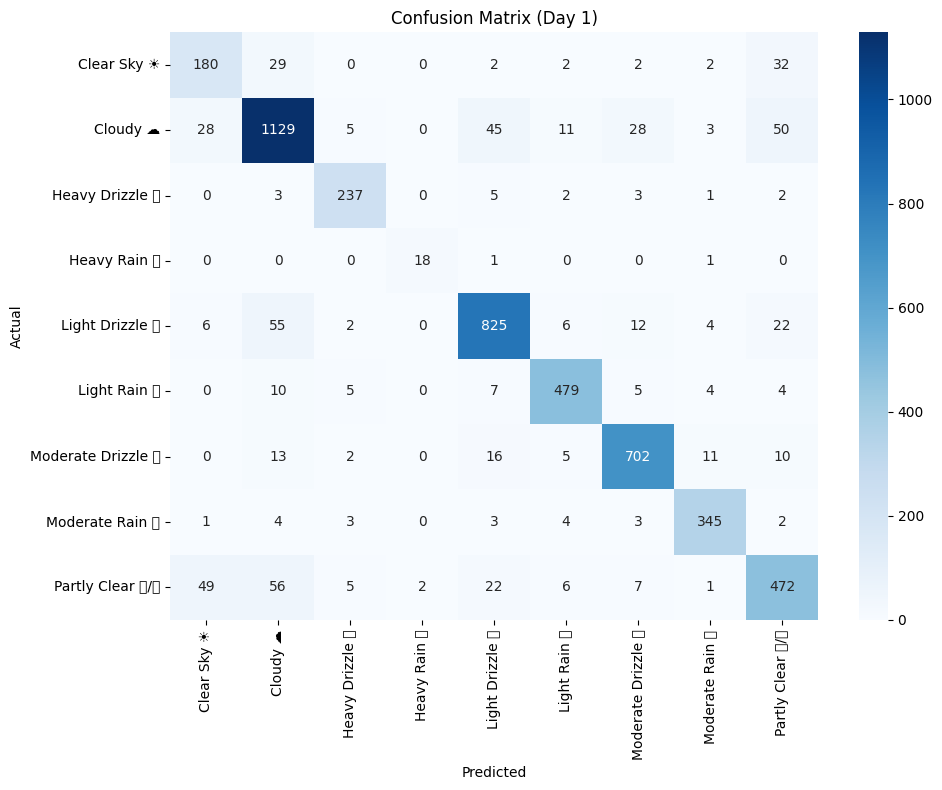


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧  : P=0.921, R=0.925, F1=0.923, N=759.0
  ✅ Light Rain 🌦        : P=0.930, R=0.932, F1=0.931, N=514.0
  ✅ Moderate Rain 🌧     : P=0.927, R=0.945, F1=0.936, N=365.0
  ✅ Heavy Drizzle 🌧     : P=0.915, R=0.937, F1=0.926, N=253.0
  ✅ Heavy Rain 🌧        : P=0.900, R=0.900, F1=0.900, N=20.0

  📊 MINORITY AVERAGES:
     Precision: 0.9188
     Recall: 0.9278
     F1-Score: 0.9232

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦     : P=0.891, R=0.885, F1=0.888, N=932.0
  ✅ Clear Sky ☀️        : P=0.682, R=0.723, F1=0.702, N=249.0

  📊 BALANCED AVERAGES:
     Precision: 0.7864
     Recall: 0.8040
     F1-Score: 0.7949

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️           : P=0.869, R=0.869, F1=0.869, N=1299.0
  ✅ Partly Clear 🌤/⛅    : P=0.795, R=0.761, F1=0.778, N=620.0

  📊 MAJORITY AVERAGES:
     Precision: 0.8319
 

In [8]:
def run_sliding_window_weather_forecasting(df, use_augmentation=True, use_hypertuning=True, max_trials=20):
    
    print("🌤️  SLIDING WINDOW + REBALANCING Weather Forecasting")
    if use_hypertuning:
        print("🔧  WITH HYPERPARAMETER TUNING")
    print("=" * 60)
    
    # Initialize model
    model = ImprovedSlidingWindowModel(df, sequence_length=10, forecast_horizon=3)
    
    # Preprocess data
    model.preprocess_data(target_col='weather_condition')
    
    # Train model with optional hyperparameter tuning
    acc, daily_accs, history, y_true, y_pred = model.train_improved_model(
        use_augmentation=use_augmentation,
        use_hypertuning=use_hypertuning,
        max_trials=max_trials
    )
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"Overall Accuracy: {acc:.4f}")
    print(f"Average Daily Accuracy: {np.mean(daily_accs):.4f}")
    print(f"Best Day Accuracy: {max(daily_accs):.4f}")
    
    if use_hypertuning and model.best_hps:
        print(f"\n🏆 BEST HYPERPARAMETERS USED:")
        print(f"Learning Rate: {model.best_hps.get('learning_rate'):.6f}")
        print(f"LSTM Architecture: {model.best_hps.get('lstm1_units')}-{model.best_hps.get('lstm2_units')}-{model.best_hps.get('lstm3_units')}")
        print(f"Dense Architecture: {model.best_hps.get('dense1_units')}-{model.best_hps.get('dense2_units')}-{model.best_hps.get('dense3_units')}")
        print(f"Dropout Rate: {model.best_hps.get('dropout_rate'):.3f}")
        print(f"Focal Loss: α={model.best_hps.get('focal_alpha'):.3f}, γ={model.best_hps.get('focal_gamma'):.1f}")
    
    return model, acc, daily_accs, y_true, y_pred, history

# Usage Examples:

# 1. Run with hyperparameter tuning (default)
best_model, acc, daily_accs, y_true, y_pred, history = run_sliding_window_weather_forecasting(
         df, use_hypertuning=True, max_trials=10
)


**c. Make predictions**


🔮 Making 3-day weather forecast...
----------------------------------------
📅 3-Day Weather Forecast:
  Thursday   (2025-05-01): Partly Clear 🌤/⛅ (confidence: 0.204) (uncertainty: 0.265)
  Friday     (2025-05-02): Cloudy ☁️ (confidence: 0.200) (uncertainty: 0.296)
  Saturday   (2025-05-03): Cloudy ☁️ (confidence: 0.215) (uncertainty: 0.341)


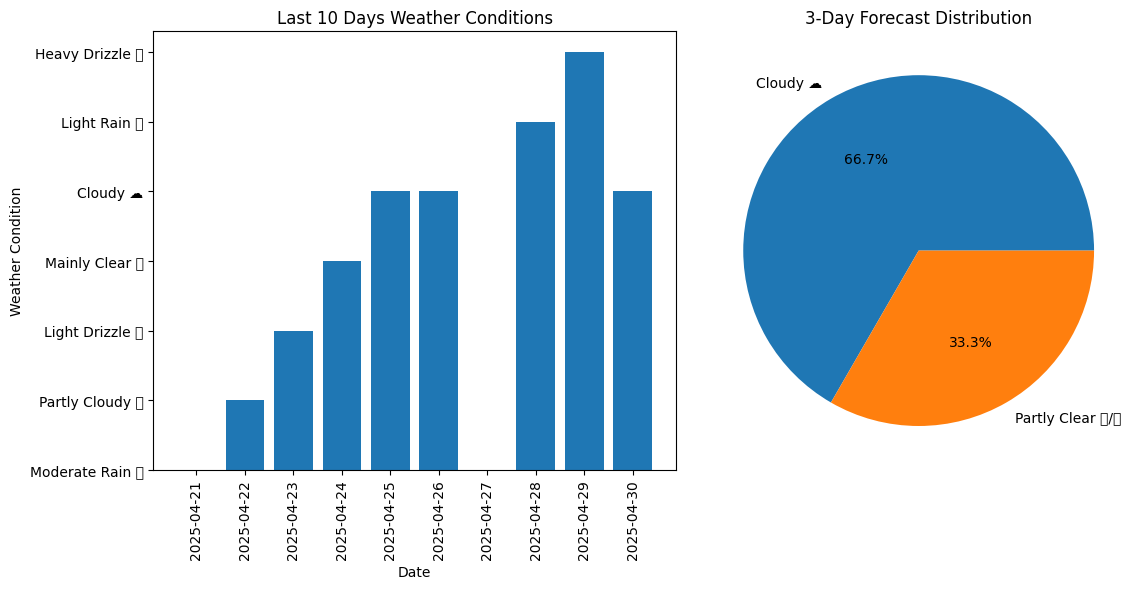

In [9]:
def make_predictions_and_visualize(model, df):
    
    import matplotlib.pyplot as plt
    from datetime import timedelta

    
    print("\n🔮 Making 3-day weather forecast...")
    print("-" * 40)
    
    # Use the last 30 days of data for prediction
    feature_cols = [col for col in df.columns if col not in ['date', 'weather_condition', 'weather_condition_encoded']]
    recent_data = df[feature_cols].tail(30).values
    
    try:
        # Unpack the tuple returned by predict_next_week
        predicted_conditions, confidence_scores, uncertainties  = model.predict_future(recent_data)
        
        print("📅 3-Day Weather Forecast:")
        # Get last date in the dataset and generate next 3 dates
        last_date = pd.to_datetime(df['date']).max()
        next_3_dates = [last_date + timedelta(days=i+1) for i in range(3)]
        days_and_dates = [(d.strftime('%A'), d.strftime('%Y-%m-%d')) for d in next_3_dates]

        # Now iterate over individual predictions with their confidence scores
        for (day, date), condition, confidence, uncertainty in zip(days_and_dates, predicted_conditions, confidence_scores, uncertainties):
            print(f"  {day:10} ({date}): {condition} (confidence: {confidence:.3f}) (uncertainty: {uncertainty:.3f})")
        
        # Create a simple visualization
        plt.figure(figsize=(12, 6))
    
        # Show recent actual labels with corresponding dates (last 10 days)
        recent_df = df[['date', 'weather_condition']].tail(10)
        recent_df['date'] = pd.to_datetime(recent_df['date'])

        plt.subplot(1, 2, 1)
        plt.bar(recent_df['date'].dt.strftime('%Y-%m-%d'), recent_df['weather_condition'].astype(str))
        plt.xticks(rotation=90)
        plt.title('Last 10 Days Weather Conditions')
        plt.xlabel('Date')
        plt.ylabel('Weather Condition')
        plt.tight_layout()

        plt.subplot(1, 2, 2)
        # Use predicted_conditions instead of next_week_forecast
        forecast_counts = pd.Series(predicted_conditions).value_counts()
        plt.pie(forecast_counts.values, labels=forecast_counts.index, autopct='%1.1f%%')
        plt.title('3-Day Forecast Distribution')
        
        plt.tight_layout()
        plt.show()
        
        return predicted_conditions, confidence_scores, uncertainties
        
    except Exception as e:
        print(f"❌ Prediction error: {e}")
        return None, None

predictions, confidences, uncertainties = make_predictions_and_visualize(best_model, df)

**d. Evaluate results**


IMPROVED SLIDING WINDOW + REBALANCING RESULTS (DEFAULT)
Overall Test Accuracy: 0.8724
Day 1 accuracy: 0.8755
Day 2 accuracy: 0.8787
Day 3 accuracy: 0.8631

Detailed Classification Report (Day 1):
----------------------------------------------------------------------
                    precision    recall  f1-score   support

      Clear Sky ☀️       0.68      0.72      0.70       249
         Cloudy ☁️       0.87      0.87      0.87      1299
   Heavy Drizzle 🌧       0.92      0.94      0.93       253
      Heavy Rain 🌧       0.90      0.90      0.90        20
   Light Drizzle 🌦       0.89      0.89      0.89       932
      Light Rain 🌦       0.93      0.93      0.93       514
Moderate Drizzle 🌧       0.92      0.92      0.92       759
   Moderate Rain 🌧       0.93      0.95      0.94       365
  Partly Clear 🌤/⛅       0.79      0.76      0.78       620

          accuracy                           0.88      5011
         macro avg       0.87      0.88      0.87      5011
      weig

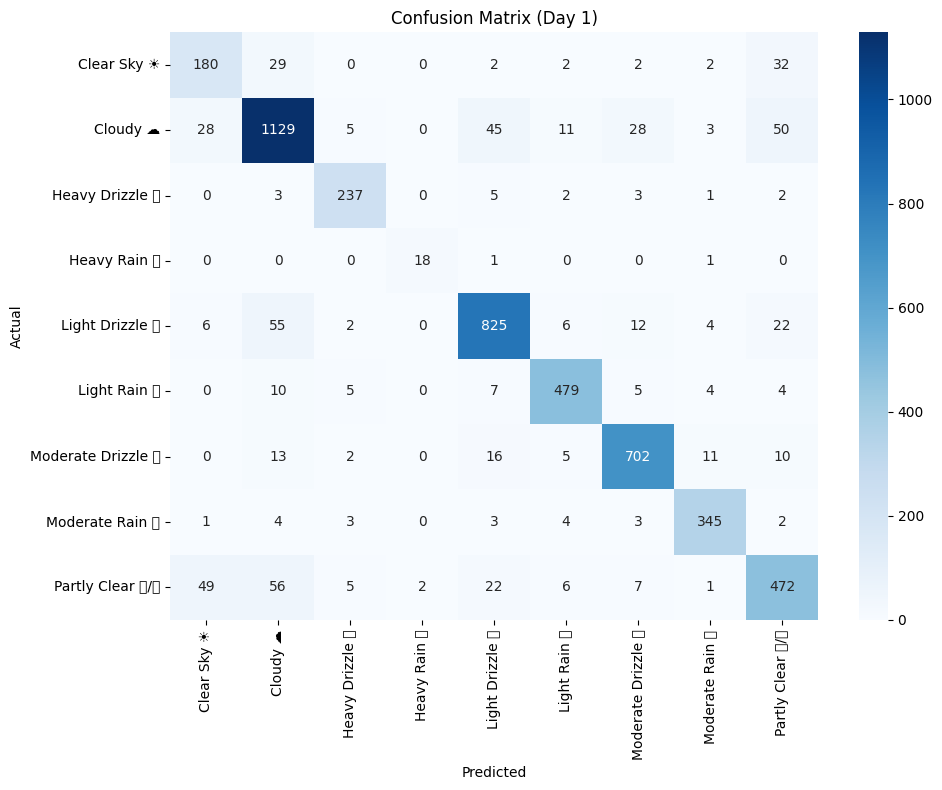


🎯 CLASS-TIER PERFORMANCE ANALYSIS:

MINORITY CLASSES:
----------------------------------------
  ✅ Moderate Drizzle 🌧  : P=0.921, R=0.925, F1=0.923, N=759.0
  ✅ Light Rain 🌦        : P=0.930, R=0.932, F1=0.931, N=514.0
  ✅ Moderate Rain 🌧     : P=0.927, R=0.945, F1=0.936, N=365.0
  ✅ Heavy Drizzle 🌧     : P=0.915, R=0.937, F1=0.926, N=253.0
  ✅ Heavy Rain 🌧        : P=0.900, R=0.900, F1=0.900, N=20.0

  📊 MINORITY AVERAGES:
     Precision: 0.9188
     Recall: 0.9278
     F1-Score: 0.9232

BALANCED CLASSES:
----------------------------------------
  ✅ Light Drizzle 🌦     : P=0.891, R=0.885, F1=0.888, N=932.0
  ✅ Clear Sky ☀️        : P=0.682, R=0.723, F1=0.702, N=249.0

  📊 BALANCED AVERAGES:
     Precision: 0.7864
     Recall: 0.8040
     F1-Score: 0.7949

MAJORITY CLASSES:
----------------------------------------
  ✅ Cloudy ☁️           : P=0.869, R=0.869, F1=0.869, N=1299.0
  ✅ Partly Clear 🌤/⛅    : P=0.795, R=0.761, F1=0.778, N=620.0

  📊 MAJORITY AVERAGES:
     Precision: 0.8319
 

In [10]:

overall_acc, daily_accuracies, history, y_true, y_pred = best_model.evaluate_improved_results(y_true, y_pred, history)


**e. Show predictions**

In [11]:
def show_weather_predictions(model, y_true, y_pred, num_samples=5):
    
    
    print("🌤️  WEATHER CONDITION PREDICTIONS")
    print("=" * 60)
    
    sample_size = min(num_samples, len(y_true))
    
    for i in range(sample_size):
        # Convert numeric predictions back to weather condition names
        actual_conditions = model.label_encoder.inverse_transform(y_true[i])
        pred_conditions = model.label_encoder.inverse_transform(y_pred[i])
        
        print(f"\n📅 Test Sequence {i+1}:")
        print("-" * 40)
        
        # Create a nice table format
        print(f"{'Day':>5} | {'Actual Weather':^20} | {'Predicted Weather':^20} | {'Match':^6}")
        print("-" * 65)
        
        matches = 0
        for day in range(model.forecast_horizon):
            actual = actual_conditions[day]
            predicted = pred_conditions[day]
            match = "✅" if actual == predicted else "❌"
            if actual == predicted:
                matches += 1
                
            print(f"{day+1:>5} | {actual:^20} | {predicted:^20} | {match:^6}")
        
        accuracy = matches / model.forecast_horizon
        print("-" * 65)
        print(f"Sequence Accuracy: {matches}/{model.forecast_horizon} ({accuracy:.1%})")
        
    # Overall statistics
    print(f"\n📊 OVERALL STATISTICS:")
    print("=" * 40)
    
    total_predictions = y_true.size
    correct_predictions = np.sum(y_true == y_pred)
    overall_accuracy = correct_predictions / total_predictions
    
    print(f"Total Predictions: {total_predictions:,}")
    print(f"Correct Predictions: {correct_predictions:,}")
    print(f"Overall Accuracy: {overall_accuracy:.1%}")
    
    # Per-day accuracy
    print(f"\n📈 DAILY ACCURACY BREAKDOWN:")
    print("-" * 30)
    for day in range(model.forecast_horizon):
        day_correct = np.sum(y_true[:, day] == y_pred[:, day])
        day_total = len(y_true)
        day_accuracy = day_correct / day_total
        print(f"Day {day+1}: {day_accuracy:.1%} ({day_correct}/{day_total})")

# Usage:
show_weather_predictions(best_model, y_true, y_pred, num_samples=3)

🌤️  WEATHER CONDITION PREDICTIONS

📅 Test Sequence 1:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    2 |      Cloudy ☁️       |      Cloudy ☁️       |   ✅   
    3 |   Partly Clear 🌤/⛅   |      Cloudy ☁️       |   ❌   
-----------------------------------------------------------------
Sequence Accuracy: 2/3 (66.7%)

📅 Test Sequence 2:
----------------------------------------
  Day |    Actual Weather    |  Predicted Weather   | Match 
-----------------------------------------------------------------
    1 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    2 |   Moderate Rain 🌧    |   Moderate Rain 🌧    |   ✅   
    3 |   Light Drizzle 🌦    |   Light Drizzle 🌦    |   ✅   
-----------------------------------------------------------------
Sequence Accuracy: 3/3 (100.0%)

📅 Test Sequence 3:
---------

**f. Save the model**

In [12]:
import os
import pickle
import joblib
from datetime import datetime
import json
import dill

def save_lstm_model(model, model_name="BEST LSTM Model", save_dir="saved_models"):
    
    # Create save directory if it doesn't exist
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    
    # Create a timestamp for uniqueness
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_folder = f"{save_dir}/{model_name.replace(' ', '_')}_{timestamp}"
    os.makedirs(model_folder, exist_ok=True)
    
    print(f"💾 Saving '{model_name}' to: {model_folder}")
    print("=" * 60)
    
    try:
        # 1. Save the Keras model 
        model_path = f"{model_folder}/keras_model.keras"
        model.model.save(model_path)
        print(f"✅ Keras model saved: keras_model.keras")
        
        # 2. Save the label encoder
        encoder_path = f"{model_folder}/label_encoder.pkl"
        with open(encoder_path, 'wb') as f:
            pickle.dump(model.label_encoder, f)
        print(f"✅ Label encoder saved: label_encoder.pkl")
        
        # 3. Save the scaler_X (if it exists)
        if hasattr(model, 'scaler_X') and model.scaler_X is not None:
            scaler_path = f"{model_folder}/scaler.pkl"
            joblib.dump(model.scaler_X, scaler_path)
            print(f"✅ Scaler saved: scaler.pkl")
        
        # 4. Save model configuration and metadata
        model_config = {
            'model_name': model_name,
            'sequence_length': model.sequence_length,
            'forecast_horizon': model.forecast_horizon,
            'feature_columns': getattr(model, 'feature_cols', []),
            'target_column': getattr(model, 'target_col', 'weather_condition'),
            'num_classes': len(model.label_encoder.classes_),
            'class_names': model.label_encoder.classes_.tolist(),
            'minority_classes': getattr(model, 'minority_classes', []),
            'timestamp': timestamp,
            'model_type': 'ImprovedSlidingWindowModel',
            'framework': 'TensorFlow/Keras'
        }
        
        config_path = f"{model_folder}/model_config.json"
        with open(config_path, 'w') as f:
            json.dump(model_config, f, indent=4)
        print(f"✅ Model configuration saved: model_config.json")
        
        # 5. Save essential attributes
        essential_attributes = {}
        safe_attributes = [
            'sequence_length', 'forecast_horizon', 'feature_cols',
            'target_col', 'minority_classes', 'best_hps', 'is_trained'
        ]
        
        for attr in safe_attributes:
            if hasattr(model, attr):
                try:
                    pickle.dumps(getattr(model, attr))  # test if picklable
                    essential_attributes[attr] = getattr(model, attr)
                except Exception as e:
                    print(f"⚠️  Skipping unpicklable attribute '{attr}': {str(e)}")
        
        essential_model_path = f"{model_folder}/essential_attributes.pkl"
        try:
            with open(essential_model_path, 'wb') as f:
                pickle.dump(essential_attributes, f)
            print(f"✅ Essential attributes saved: essential_attributes.pkl")
        except Exception as e:
            print(f"⚠️  Regular pickle failed, trying with dill...")
            try:
                with open(essential_model_path, 'wb') as f:
                    dill.dump(essential_attributes, f)
                print(f"✅ Essential attributes saved with dill: essential_attributes.pkl")
            except Exception as e2:
                print(f"❌ Could not save model attributes: {str(e2)}")
        
        print(f"\n🎉 '{model_name}' successfully saved!")
        print(f"📁 Location: {model_folder}")
        print(f"📊 Model info: {len(model.label_encoder.classes_)} weather classes, {model.sequence_length}→{model.forecast_horizon} day forecast")
        
        return model_folder
        
    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")
        return None


def load_lstm_model(model_folder):
    try:
        print(f"📂 Loading model from: {model_folder}")
        
        # Load configuration
        config_path = os.path.join(model_folder, "model_config.json")
        with open(config_path, 'r') as f:
            config = json.load(f)
        
        print(f"🔄 Loading '{config['model_name']}'...")

        # Load Keras model
        from tensorflow.keras.models import load_model
        keras_model = load_model(os.path.join(model_folder, "keras_model.keras"))
        print("✅ Keras model loaded")
        
        # Load label encoder
        with open(os.path.join(model_folder, "label_encoder.pkl"), 'rb') as f:
            label_encoder = pickle.load(f)
        print("✅ Label encoder loaded")
        
        # Load scaler_X if exists
        scaler_X = None
        scaler_path = os.path.join(model_folder, "scaler.pkl")
        if os.path.exists(scaler_path):
            scaler_X = joblib.load(scaler_path)
            print("✅ Scaler loaded")
        
        # Load essential attributes
        essential_attributes = {}
        essential_path = os.path.join(model_folder, "essential_attributes.pkl")
        if os.path.exists(essential_path):
            try:
                with open(essential_path, 'rb') as f:
                    essential_attributes = pickle.load(f)
                print("✅ Essential attributes loaded")
            except Exception:
                try:
                    with open(essential_path, 'rb') as f:
                        essential_attributes = dill.load(f)
                    print("✅ Essential attributes loaded with dill")
                except Exception as e2:
                    print(f"⚠️  Could not load essential attributes: {str(e2)}")
        
        print(f"\n🎉 Model components loaded successfully!")
        print(f"💡 Reconstruct your model class and assign these components.")
        
        return {
            'keras_model': keras_model,
            'label_encoder': label_encoder,
            'scaler_X': scaler_X,
            'config': config,
            'essential_attributes': essential_attributes
        }
        
    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        return None


model_folder = save_lstm_model(best_model, "BestWeatherModel")

💾 Saving 'BestWeatherModel' to: saved_models/BestWeatherModel_20250707_043444
✅ Keras model saved: keras_model.keras
✅ Label encoder saved: label_encoder.pkl
✅ Scaler saved: scaler.pkl
✅ Model configuration saved: model_config.json
✅ Essential attributes saved: essential_attributes.pkl

🎉 'BestWeatherModel' successfully saved!
📁 Location: saved_models/BestWeatherModel_20250707_043444
📊 Model info: 9 weather classes, 10→3 day forecast


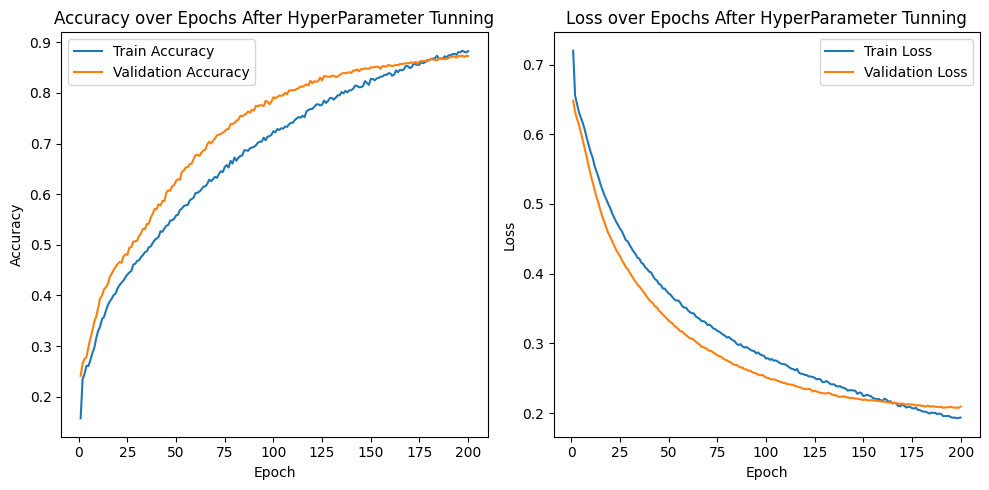

In [4]:
import re
import matplotlib.pyplot as plt

log = """
Epoch 1/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 112s 166ms/step - accuracy: 0.1573 - loss: 0.7199 - val_accuracy: 0.2414 - val_loss: 0.6482 - learning_rate: 1.0367e-04
Epoch 2/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.2346 - loss: 0.6554 - val_accuracy: 0.2652 - val_loss: 0.6324 - learning_rate: 1.0367e-04
Epoch 3/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.2450 - loss: 0.6433 - val_accuracy: 0.2747 - val_loss: 0.6219 - learning_rate: 1.0367e-04
Epoch 4/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2612 - loss: 0.6314 - val_accuracy: 0.2782 - val_loss: 0.6134 - learning_rate: 1.0367e-04
Epoch 5/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2607 - loss: 0.6238 - val_accuracy: 0.2982 - val_loss: 0.6024 - learning_rate: 1.0367e-04
Epoch 6/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2721 - loss: 0.6158 - val_accuracy: 0.3149 - val_loss: 0.5907 - learning_rate: 1.0367e-04
Epoch 7/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2858 - loss: 0.6061 - val_accuracy: 0.3298 - val_loss: 0.5787 - learning_rate: 1.0367e-04
Epoch 8/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.2962 - loss: 0.5946 - val_accuracy: 0.3477 - val_loss: 0.5669 - learning_rate: 1.0367e-04
Epoch 9/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.3159 - loss: 0.5844 - val_accuracy: 0.3585 - val_loss: 0.5539 - learning_rate: 1.0367e-04
Epoch 10/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3300 - loss: 0.5740 - val_accuracy: 0.3757 - val_loss: 0.5420 - learning_rate: 1.0367e-04
Epoch 11/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3388 - loss: 0.5667 - val_accuracy: 0.3940 - val_loss: 0.5314 - learning_rate: 1.0367e-04
Epoch 12/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.3533 - loss: 0.5547 - val_accuracy: 0.4000 - val_loss: 0.5206 - learning_rate: 1.0367e-04
Epoch 13/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3575 - loss: 0.5463 - val_accuracy: 0.4121 - val_loss: 0.5098 - learning_rate: 1.0367e-04
Epoch 14/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3700 - loss: 0.5384 - val_accuracy: 0.4162 - val_loss: 0.5015 - learning_rate: 1.0367e-04
Epoch 15/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3810 - loss: 0.5285 - val_accuracy: 0.4231 - val_loss: 0.4908 - learning_rate: 1.0367e-04
Epoch 16/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.3884 - loss: 0.5206 - val_accuracy: 0.4370 - val_loss: 0.4813 - learning_rate: 1.0367e-04
Epoch 17/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.3941 - loss: 0.5131 - val_accuracy: 0.4433 - val_loss: 0.4745 - learning_rate: 1.0367e-04
Epoch 18/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - accuracy: 0.4011 - loss: 0.5069 - val_accuracy: 0.4508 - val_loss: 0.4658 - learning_rate: 1.0367e-04
Epoch 19/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.4040 - loss: 0.5001 - val_accuracy: 0.4568 - val_loss: 0.4584 - learning_rate: 1.0367e-04
Epoch 20/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.4144 - loss: 0.4943 - val_accuracy: 0.4623 - val_loss: 0.4529 - learning_rate: 1.0367e-04
Epoch 21/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.4206 - loss: 0.4868 - val_accuracy: 0.4662 - val_loss: 0.4469 - learning_rate: 1.0367e-04
Epoch 22/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.4253 - loss: 0.4810 - val_accuracy: 0.4645 - val_loss: 0.4409 - learning_rate: 1.0367e-04
Epoch 23/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4296 - loss: 0.4749 - val_accuracy: 0.4772 - val_loss: 0.4345 - learning_rate: 1.0367e-04
Epoch 24/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4361 - loss: 0.4701 - val_accuracy: 0.4813 - val_loss: 0.4298 - learning_rate: 1.0367e-04
Epoch 25/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.4413 - loss: 0.4649 - val_accuracy: 0.4800 - val_loss: 0.4255 - learning_rate: 1.0367e-04
Epoch 26/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.4454 - loss: 0.4610 - val_accuracy: 0.4943 - val_loss: 0.4193 - learning_rate: 1.0367e-04
Epoch 27/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.4480 - loss: 0.4548 - val_accuracy: 0.4953 - val_loss: 0.4150 - learning_rate: 1.0367e-04
Epoch 28/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4609 - loss: 0.4484 - val_accuracy: 0.5064 - val_loss: 0.4098 - learning_rate: 1.0367e-04
Epoch 29/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.4625 - loss: 0.4463 - val_accuracy: 0.5067 - val_loss: 0.4063 - learning_rate: 1.0367e-04
Epoch 30/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.4680 - loss: 0.4411 - val_accuracy: 0.5084 - val_loss: 0.4016 - learning_rate: 1.0367e-04
Epoch 31/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4696 - loss: 0.4364 - val_accuracy: 0.5175 - val_loss: 0.3971 - learning_rate: 1.0367e-04
Epoch 32/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - accuracy: 0.4759 - loss: 0.4318 - val_accuracy: 0.5225 - val_loss: 0.3927 - learning_rate: 1.0367e-04
Epoch 33/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4797 - loss: 0.4283 - val_accuracy: 0.5314 - val_loss: 0.3885 - learning_rate: 1.0367e-04
Epoch 34/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.4853 - loss: 0.4231 - val_accuracy: 0.5310 - val_loss: 0.3848 - learning_rate: 1.0367e-04
Epoch 35/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.4872 - loss: 0.4215 - val_accuracy: 0.5410 - val_loss: 0.3817 - learning_rate: 1.0367e-04
Epoch 36/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.4952 - loss: 0.4159 - val_accuracy: 0.5417 - val_loss: 0.3780 - learning_rate: 1.0367e-04
Epoch 37/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.4968 - loss: 0.4138 - val_accuracy: 0.5536 - val_loss: 0.3744 - learning_rate: 1.0367e-04
Epoch 38/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5035 - loss: 0.4091 - val_accuracy: 0.5613 - val_loss: 0.3702 - learning_rate: 1.0367e-04
Epoch 39/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5093 - loss: 0.4067 - val_accuracy: 0.5706 - val_loss: 0.3662 - learning_rate: 1.0367e-04
Epoch 40/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5125 - loss: 0.4029 - val_accuracy: 0.5704 - val_loss: 0.3629 - learning_rate: 1.0367e-04
Epoch 41/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5153 - loss: 0.4018 - val_accuracy: 0.5800 - val_loss: 0.3595 - learning_rate: 1.0367e-04
Epoch 42/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5267 - loss: 0.3967 - val_accuracy: 0.5776 - val_loss: 0.3578 - learning_rate: 1.0367e-04
Epoch 43/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5257 - loss: 0.3921 - val_accuracy: 0.5864 - val_loss: 0.3530 - learning_rate: 1.0367e-04
Epoch 44/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5323 - loss: 0.3903 - val_accuracy: 0.5865 - val_loss: 0.3516 - learning_rate: 1.0367e-04
Epoch 45/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5376 - loss: 0.3855 - val_accuracy: 0.6029 - val_loss: 0.3469 - learning_rate: 1.0367e-04
Epoch 46/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.5392 - loss: 0.3839 - val_accuracy: 0.6075 - val_loss: 0.3447 - learning_rate: 1.0367e-04
Epoch 47/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.5480 - loss: 0.3788 - val_accuracy: 0.6067 - val_loss: 0.3415 - learning_rate: 1.0367e-04
Epoch 48/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5484 - loss: 0.3786 - val_accuracy: 0.6161 - val_loss: 0.3388 - learning_rate: 1.0367e-04
Epoch 49/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5514 - loss: 0.3751 - val_accuracy: 0.6177 - val_loss: 0.3359 - learning_rate: 1.0367e-04
Epoch 50/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5580 - loss: 0.3717 - val_accuracy: 0.6262 - val_loss: 0.3329 - learning_rate: 1.0367e-04
Epoch 51/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5593 - loss: 0.3699 - val_accuracy: 0.6294 - val_loss: 0.3302 - learning_rate: 1.0367e-04
Epoch 52/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.5690 - loss: 0.3662 - val_accuracy: 0.6284 - val_loss: 0.3288 - learning_rate: 1.0367e-04
Epoch 53/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.5716 - loss: 0.3631 - val_accuracy: 0.6440 - val_loss: 0.3248 - learning_rate: 1.0367e-04
Epoch 54/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.5765 - loss: 0.3612 - val_accuracy: 0.6470 - val_loss: 0.3230 - learning_rate: 1.0367e-04
Epoch 55/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.5781 - loss: 0.3616 - val_accuracy: 0.6528 - val_loss: 0.3206 - learning_rate: 1.0367e-04
Epoch 56/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.5788 - loss: 0.3583 - val_accuracy: 0.6531 - val_loss: 0.3173 - learning_rate: 1.0367e-04
Epoch 57/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.5876 - loss: 0.3535 - val_accuracy: 0.6593 - val_loss: 0.3172 - learning_rate: 1.0367e-04
Epoch 58/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.5904 - loss: 0.3512 - val_accuracy: 0.6603 - val_loss: 0.3137 - learning_rate: 1.0367e-04
Epoch 59/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5931 - loss: 0.3512 - val_accuracy: 0.6691 - val_loss: 0.3119 - learning_rate: 1.0367e-04
Epoch 60/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6023 - loss: 0.3472 - val_accuracy: 0.6773 - val_loss: 0.3094 - learning_rate: 1.0367e-04
Epoch 61/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.6028 - loss: 0.3447 - val_accuracy: 0.6778 - val_loss: 0.3071 - learning_rate: 1.0367e-04
Epoch 62/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6050 - loss: 0.3433 - val_accuracy: 0.6756 - val_loss: 0.3070 - learning_rate: 1.0367e-04
Epoch 63/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6094 - loss: 0.3429 - val_accuracy: 0.6819 - val_loss: 0.3049 - learning_rate: 1.0367e-04
Epoch 64/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6147 - loss: 0.3385 - val_accuracy: 0.6864 - val_loss: 0.3022 - learning_rate: 1.0367e-04
Epoch 65/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - accuracy: 0.6154 - loss: 0.3368 - val_accuracy: 0.6878 - val_loss: 0.3001 - learning_rate: 1.0367e-04
Epoch 66/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.6200 - loss: 0.3350 - val_accuracy: 0.6983 - val_loss: 0.2983 - learning_rate: 1.0367e-04
Epoch 67/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6286 - loss: 0.3316 - val_accuracy: 0.7038 - val_loss: 0.2950 - learning_rate: 1.0367e-04
Epoch 68/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.6257 - loss: 0.3319 - val_accuracy: 0.7000 - val_loss: 0.2946 - learning_rate: 1.0367e-04
Epoch 69/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.6297 - loss: 0.3301 - val_accuracy: 0.7058 - val_loss: 0.2928 - learning_rate: 1.0367e-04
Epoch 70/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6343 - loss: 0.3262 - val_accuracy: 0.7100 - val_loss: 0.2915 - learning_rate: 1.0367e-04
Epoch 71/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.6322 - loss: 0.3269 - val_accuracy: 0.7163 - val_loss: 0.2891 - learning_rate: 1.0367e-04
Epoch 72/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6397 - loss: 0.3245 - val_accuracy: 0.7175 - val_loss: 0.2891 - learning_rate: 1.0367e-04
Epoch 73/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.6452 - loss: 0.3212 - val_accuracy: 0.7191 - val_loss: 0.2866 - learning_rate: 1.0367e-04
Epoch 74/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6437 - loss: 0.3206 - val_accuracy: 0.7213 - val_loss: 0.2848 - learning_rate: 1.0367e-04
Epoch 75/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6534 - loss: 0.3179 - val_accuracy: 0.7242 - val_loss: 0.2830 - learning_rate: 1.0367e-04
Epoch 76/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6574 - loss: 0.3168 - val_accuracy: 0.7280 - val_loss: 0.2816 - learning_rate: 1.0367e-04
Epoch 77/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.6526 - loss: 0.3146 - val_accuracy: 0.7286 - val_loss: 0.2807 - learning_rate: 1.0367e-04
Epoch 78/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6657 - loss: 0.3125 - val_accuracy: 0.7387 - val_loss: 0.2783 - learning_rate: 1.0367e-04
Epoch 79/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6606 - loss: 0.3109 - val_accuracy: 0.7387 - val_loss: 0.2765 - learning_rate: 1.0367e-04
Epoch 80/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.6722 - loss: 0.3084 - val_accuracy: 0.7404 - val_loss: 0.2756 - learning_rate: 1.0367e-04
Epoch 81/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6662 - loss: 0.3091 - val_accuracy: 0.7449 - val_loss: 0.2737 - learning_rate: 1.0367e-04
Epoch 82/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6718 - loss: 0.3064 - val_accuracy: 0.7473 - val_loss: 0.2727 - learning_rate: 1.0367e-04
Epoch 83/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6753 - loss: 0.3044 - val_accuracy: 0.7547 - val_loss: 0.2703 - learning_rate: 1.0367e-04
Epoch 84/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6765 - loss: 0.3029 - val_accuracy: 0.7542 - val_loss: 0.2688 - learning_rate: 1.0367e-04
Epoch 85/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.6867 - loss: 0.2990 - val_accuracy: 0.7563 - val_loss: 0.2689 - learning_rate: 1.0367e-04
Epoch 86/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6866 - loss: 0.2977 - val_accuracy: 0.7587 - val_loss: 0.2670 - learning_rate: 1.0367e-04
Epoch 87/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6856 - loss: 0.2988 - val_accuracy: 0.7634 - val_loss: 0.2654 - learning_rate: 1.0367e-04
Epoch 88/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6906 - loss: 0.2954 - val_accuracy: 0.7610 - val_loss: 0.2653 - learning_rate: 1.0367e-04
Epoch 89/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6919 - loss: 0.2941 - val_accuracy: 0.7667 - val_loss: 0.2628 - learning_rate: 1.0367e-04
Epoch 90/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6934 - loss: 0.2946 - val_accuracy: 0.7651 - val_loss: 0.2626 - learning_rate: 1.0367e-04
Epoch 91/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.6964 - loss: 0.2930 - val_accuracy: 0.7742 - val_loss: 0.2607 - learning_rate: 1.0367e-04
Epoch 92/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7016 - loss: 0.2908 - val_accuracy: 0.7735 - val_loss: 0.2607 - learning_rate: 1.0367e-04
Epoch 93/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7037 - loss: 0.2894 - val_accuracy: 0.7757 - val_loss: 0.2585 - learning_rate: 1.0367e-04
Epoch 94/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7037 - loss: 0.2890 - val_accuracy: 0.7754 - val_loss: 0.2578 - learning_rate: 1.0367e-04
Epoch 95/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7115 - loss: 0.2856 - val_accuracy: 0.7738 - val_loss: 0.2568 - learning_rate: 1.0367e-04
Epoch 96/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7065 - loss: 0.2870 - val_accuracy: 0.7842 - val_loss: 0.2551 - learning_rate: 1.0367e-04
Epoch 97/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7137 - loss: 0.2840 - val_accuracy: 0.7825 - val_loss: 0.2541 - learning_rate: 1.0367e-04
Epoch 98/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7144 - loss: 0.2830 - val_accuracy: 0.7775 - val_loss: 0.2548 - learning_rate: 1.0367e-04
Epoch 99/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7174 - loss: 0.2820 - val_accuracy: 0.7828 - val_loss: 0.2530 - learning_rate: 1.0367e-04
Epoch 100/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.7243 - loss: 0.2782 - val_accuracy: 0.7915 - val_loss: 0.2508 - learning_rate: 1.0367e-04
Epoch 101/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.7222 - loss: 0.2787 - val_accuracy: 0.7895 - val_loss: 0.2505 - learning_rate: 1.0367e-04
Epoch 102/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.7287 - loss: 0.2764 - val_accuracy: 0.7918 - val_loss: 0.2491 - learning_rate: 1.0367e-04
Epoch 103/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7268 - loss: 0.2775 - val_accuracy: 0.7947 - val_loss: 0.2481 - learning_rate: 1.0367e-04
Epoch 104/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7302 - loss: 0.2751 - val_accuracy: 0.7944 - val_loss: 0.2483 - learning_rate: 1.0367e-04
Epoch 105/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7294 - loss: 0.2756 - val_accuracy: 0.7950 - val_loss: 0.2477 - learning_rate: 1.0367e-04
Epoch 106/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7336 - loss: 0.2741 - val_accuracy: 0.8002 - val_loss: 0.2462 - learning_rate: 1.0367e-04
Epoch 107/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7329 - loss: 0.2721 - val_accuracy: 0.7974 - val_loss: 0.2453 - learning_rate: 1.0367e-04
Epoch 108/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7379 - loss: 0.2706 - val_accuracy: 0.8047 - val_loss: 0.2443 - learning_rate: 1.0367e-04
Epoch 109/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7409 - loss: 0.2702 - val_accuracy: 0.8051 - val_loss: 0.2432 - learning_rate: 1.0367e-04
Epoch 110/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7413 - loss: 0.2697 - val_accuracy: 0.8054 - val_loss: 0.2429 - learning_rate: 1.0367e-04
Epoch 111/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7464 - loss: 0.2679 - val_accuracy: 0.8053 - val_loss: 0.2414 - learning_rate: 1.0367e-04
Epoch 112/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7495 - loss: 0.2656 - val_accuracy: 0.8078 - val_loss: 0.2412 - learning_rate: 1.0367e-04
Epoch 113/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7523 - loss: 0.2638 - val_accuracy: 0.8094 - val_loss: 0.2407 - learning_rate: 1.0367e-04
Epoch 114/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7509 - loss: 0.2631 - val_accuracy: 0.8129 - val_loss: 0.2405 - learning_rate: 1.0367e-04
Epoch 115/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7550 - loss: 0.2612 - val_accuracy: 0.8120 - val_loss: 0.2387 - learning_rate: 1.0367e-04
Epoch 116/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.7521 - loss: 0.2633 - val_accuracy: 0.8146 - val_loss: 0.2381 - learning_rate: 1.0367e-04
Epoch 117/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7636 - loss: 0.2579 - val_accuracy: 0.8169 - val_loss: 0.2371 - learning_rate: 1.0367e-04
Epoch 118/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7664 - loss: 0.2564 - val_accuracy: 0.8147 - val_loss: 0.2366 - learning_rate: 1.0367e-04
Epoch 119/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7680 - loss: 0.2562 - val_accuracy: 0.8239 - val_loss: 0.2350 - learning_rate: 1.0367e-04
Epoch 120/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7685 - loss: 0.2546 - val_accuracy: 0.8189 - val_loss: 0.2344 - learning_rate: 1.0367e-04
Epoch 121/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7724 - loss: 0.2544 - val_accuracy: 0.8231 - val_loss: 0.2342 - learning_rate: 1.0367e-04
Epoch 122/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7771 - loss: 0.2525 - val_accuracy: 0.8220 - val_loss: 0.2347 - learning_rate: 1.0367e-04
Epoch 123/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7776 - loss: 0.2525 - val_accuracy: 0.8235 - val_loss: 0.2338 - learning_rate: 1.0367e-04
Epoch 124/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7753 - loss: 0.2517 - val_accuracy: 0.8303 - val_loss: 0.2308 - learning_rate: 1.0367e-04
Epoch 125/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7767 - loss: 0.2507 - val_accuracy: 0.8245 - val_loss: 0.2321 - learning_rate: 1.0367e-04
Epoch 126/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.7849 - loss: 0.2484 - val_accuracy: 0.8332 - val_loss: 0.2310 - learning_rate: 1.0367e-04
Epoch 127/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7802 - loss: 0.2488 - val_accuracy: 0.8327 - val_loss: 0.2299 - learning_rate: 1.0367e-04
Epoch 128/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7838 - loss: 0.2485 - val_accuracy: 0.8319 - val_loss: 0.2289 - learning_rate: 1.0367e-04
Epoch 129/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7896 - loss: 0.2445 - val_accuracy: 0.8317 - val_loss: 0.2285 - learning_rate: 1.0367e-04
Epoch 130/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7902 - loss: 0.2443 - val_accuracy: 0.8337 - val_loss: 0.2283 - learning_rate: 1.0367e-04
Epoch 131/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7866 - loss: 0.2459 - val_accuracy: 0.8341 - val_loss: 0.2279 - learning_rate: 1.0367e-04
Epoch 132/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7906 - loss: 0.2443 - val_accuracy: 0.8314 - val_loss: 0.2292 - learning_rate: 1.0367e-04
Epoch 133/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7951 - loss: 0.2418 - val_accuracy: 0.8321 - val_loss: 0.2281 - learning_rate: 1.0367e-04
Epoch 134/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.7952 - loss: 0.2410 - val_accuracy: 0.8353 - val_loss: 0.2262 - learning_rate: 1.0367e-04
Epoch 135/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.8015 - loss: 0.2413 - val_accuracy: 0.8379 - val_loss: 0.2257 - learning_rate: 1.0367e-04
Epoch 136/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7991 - loss: 0.2388 - val_accuracy: 0.8397 - val_loss: 0.2254 - learning_rate: 1.0367e-04
Epoch 137/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8042 - loss: 0.2381 - val_accuracy: 0.8387 - val_loss: 0.2237 - learning_rate: 1.0367e-04
Epoch 138/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8010 - loss: 0.2386 - val_accuracy: 0.8402 - val_loss: 0.2233 - learning_rate: 1.0367e-04
Epoch 139/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8051 - loss: 0.2368 - val_accuracy: 0.8407 - val_loss: 0.2233 - learning_rate: 1.0367e-04
Epoch 140/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.8053 - loss: 0.2360 - val_accuracy: 0.8393 - val_loss: 0.2242 - learning_rate: 1.0367e-04
Epoch 141/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8084 - loss: 0.2349 - val_accuracy: 0.8442 - val_loss: 0.2228 - learning_rate: 1.0367e-04
Epoch 142/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8146 - loss: 0.2321 - val_accuracy: 0.8443 - val_loss: 0.2225 - learning_rate: 1.0367e-04
Epoch 143/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8137 - loss: 0.2329 - val_accuracy: 0.8464 - val_loss: 0.2217 - learning_rate: 1.0367e-04
Epoch 144/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8112 - loss: 0.2326 - val_accuracy: 0.8426 - val_loss: 0.2214 - learning_rate: 1.0367e-04
Epoch 145/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8113 - loss: 0.2325 - val_accuracy: 0.8471 - val_loss: 0.2215 - learning_rate: 1.0367e-04
Epoch 146/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8134 - loss: 0.2317 - val_accuracy: 0.8467 - val_loss: 0.2206 - learning_rate: 1.0367e-04
Epoch 147/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8231 - loss: 0.2275 - val_accuracy: 0.8486 - val_loss: 0.2206 - learning_rate: 1.0367e-04
Epoch 148/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8197 - loss: 0.2295 - val_accuracy: 0.8479 - val_loss: 0.2202 - learning_rate: 1.0367e-04
Epoch 149/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8158 - loss: 0.2288 - val_accuracy: 0.8474 - val_loss: 0.2194 - learning_rate: 1.0367e-04
Epoch 150/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8274 - loss: 0.2245 - val_accuracy: 0.8505 - val_loss: 0.2188 - learning_rate: 1.0367e-04
Epoch 151/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8276 - loss: 0.2251 - val_accuracy: 0.8502 - val_loss: 0.2195 - learning_rate: 1.0367e-04
Epoch 152/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8248 - loss: 0.2263 - val_accuracy: 0.8513 - val_loss: 0.2184 - learning_rate: 1.0367e-04
Epoch 153/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.8284 - loss: 0.2249 - val_accuracy: 0.8515 - val_loss: 0.2181 - learning_rate: 1.0367e-04
Epoch 154/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8295 - loss: 0.2241 - val_accuracy: 0.8517 - val_loss: 0.2184 - learning_rate: 1.0367e-04
Epoch 155/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.8321 - loss: 0.2214 - val_accuracy: 0.8475 - val_loss: 0.2182 - learning_rate: 1.0367e-04
Epoch 156/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.8323 - loss: 0.2206 - val_accuracy: 0.8530 - val_loss: 0.2176 - learning_rate: 1.0367e-04
Epoch 157/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8355 - loss: 0.2202 - val_accuracy: 0.8524 - val_loss: 0.2179 - learning_rate: 1.0367e-04
Epoch 158/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8355 - loss: 0.2202 - val_accuracy: 0.8517 - val_loss: 0.2170 - learning_rate: 1.0367e-04
Epoch 159/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8386 - loss: 0.2181 - val_accuracy: 0.8551 - val_loss: 0.2167 - learning_rate: 1.0367e-04
Epoch 160/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8387 - loss: 0.2178 - val_accuracy: 0.8539 - val_loss: 0.2164 - learning_rate: 1.0367e-04
Epoch 161/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8339 - loss: 0.2207 - val_accuracy: 0.8531 - val_loss: 0.2164 - learning_rate: 1.0367e-04
Epoch 162/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8362 - loss: 0.2190 - val_accuracy: 0.8540 - val_loss: 0.2156 - learning_rate: 1.0367e-04
Epoch 163/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8445 - loss: 0.2162 - val_accuracy: 0.8553 - val_loss: 0.2152 - learning_rate: 1.0367e-04
Epoch 164/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8409 - loss: 0.2169 - val_accuracy: 0.8546 - val_loss: 0.2150 - learning_rate: 1.0367e-04
Epoch 165/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8456 - loss: 0.2138 - val_accuracy: 0.8570 - val_loss: 0.2140 - learning_rate: 1.0367e-04
Epoch 166/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8444 - loss: 0.2146 - val_accuracy: 0.8567 - val_loss: 0.2151 - learning_rate: 1.0367e-04
Epoch 167/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8465 - loss: 0.2136 - val_accuracy: 0.8580 - val_loss: 0.2140 - learning_rate: 1.0367e-04
Epoch 168/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8531 - loss: 0.2100 - val_accuracy: 0.8583 - val_loss: 0.2134 - learning_rate: 1.0367e-04
Epoch 169/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8529 - loss: 0.2097 - val_accuracy: 0.8584 - val_loss: 0.2135 - learning_rate: 1.0367e-04
Epoch 170/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8491 - loss: 0.2126 - val_accuracy: 0.8588 - val_loss: 0.2135 - learning_rate: 1.0367e-04
Epoch 171/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8507 - loss: 0.2107 - val_accuracy: 0.8605 - val_loss: 0.2129 - learning_rate: 1.0367e-04
Epoch 172/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8580 - loss: 0.2079 - val_accuracy: 0.8589 - val_loss: 0.2122 - learning_rate: 1.0367e-04
Epoch 173/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8564 - loss: 0.2090 - val_accuracy: 0.8612 - val_loss: 0.2127 - learning_rate: 1.0367e-04
Epoch 174/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8550 - loss: 0.2088 - val_accuracy: 0.8576 - val_loss: 0.2124 - learning_rate: 1.0367e-04
Epoch 175/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8559 - loss: 0.2072 - val_accuracy: 0.8618 - val_loss: 0.2121 - learning_rate: 1.0367e-04
Epoch 176/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8612 - loss: 0.2063 - val_accuracy: 0.8628 - val_loss: 0.2120 - learning_rate: 1.0367e-04
Epoch 177/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8587 - loss: 0.2077 - val_accuracy: 0.8628 - val_loss: 0.2110 - learning_rate: 1.0367e-04
Epoch 178/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8609 - loss: 0.2046 - val_accuracy: 0.8633 - val_loss: 0.2108 - learning_rate: 1.0367e-04
Epoch 179/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8646 - loss: 0.2043 - val_accuracy: 0.8619 - val_loss: 0.2115 - learning_rate: 1.0367e-04
Epoch 180/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8644 - loss: 0.2027 - val_accuracy: 0.8650 - val_loss: 0.2101 - learning_rate: 1.0367e-04
Epoch 181/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8674 - loss: 0.2021 - val_accuracy: 0.8667 - val_loss: 0.2099 - learning_rate: 1.0367e-04
Epoch 182/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8676 - loss: 0.2018 - val_accuracy: 0.8659 - val_loss: 0.2092 - learning_rate: 1.0367e-04
Epoch 183/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8686 - loss: 0.2007 - val_accuracy: 0.8649 - val_loss: 0.2105 - learning_rate: 1.0367e-04
Epoch 184/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8733 - loss: 0.1993 - val_accuracy: 0.8642 - val_loss: 0.2097 - learning_rate: 1.0367e-04
Epoch 185/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8674 - loss: 0.2006 - val_accuracy: 0.8677 - val_loss: 0.2095 - learning_rate: 1.0367e-04
Epoch 186/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8680 - loss: 0.2001 - val_accuracy: 0.8683 - val_loss: 0.2097 - learning_rate: 1.0367e-04
Epoch 187/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8673 - loss: 0.2003 - val_accuracy: 0.8673 - val_loss: 0.2090 - learning_rate: 1.0367e-04
Epoch 188/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8724 - loss: 0.1984 - val_accuracy: 0.8666 - val_loss: 0.2087 - learning_rate: 1.0367e-04
Epoch 189/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8701 - loss: 0.1992 - val_accuracy: 0.8674 - val_loss: 0.2085 - learning_rate: 1.0367e-04
Epoch 190/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8741 - loss: 0.1986 - val_accuracy: 0.8693 - val_loss: 0.2091 - learning_rate: 1.0367e-04
Epoch 191/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8748 - loss: 0.1956 - val_accuracy: 0.8703 - val_loss: 0.2076 - learning_rate: 1.0367e-04
Epoch 192/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8763 - loss: 0.1956 - val_accuracy: 0.8728 - val_loss: 0.2079 - learning_rate: 1.0367e-04
Epoch 193/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.8773 - loss: 0.1957 - val_accuracy: 0.8713 - val_loss: 0.2084 - learning_rate: 1.0367e-04
Epoch 194/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.8754 - loss: 0.1958 - val_accuracy: 0.8698 - val_loss: 0.2083 - learning_rate: 1.0367e-04
Epoch 195/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.8807 - loss: 0.1941 - val_accuracy: 0.8732 - val_loss: 0.2089 - learning_rate: 1.0367e-04
Epoch 196/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.8800 - loss: 0.1933 - val_accuracy: 0.8723 - val_loss: 0.2081 - learning_rate: 1.0367e-04
Epoch 197/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8833 - loss: 0.1936 - val_accuracy: 0.8737 - val_loss: 0.2078 - learning_rate: 1.0367e-04
Epoch 198/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8812 - loss: 0.1924 - val_accuracy: 0.8710 - val_loss: 0.2077 - learning_rate: 1.0367e-04
Epoch 199/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8800 - loss: 0.1931 - val_accuracy: 0.8733 - val_loss: 0.2074 - learning_rate: 1.0367e-04
Epoch 200/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8824 - loss: 0.1935 - val_accuracy: 0.8729 - val_loss: 0.2093 - learning_rate: 1.0367e-04 """

# Parse log
pattern = re.compile(r"Epoch (\d+)/\d+.*?accuracy: ([\d.]+) - loss: ([\d.]+) - val_accuracy: ([\d.]+) - val_loss: ([\d.]+)", re.DOTALL)
epochs, acc, val_acc, loss, val_loss = [], [], [], [], []

for match in pattern.finditer(log):
    epochs.append(int(match.group(1)))
    acc.append(float(match.group(2)))
    loss.append(float(match.group(3)))
    val_acc.append(float(match.group(4)))
    val_loss.append(float(match.group(5)))

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs After HyperParameter Tunning')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs After HyperParameter Tunning')
plt.legend()

plt.tight_layout()
plt.show()


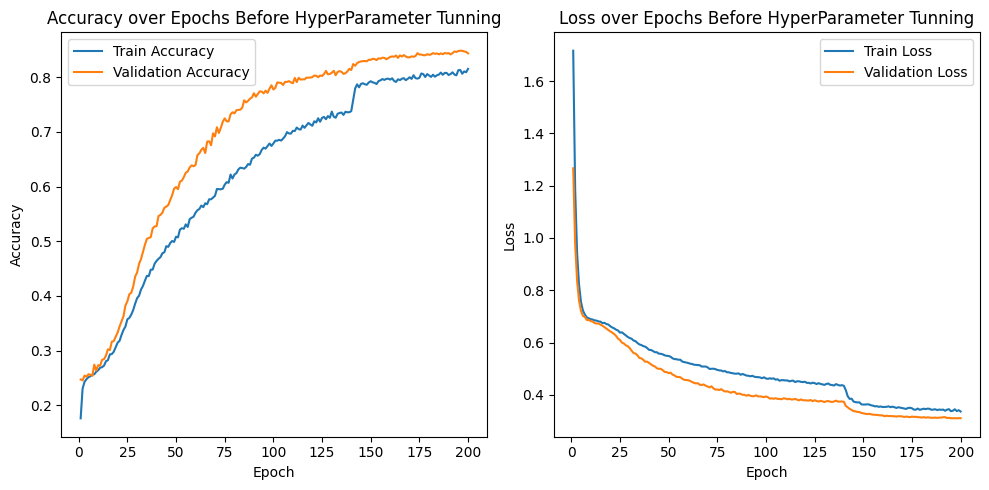

In [5]:
import re
import matplotlib.pyplot as plt

log = """ 
Epoch 1/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.1764 - loss: 1.7167 - val_accuracy: 0.2474 - val_loss: 1.2668 - learning_rate: 5.0000e-04
Epoch 2/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.2308 - loss: 1.1877 - val_accuracy: 0.2459 - val_loss: 0.9771 - learning_rate: 5.0000e-04
Epoch 3/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2431 - loss: 0.9412 - val_accuracy: 0.2546 - val_loss: 0.8355 - learning_rate: 5.0000e-04
Epoch 4/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2480 - loss: 0.8207 - val_accuracy: 0.2524 - val_loss: 0.7601 - learning_rate: 5.0000e-04
Epoch 5/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2515 - loss: 0.7548 - val_accuracy: 0.2571 - val_loss: 0.7206 - learning_rate: 5.0000e-04
Epoch 6/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2534 - loss: 0.7221 - val_accuracy: 0.2560 - val_loss: 0.7019 - learning_rate: 5.0000e-04
Epoch 7/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2564 - loss: 0.7068 - val_accuracy: 0.2540 - val_loss: 0.6972 - learning_rate: 5.0000e-04
Epoch 8/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2569 - loss: 0.6958 - val_accuracy: 0.2745 - val_loss: 0.6863 - learning_rate: 5.0000e-04
Epoch 9/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2615 - loss: 0.6928 - val_accuracy: 0.2639 - val_loss: 0.6861 - learning_rate: 5.0000e-04
Epoch 10/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2643 - loss: 0.6893 - val_accuracy: 0.2736 - val_loss: 0.6823 - learning_rate: 5.0000e-04
Epoch 11/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2689 - loss: 0.6879 - val_accuracy: 0.2724 - val_loss: 0.6801 - learning_rate: 5.0000e-04
Epoch 12/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2699 - loss: 0.6847 - val_accuracy: 0.2834 - val_loss: 0.6744 - learning_rate: 5.0000e-04
Epoch 13/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2727 - loss: 0.6838 - val_accuracy: 0.2846 - val_loss: 0.6725 - learning_rate: 5.0000e-04
Epoch 14/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2807 - loss: 0.6807 - val_accuracy: 0.2910 - val_loss: 0.6729 - learning_rate: 5.0000e-04
Epoch 15/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2827 - loss: 0.6798 - val_accuracy: 0.3026 - val_loss: 0.6683 - learning_rate: 5.0000e-04
Epoch 16/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.2932 - loss: 0.6744 - val_accuracy: 0.3012 - val_loss: 0.6645 - learning_rate: 5.0000e-04
Epoch 17/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.2939 - loss: 0.6754 - val_accuracy: 0.3165 - val_loss: 0.6593 - learning_rate: 5.0000e-04
Epoch 18/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.2981 - loss: 0.6708 - val_accuracy: 0.3176 - val_loss: 0.6536 - learning_rate: 5.0000e-04
Epoch 19/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3066 - loss: 0.6689 - val_accuracy: 0.3253 - val_loss: 0.6480 - learning_rate: 5.0000e-04
Epoch 20/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3147 - loss: 0.6625 - val_accuracy: 0.3334 - val_loss: 0.6430 - learning_rate: 5.0000e-04
Epoch 21/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.3181 - loss: 0.6577 - val_accuracy: 0.3443 - val_loss: 0.6376 - learning_rate: 5.0000e-04
Epoch 22/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3289 - loss: 0.6543 - val_accuracy: 0.3534 - val_loss: 0.6327 - learning_rate: 5.0000e-04
Epoch 23/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3379 - loss: 0.6492 - val_accuracy: 0.3630 - val_loss: 0.6254 - learning_rate: 5.0000e-04
Epoch 24/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3442 - loss: 0.6461 - val_accuracy: 0.3827 - val_loss: 0.6149 - learning_rate: 5.0000e-04
Epoch 25/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3574 - loss: 0.6378 - val_accuracy: 0.3902 - val_loss: 0.6097 - learning_rate: 5.0000e-04
Epoch 26/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.3599 - loss: 0.6391 - val_accuracy: 0.4032 - val_loss: 0.5997 - learning_rate: 5.0000e-04
Epoch 27/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.3660 - loss: 0.6331 - val_accuracy: 0.4059 - val_loss: 0.5964 - learning_rate: 5.0000e-04
Epoch 28/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.3744 - loss: 0.6275 - val_accuracy: 0.4172 - val_loss: 0.5893 - learning_rate: 5.0000e-04
Epoch 29/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3861 - loss: 0.6214 - val_accuracy: 0.4355 - val_loss: 0.5859 - learning_rate: 5.0000e-04
Epoch 30/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3960 - loss: 0.6172 - val_accuracy: 0.4429 - val_loss: 0.5785 - learning_rate: 5.0000e-04
Epoch 31/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4005 - loss: 0.6144 - val_accuracy: 0.4587 - val_loss: 0.5689 - learning_rate: 5.0000e-04
Epoch 32/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4118 - loss: 0.6076 - val_accuracy: 0.4675 - val_loss: 0.5595 - learning_rate: 5.0000e-04
Epoch 33/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4183 - loss: 0.6051 - val_accuracy: 0.4803 - val_loss: 0.5576 - learning_rate: 5.0000e-04
Epoch 34/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4279 - loss: 0.5981 - val_accuracy: 0.4933 - val_loss: 0.5508 - learning_rate: 5.0000e-04
Epoch 35/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4367 - loss: 0.5927 - val_accuracy: 0.5044 - val_loss: 0.5408 - learning_rate: 5.0000e-04
Epoch 36/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4365 - loss: 0.5903 - val_accuracy: 0.5060 - val_loss: 0.5394 - learning_rate: 5.0000e-04
Epoch 37/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4481 - loss: 0.5861 - val_accuracy: 0.5076 - val_loss: 0.5335 - learning_rate: 5.0000e-04
Epoch 38/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4483 - loss: 0.5841 - val_accuracy: 0.5235 - val_loss: 0.5262 - learning_rate: 5.0000e-04
Epoch 39/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4591 - loss: 0.5787 - val_accuracy: 0.5271 - val_loss: 0.5269 - learning_rate: 5.0000e-04
Epoch 40/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4642 - loss: 0.5717 - val_accuracy: 0.5277 - val_loss: 0.5214 - learning_rate: 5.0000e-04
Epoch 41/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4680 - loss: 0.5714 - val_accuracy: 0.5462 - val_loss: 0.5162 - learning_rate: 5.0000e-04
Epoch 42/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4711 - loss: 0.5672 - val_accuracy: 0.5482 - val_loss: 0.5111 - learning_rate: 5.0000e-04
Epoch 43/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.4782 - loss: 0.5629 - val_accuracy: 0.5524 - val_loss: 0.5081 - learning_rate: 5.0000e-04
Epoch 44/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4799 - loss: 0.5627 - val_accuracy: 0.5612 - val_loss: 0.5012 - learning_rate: 5.0000e-04
Epoch 45/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4911 - loss: 0.5572 - val_accuracy: 0.5635 - val_loss: 0.4992 - learning_rate: 5.0000e-04
Epoch 46/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4898 - loss: 0.5568 - val_accuracy: 0.5662 - val_loss: 0.4994 - learning_rate: 5.0000e-04
Epoch 47/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4967 - loss: 0.5547 - val_accuracy: 0.5755 - val_loss: 0.4938 - learning_rate: 5.0000e-04
Epoch 48/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5005 - loss: 0.5508 - val_accuracy: 0.5842 - val_loss: 0.4873 - learning_rate: 5.0000e-04
Epoch 49/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.4988 - loss: 0.5492 - val_accuracy: 0.5961 - val_loss: 0.4869 - learning_rate: 5.0000e-04
Epoch 50/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5083 - loss: 0.5484 - val_accuracy: 0.5991 - val_loss: 0.4826 - learning_rate: 5.0000e-04
Epoch 51/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5072 - loss: 0.5456 - val_accuracy: 0.5953 - val_loss: 0.4846 - learning_rate: 5.0000e-04
Epoch 52/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5213 - loss: 0.5397 - val_accuracy: 0.6089 - val_loss: 0.4773 - learning_rate: 5.0000e-04
Epoch 53/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5239 - loss: 0.5365 - val_accuracy: 0.6109 - val_loss: 0.4741 - learning_rate: 5.0000e-04
Epoch 54/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5229 - loss: 0.5361 - val_accuracy: 0.6173 - val_loss: 0.4687 - learning_rate: 5.0000e-04
Epoch 55/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5309 - loss: 0.5341 - val_accuracy: 0.6252 - val_loss: 0.4681 - learning_rate: 5.0000e-04
Epoch 56/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5262 - loss: 0.5342 - val_accuracy: 0.6277 - val_loss: 0.4673 - learning_rate: 5.0000e-04
Epoch 57/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5405 - loss: 0.5272 - val_accuracy: 0.6349 - val_loss: 0.4615 - learning_rate: 5.0000e-04
Epoch 58/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5430 - loss: 0.5250 - val_accuracy: 0.6388 - val_loss: 0.4573 - learning_rate: 5.0000e-04
Epoch 59/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5450 - loss: 0.5236 - val_accuracy: 0.6371 - val_loss: 0.4566 - learning_rate: 5.0000e-04
Epoch 60/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5522 - loss: 0.5219 - val_accuracy: 0.6394 - val_loss: 0.4557 - learning_rate: 5.0000e-04
Epoch 61/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5568 - loss: 0.5191 - val_accuracy: 0.6576 - val_loss: 0.4533 - learning_rate: 5.0000e-04
Epoch 62/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5591 - loss: 0.5181 - val_accuracy: 0.6608 - val_loss: 0.4491 - learning_rate: 5.0000e-04
Epoch 63/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5653 - loss: 0.5151 - val_accuracy: 0.6673 - val_loss: 0.4457 - learning_rate: 5.0000e-04
Epoch 64/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5624 - loss: 0.5143 - val_accuracy: 0.6707 - val_loss: 0.4433 - learning_rate: 5.0000e-04
Epoch 65/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5695 - loss: 0.5135 - val_accuracy: 0.6613 - val_loss: 0.4445 - learning_rate: 5.0000e-04
Epoch 66/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5678 - loss: 0.5130 - val_accuracy: 0.6823 - val_loss: 0.4382 - learning_rate: 5.0000e-04
Epoch 67/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5767 - loss: 0.5080 - val_accuracy: 0.6827 - val_loss: 0.4377 - learning_rate: 5.0000e-04
Epoch 68/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5767 - loss: 0.5080 - val_accuracy: 0.6756 - val_loss: 0.4395 - learning_rate: 5.0000e-04
Epoch 69/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.5798 - loss: 0.5081 - val_accuracy: 0.6973 - val_loss: 0.4348 - learning_rate: 5.0000e-04
Epoch 70/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5831 - loss: 0.5052 - val_accuracy: 0.6916 - val_loss: 0.4318 - learning_rate: 5.0000e-04
Epoch 71/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5956 - loss: 0.4989 - val_accuracy: 0.7084 - val_loss: 0.4282 - learning_rate: 5.0000e-04
Epoch 72/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5953 - loss: 0.4993 - val_accuracy: 0.6979 - val_loss: 0.4323 - learning_rate: 5.0000e-04
Epoch 73/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5950 - loss: 0.4998 - val_accuracy: 0.7073 - val_loss: 0.4246 - learning_rate: 5.0000e-04
Epoch 74/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.5960 - loss: 0.4982 - val_accuracy: 0.7185 - val_loss: 0.4198 - learning_rate: 5.0000e-04
Epoch 75/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6035 - loss: 0.4951 - val_accuracy: 0.7246 - val_loss: 0.4202 - learning_rate: 5.0000e-04
Epoch 76/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6081 - loss: 0.4934 - val_accuracy: 0.7192 - val_loss: 0.4180 - learning_rate: 5.0000e-04
Epoch 77/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6069 - loss: 0.4928 - val_accuracy: 0.7191 - val_loss: 0.4216 - learning_rate: 5.0000e-04
Epoch 78/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6220 - loss: 0.4895 - val_accuracy: 0.7321 - val_loss: 0.4162 - learning_rate: 5.0000e-04
Epoch 79/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6147 - loss: 0.4908 - val_accuracy: 0.7358 - val_loss: 0.4126 - learning_rate: 5.0000e-04
Epoch 80/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.6219 - loss: 0.4861 - val_accuracy: 0.7338 - val_loss: 0.4133 - learning_rate: 5.0000e-04
Epoch 81/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6246 - loss: 0.4859 - val_accuracy: 0.7394 - val_loss: 0.4109 - learning_rate: 5.0000e-04
Epoch 82/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6312 - loss: 0.4835 - val_accuracy: 0.7402 - val_loss: 0.4076 - learning_rate: 5.0000e-04
Epoch 83/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6345 - loss: 0.4824 - val_accuracy: 0.7405 - val_loss: 0.4112 - learning_rate: 5.0000e-04
Epoch 84/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6339 - loss: 0.4807 - val_accuracy: 0.7440 - val_loss: 0.4108 - learning_rate: 5.0000e-04
Epoch 85/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6328 - loss: 0.4807 - val_accuracy: 0.7576 - val_loss: 0.4030 - learning_rate: 5.0000e-04
Epoch 86/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6358 - loss: 0.4818 - val_accuracy: 0.7538 - val_loss: 0.4047 - learning_rate: 5.0000e-04
Epoch 87/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6411 - loss: 0.4766 - val_accuracy: 0.7567 - val_loss: 0.4033 - learning_rate: 5.0000e-04
Epoch 88/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6399 - loss: 0.4795 - val_accuracy: 0.7606 - val_loss: 0.3998 - learning_rate: 5.0000e-04
Epoch 89/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6511 - loss: 0.4765 - val_accuracy: 0.7629 - val_loss: 0.3999 - learning_rate: 5.0000e-04
Epoch 90/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6528 - loss: 0.4735 - val_accuracy: 0.7705 - val_loss: 0.3961 - learning_rate: 5.0000e-04
Epoch 91/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6581 - loss: 0.4727 - val_accuracy: 0.7643 - val_loss: 0.3997 - learning_rate: 5.0000e-04
Epoch 92/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6564 - loss: 0.4707 - val_accuracy: 0.7693 - val_loss: 0.3960 - learning_rate: 5.0000e-04
Epoch 93/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6594 - loss: 0.4726 - val_accuracy: 0.7740 - val_loss: 0.3943 - learning_rate: 5.0000e-04
Epoch 94/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.6670 - loss: 0.4692 - val_accuracy: 0.7736 - val_loss: 0.3950 - learning_rate: 5.0000e-04
Epoch 95/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6711 - loss: 0.4676 - val_accuracy: 0.7704 - val_loss: 0.3978 - learning_rate: 5.0000e-04
Epoch 96/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6694 - loss: 0.4675 - val_accuracy: 0.7753 - val_loss: 0.3935 - learning_rate: 5.0000e-04
Epoch 97/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6740 - loss: 0.4663 - val_accuracy: 0.7713 - val_loss: 0.3941 - learning_rate: 5.0000e-04
Epoch 98/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6787 - loss: 0.4634 - val_accuracy: 0.7788 - val_loss: 0.3925 - learning_rate: 5.0000e-04
Epoch 99/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6743 - loss: 0.4668 - val_accuracy: 0.7851 - val_loss: 0.3910 - learning_rate: 5.0000e-04
Epoch 100/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.6788 - loss: 0.4623 - val_accuracy: 0.7774 - val_loss: 0.3935 - learning_rate: 5.0000e-04
Epoch 101/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.6839 - loss: 0.4609 - val_accuracy: 0.7806 - val_loss: 0.3906 - learning_rate: 5.0000e-04
Epoch 102/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6839 - loss: 0.4631 - val_accuracy: 0.7903 - val_loss: 0.3851 - learning_rate: 5.0000e-04
Epoch 103/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6854 - loss: 0.4613 - val_accuracy: 0.7898 - val_loss: 0.3865 - learning_rate: 5.0000e-04
Epoch 104/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6841 - loss: 0.4627 - val_accuracy: 0.7893 - val_loss: 0.3848 - learning_rate: 5.0000e-04
Epoch 105/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6878 - loss: 0.4577 - val_accuracy: 0.7857 - val_loss: 0.3867 - learning_rate: 5.0000e-04
Epoch 106/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6921 - loss: 0.4594 - val_accuracy: 0.7914 - val_loss: 0.3841 - learning_rate: 5.0000e-04
Epoch 107/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6995 - loss: 0.4538 - val_accuracy: 0.7913 - val_loss: 0.3843 - learning_rate: 5.0000e-04
Epoch 108/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6971 - loss: 0.4561 - val_accuracy: 0.7927 - val_loss: 0.3828 - learning_rate: 5.0000e-04
Epoch 109/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6968 - loss: 0.4558 - val_accuracy: 0.7905 - val_loss: 0.3864 - learning_rate: 5.0000e-04
Epoch 110/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7019 - loss: 0.4547 - val_accuracy: 0.7888 - val_loss: 0.3856 - learning_rate: 5.0000e-04
Epoch 111/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7015 - loss: 0.4551 - val_accuracy: 0.7986 - val_loss: 0.3828 - learning_rate: 5.0000e-04
Epoch 112/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7079 - loss: 0.4513 - val_accuracy: 0.7910 - val_loss: 0.3846 - learning_rate: 5.0000e-04
Epoch 113/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7049 - loss: 0.4532 - val_accuracy: 0.7988 - val_loss: 0.3821 - learning_rate: 5.0000e-04
Epoch 114/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7042 - loss: 0.4542 - val_accuracy: 0.7955 - val_loss: 0.3822 - learning_rate: 5.0000e-04
Epoch 115/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7114 - loss: 0.4486 - val_accuracy: 0.7960 - val_loss: 0.3841 - learning_rate: 5.0000e-04
Epoch 116/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7074 - loss: 0.4516 - val_accuracy: 0.7959 - val_loss: 0.3811 - learning_rate: 5.0000e-04
Epoch 117/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7120 - loss: 0.4516 - val_accuracy: 0.7990 - val_loss: 0.3785 - learning_rate: 5.0000e-04
Epoch 118/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7163 - loss: 0.4493 - val_accuracy: 0.7991 - val_loss: 0.3823 - learning_rate: 5.0000e-04
Epoch 119/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7135 - loss: 0.4485 - val_accuracy: 0.7992 - val_loss: 0.3789 - learning_rate: 5.0000e-04
Epoch 120/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7111 - loss: 0.4500 - val_accuracy: 0.8001 - val_loss: 0.3791 - learning_rate: 5.0000e-04
Epoch 121/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7193 - loss: 0.4455 - val_accuracy: 0.8029 - val_loss: 0.3780 - learning_rate: 5.0000e-04
Epoch 122/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7172 - loss: 0.4457 - val_accuracy: 0.8025 - val_loss: 0.3779 - learning_rate: 5.0000e-04
Epoch 123/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7249 - loss: 0.4432 - val_accuracy: 0.7999 - val_loss: 0.3799 - learning_rate: 5.0000e-04
Epoch 124/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7185 - loss: 0.4461 - val_accuracy: 0.8030 - val_loss: 0.3753 - learning_rate: 5.0000e-04
Epoch 125/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7256 - loss: 0.4446 - val_accuracy: 0.8021 - val_loss: 0.3790 - learning_rate: 5.0000e-04
Epoch 126/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7273 - loss: 0.4410 - val_accuracy: 0.8057 - val_loss: 0.3766 - learning_rate: 5.0000e-04
Epoch 127/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7231 - loss: 0.4444 - val_accuracy: 0.8114 - val_loss: 0.3740 - learning_rate: 5.0000e-04
Epoch 128/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7288 - loss: 0.4417 - val_accuracy: 0.8052 - val_loss: 0.3766 - learning_rate: 5.0000e-04
Epoch 129/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7257 - loss: 0.4398 - val_accuracy: 0.8058 - val_loss: 0.3748 - learning_rate: 5.0000e-04
Epoch 130/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7370 - loss: 0.4379 - val_accuracy: 0.8081 - val_loss: 0.3721 - learning_rate: 5.0000e-04
Epoch 131/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7277 - loss: 0.4412 - val_accuracy: 0.8116 - val_loss: 0.3751 - learning_rate: 5.0000e-04
Epoch 132/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7258 - loss: 0.4431 - val_accuracy: 0.8035 - val_loss: 0.3760 - learning_rate: 5.0000e-04
Epoch 133/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7331 - loss: 0.4382 - val_accuracy: 0.8095 - val_loss: 0.3735 - learning_rate: 5.0000e-04
Epoch 134/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7345 - loss: 0.4373 - val_accuracy: 0.8110 - val_loss: 0.3726 - learning_rate: 5.0000e-04
Epoch 135/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7353 - loss: 0.4353 - val_accuracy: 0.8097 - val_loss: 0.3744 - learning_rate: 5.0000e-04
Epoch 136/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.7310 - loss: 0.4408 - val_accuracy: 0.8060 - val_loss: 0.3776 - learning_rate: 5.0000e-04
Epoch 137/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7367 - loss: 0.4377 - val_accuracy: 0.8071 - val_loss: 0.3737 - learning_rate: 5.0000e-04
Epoch 138/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7358 - loss: 0.4353 - val_accuracy: 0.8104 - val_loss: 0.3738 - learning_rate: 5.0000e-04
Epoch 139/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7359 - loss: 0.4367 - val_accuracy: 0.8152 - val_loss: 0.3743 - learning_rate: 5.0000e-04
Epoch 140/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7378 - loss: 0.4345
Epoch 140: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7378 - loss: 0.4345 - val_accuracy: 0.8130 - val_loss: 0.3732 - learning_rate: 5.0000e-04
Epoch 141/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7584 - loss: 0.4182 - val_accuracy: 0.8239 - val_loss: 0.3577 - learning_rate: 1.5000e-04
Epoch 142/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7793 - loss: 0.3943 - val_accuracy: 0.8209 - val_loss: 0.3520 - learning_rate: 1.5000e-04
Epoch 143/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7868 - loss: 0.3843 - val_accuracy: 0.8256 - val_loss: 0.3460 - learning_rate: 1.5000e-04
Epoch 144/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.7814 - loss: 0.3849 - val_accuracy: 0.8277 - val_loss: 0.3421 - learning_rate: 1.5000e-04
Epoch 145/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7877 - loss: 0.3741 - val_accuracy: 0.8287 - val_loss: 0.3375 - learning_rate: 1.5000e-04
Epoch 146/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7888 - loss: 0.3718 - val_accuracy: 0.8293 - val_loss: 0.3364 - learning_rate: 1.5000e-04
Epoch 147/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7870 - loss: 0.3706 - val_accuracy: 0.8294 - val_loss: 0.3345 - learning_rate: 1.5000e-04
Epoch 148/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7861 - loss: 0.3711 - val_accuracy: 0.8290 - val_loss: 0.3338 - learning_rate: 1.5000e-04
Epoch 149/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7903 - loss: 0.3635 - val_accuracy: 0.8318 - val_loss: 0.3305 - learning_rate: 1.5000e-04
Epoch 150/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7925 - loss: 0.3625 - val_accuracy: 0.8316 - val_loss: 0.3291 - learning_rate: 1.5000e-04
Epoch 151/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7905 - loss: 0.3627 - val_accuracy: 0.8335 - val_loss: 0.3274 - learning_rate: 1.5000e-04
Epoch 152/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7895 - loss: 0.3635 - val_accuracy: 0.8330 - val_loss: 0.3260 - learning_rate: 1.5000e-04
Epoch 153/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7874 - loss: 0.3628 - val_accuracy: 0.8312 - val_loss: 0.3271 - learning_rate: 1.5000e-04
Epoch 154/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7927 - loss: 0.3597 - val_accuracy: 0.8344 - val_loss: 0.3254 - learning_rate: 1.5000e-04
Epoch 155/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7942 - loss: 0.3583 - val_accuracy: 0.8337 - val_loss: 0.3238 - learning_rate: 1.5000e-04
Epoch 156/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.7965 - loss: 0.3556 - val_accuracy: 0.8355 - val_loss: 0.3232 - learning_rate: 1.5000e-04
Epoch 157/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7949 - loss: 0.3563 - val_accuracy: 0.8352 - val_loss: 0.3231 - learning_rate: 1.5000e-04
Epoch 158/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7968 - loss: 0.3539 - val_accuracy: 0.8327 - val_loss: 0.3217 - learning_rate: 1.5000e-04
Epoch 159/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7972 - loss: 0.3551 - val_accuracy: 0.8349 - val_loss: 0.3211 - learning_rate: 1.5000e-04
Epoch 160/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7955 - loss: 0.3531 - val_accuracy: 0.8369 - val_loss: 0.3208 - learning_rate: 1.5000e-04
Epoch 161/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7979 - loss: 0.3534 - val_accuracy: 0.8379 - val_loss: 0.3180 - learning_rate: 1.5000e-04
Epoch 162/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7931 - loss: 0.3539 - val_accuracy: 0.8372 - val_loss: 0.3198 - learning_rate: 1.5000e-04
Epoch 163/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7912 - loss: 0.3557 - val_accuracy: 0.8395 - val_loss: 0.3184 - learning_rate: 1.5000e-04
Epoch 164/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7961 - loss: 0.3525 - val_accuracy: 0.8352 - val_loss: 0.3187 - learning_rate: 1.5000e-04
Epoch 165/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7946 - loss: 0.3545 - val_accuracy: 0.8397 - val_loss: 0.3180 - learning_rate: 1.5000e-04
Epoch 166/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.7970 - loss: 0.3524 - val_accuracy: 0.8377 - val_loss: 0.3178 - learning_rate: 1.5000e-04
Epoch 167/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7981 - loss: 0.3495 - val_accuracy: 0.8402 - val_loss: 0.3166 - learning_rate: 1.5000e-04
Epoch 168/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7945 - loss: 0.3524 - val_accuracy: 0.8378 - val_loss: 0.3179 - learning_rate: 1.5000e-04
Epoch 169/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7969 - loss: 0.3507 - val_accuracy: 0.8362 - val_loss: 0.3178 - learning_rate: 1.5000e-04
Epoch 170/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7998 - loss: 0.3493 - val_accuracy: 0.8362 - val_loss: 0.3171 - learning_rate: 1.5000e-04
Epoch 171/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.7968 - loss: 0.3477 - val_accuracy: 0.8380 - val_loss: 0.3149 - learning_rate: 1.5000e-04
Epoch 172/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8035 - loss: 0.3458 - val_accuracy: 0.8372 - val_loss: 0.3166 - learning_rate: 1.5000e-04
Epoch 173/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7982 - loss: 0.3495 - val_accuracy: 0.8385 - val_loss: 0.3154 - learning_rate: 1.5000e-04
Epoch 174/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7973 - loss: 0.3502 - val_accuracy: 0.8438 - val_loss: 0.3143 - learning_rate: 1.5000e-04
Epoch 175/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7988 - loss: 0.3483 - val_accuracy: 0.8414 - val_loss: 0.3165 - learning_rate: 1.5000e-04
Epoch 176/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8067 - loss: 0.3431 - val_accuracy: 0.8412 - val_loss: 0.3153 - learning_rate: 1.5000e-04
Epoch 177/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8055 - loss: 0.3430 - val_accuracy: 0.8402 - val_loss: 0.3155 - learning_rate: 1.5000e-04
Epoch 178/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8003 - loss: 0.3472 - val_accuracy: 0.8399 - val_loss: 0.3144 - learning_rate: 1.5000e-04
Epoch 179/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8056 - loss: 0.3424 - val_accuracy: 0.8420 - val_loss: 0.3140 - learning_rate: 1.5000e-04
Epoch 180/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8031 - loss: 0.3444 - val_accuracy: 0.8407 - val_loss: 0.3126 - learning_rate: 1.5000e-04
Epoch 181/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8004 - loss: 0.3467 - val_accuracy: 0.8416 - val_loss: 0.3144 - learning_rate: 1.5000e-04
Epoch 182/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8044 - loss: 0.3452 - val_accuracy: 0.8439 - val_loss: 0.3124 - learning_rate: 1.5000e-04
Epoch 183/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8008 - loss: 0.3468 - val_accuracy: 0.8426 - val_loss: 0.3136 - learning_rate: 1.5000e-04
Epoch 184/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8035 - loss: 0.3465 - val_accuracy: 0.8433 - val_loss: 0.3130 - learning_rate: 1.5000e-04
Epoch 185/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8046 - loss: 0.3425 - val_accuracy: 0.8417 - val_loss: 0.3117 - learning_rate: 1.5000e-04
Epoch 186/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8083 - loss: 0.3433 - val_accuracy: 0.8435 - val_loss: 0.3120 - learning_rate: 1.5000e-04
Epoch 187/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8043 - loss: 0.3444 - val_accuracy: 0.8419 - val_loss: 0.3127 - learning_rate: 1.5000e-04
Epoch 188/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8077 - loss: 0.3415 - val_accuracy: 0.8441 - val_loss: 0.3116 - learning_rate: 1.5000e-04
Epoch 189/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.8077 - loss: 0.3434 - val_accuracy: 0.8432 - val_loss: 0.3125 - learning_rate: 1.5000e-04
Epoch 190/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8039 - loss: 0.3424 - val_accuracy: 0.8440 - val_loss: 0.3126 - learning_rate: 1.5000e-04
Epoch 191/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8056 - loss: 0.3434 - val_accuracy: 0.8416 - val_loss: 0.3141 - learning_rate: 1.5000e-04
Epoch 192/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8088 - loss: 0.3388 - val_accuracy: 0.8438 - val_loss: 0.3145 - learning_rate: 1.5000e-04
Epoch 193/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8048 - loss: 0.3430 - val_accuracy: 0.8469 - val_loss: 0.3109 - learning_rate: 1.5000e-04
Epoch 194/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8033 - loss: 0.3448 - val_accuracy: 0.8460 - val_loss: 0.3119 - learning_rate: 1.5000e-04
Epoch 195/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8127 - loss: 0.3372 - val_accuracy: 0.8478 - val_loss: 0.3103 - learning_rate: 1.5000e-04
Epoch 196/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.8130 - loss: 0.3389 - val_accuracy: 0.8483 - val_loss: 0.3100 - learning_rate: 1.5000e-04
Epoch 197/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8062 - loss: 0.3445 - val_accuracy: 0.8481 - val_loss: 0.3106 - learning_rate: 1.5000e-04
Epoch 198/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8105 - loss: 0.3376 - val_accuracy: 0.8471 - val_loss: 0.3098 - learning_rate: 1.5000e-04
Epoch 199/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8089 - loss: 0.3409 - val_accuracy: 0.8461 - val_loss: 0.3105 - learning_rate: 1.5000e-04
Epoch 200/200
501/501 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.8151 - loss: 0.3360 - val_accuracy: 0.8435 - val_loss: 0.3104 - learning_rate: 1.5000e-04"""
# Parse log
pattern = re.compile(r"Epoch (\d+)/\d+.*?accuracy: ([\d.]+) - loss: ([\d.]+) - val_accuracy: ([\d.]+) - val_loss: ([\d.]+)", re.DOTALL)
epochs, acc, val_acc, loss, val_loss = [], [], [], [], []

for match in pattern.finditer(log):
    epochs.append(int(match.group(1)))
    acc.append(float(match.group(2)))
    loss.append(float(match.group(3)))
    val_acc.append(float(match.group(4)))
    val_loss.append(float(match.group(5)))

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs Before HyperParameter Tunning')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs Before HyperParameter Tunning')
plt.legend()

plt.tight_layout()
plt.show()


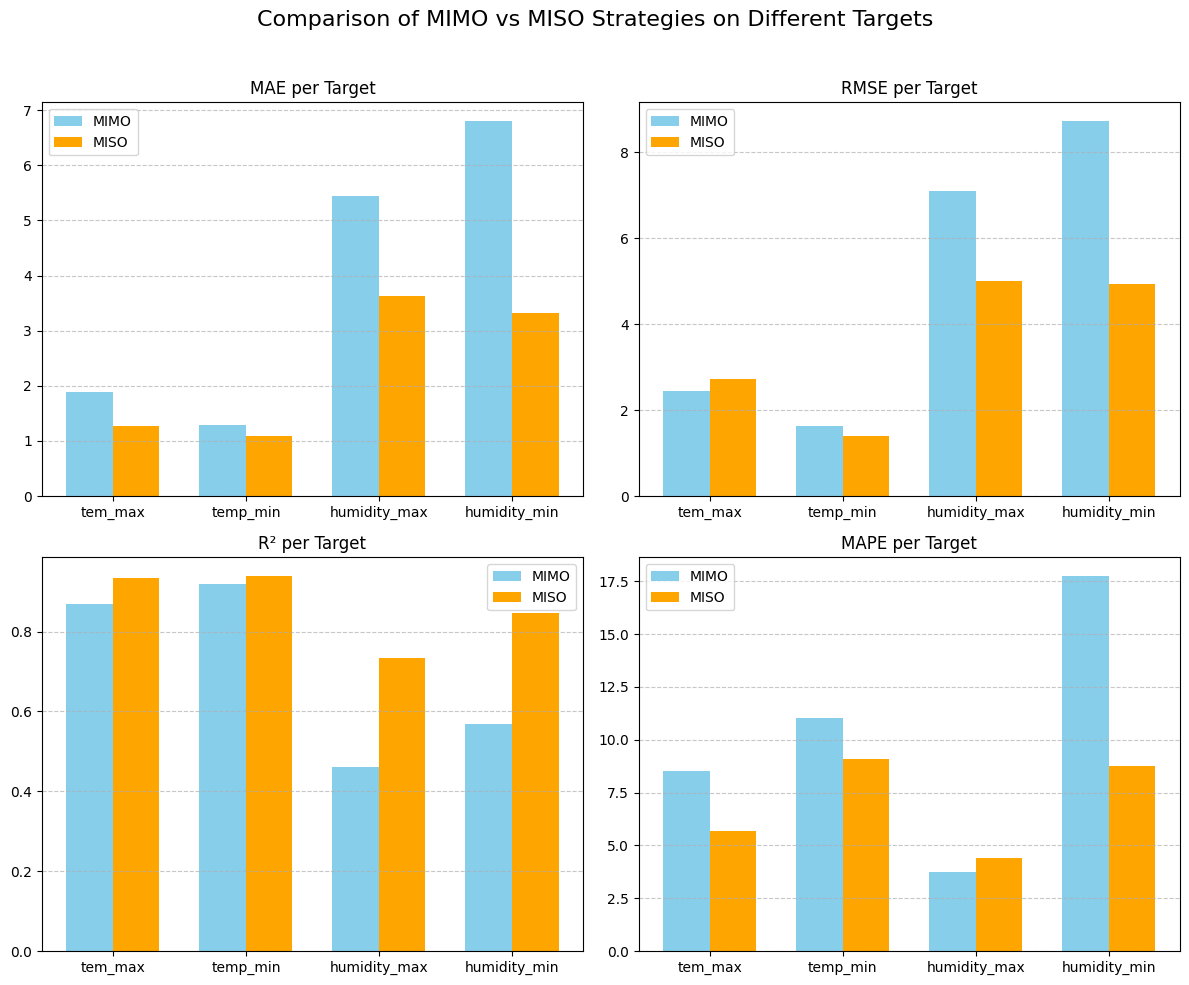

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data: replace with your actual values
targets = ['tem_max', 'temp_min', 'humidity_max', 'humidity_min']
metrics = ['MAE', 'RMSE', 'R²', 'MAPE']

# Example values (rows = metrics, columns = targets)
mimo_results = {
    'MAE': [1.893, 1.290, 5.440, 6.802],
    'RMSE': [2.455, 1.625, 7.105, 8.726],
    'R²': [0.868, 0.918, 0.461,0.568 ],
    'MAPE': [8.51, 11.03, 3.74, 17.74]
}

miso_results = {
    'MAE': [1.271, 1.094, 3.624, 3.314],
    'RMSE': [2.718, 1.397, 4.997, 4.926],
    'R²': [0.935, 0.939, 0.733, 0.846 ],
    'MAPE': [5.69, 9.10, 4.42, 8.74]
}

# Plot
x = np.arange(len(targets))  # label locations
width = 0.35  # width of bars

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for i, metric in enumerate(metrics):
    ax = axs[i]
    mimo_vals = mimo_results[metric]
    miso_vals = miso_results[metric]

    ax.bar(x - width/2, mimo_vals, width, label='MIMO', color='skyblue')
    ax.bar(x + width/2, miso_vals, width, label='MISO', color='orange')

    ax.set_title(f'{metric} per Target')
    ax.set_xticks(x)
    ax.set_xticklabels(targets)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

fig.suptitle('Comparison of MIMO vs MISO Strategies on Different Targets', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
